### Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow


In [1]:
# Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow

from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# -----------------------------
# Paths / core settings
# -----------------------------
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"

LOW_IGS_THRESHOLD = 45
ANALYSIS_YEARS = list(range(2017, 2025))   # ACS-aligned years only
PRE_COVID_YEARS = [2017, 2018, 2019]
COVID_YEARS = [2020, 2021]
RECOVERY_YEARS = [2022, 2023, 2024]

ECON_VARS = [
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

CLUSTER_CORE_VARS = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

DISPLAY_COLS = [
    "display_state",
    "display_county",
    "display_name",
]

REQUIRED_COLS = [
    "geoid",
    "year",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

PANEL_CANDIDATES = [
    OUT_DIR / "eda_panel_clean.parquet",
    OUT_DIR / "igs_x_acs_full.parquet",
]

def normalize_geoid_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_mask = numeric.notna()
    s = s.copy()
    s.loc[numeric_mask] = numeric.loc[numeric_mask].astype("Int64").astype("string")
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def add_display_fields(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "display_state" not in out.columns:
        if "State" in out.columns or "state" in out.columns:
            out["display_state"] = out.get("State", pd.Series(index=out.index)).fillna(
                out.get("state", pd.Series(index=out.index))
            )
        else:
            out["display_state"] = pd.NA

    if "display_county" not in out.columns:
        if "County" in out.columns or "county" in out.columns:
            out["display_county"] = out.get("County", pd.Series(index=out.index)).fillna(
                out.get("county", pd.Series(index=out.index))
            )
        else:
            out["display_county"] = pd.NA

    if "display_name" not in out.columns:
        if "NAME" in out.columns:
            out["display_name"] = out["NAME"].astype("string")
        elif "Census Tract FIPS code" in out.columns:
            out["display_name"] = "Census Tract " + out["Census Tract FIPS code"].astype("string")
        else:
            out["display_name"] = out["geoid"].astype("string")

    return out

def assign_period(year: int) -> str:
    if year in PRE_COVID_YEARS:
        return "pre_covid"
    if year in COVID_YEARS:
        return "covid"
    if year in RECOVERY_YEARS:
        return "recovery"
    return "outside_scope"

def load_analysis_panel() -> tuple[pd.DataFrame, str]:
    # Prefer in-memory validated objects if they already exist in the notebook.
    if "eda_df" in globals():
        df = eda_df.copy()
        source = "existing global: eda_df"
    elif "model_df_full" in globals():
        df = model_df_full.copy()
        source = "existing global: model_df_full"
    else:
        df = None
        source = None
        for p in PANEL_CANDIDATES:
            if p.exists():
                df = pd.read_parquet(p)
                source = f"file: {p}"
                break
        if df is None:
            searched = ", ".join(str(p) for p in PANEL_CANDIDATES)
            raise FileNotFoundError(
                "Could not find a processed merged panel. "
                f"Expected one of: {searched}"
            )

    # Standardize core keys
    df = df.copy()
    df["geoid"] = normalize_geoid_series(df["geoid"])
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Restrict to ACS-aligned period only
    df = df[df["year"].isin(ANALYSIS_YEARS)].copy()
    df["year"] = df["year"].astype(int)

    # Add consistent display fields
    df = add_display_fields(df)

    # Remove duplicate tract-year rows if any slipped in
    df = (
        df.sort_values(["geoid", "year"])
          .drop_duplicates(["geoid", "year"])
          .reset_index(drop=True)
    )

    # Validate required columns
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for new workflow: {missing}")

    # Add time-period labels for the new method
    df["analysis_period"] = df["year"].map(assign_period)

    return df, source

panel_df, PANEL_SOURCE = load_analysis_panel()

analysis_cols = (
    ["geoid", "year", "analysis_period"] +
    DISPLAY_COLS +
    CLUSTER_CORE_VARS
)

analysis_panel = panel_df[analysis_cols].copy()

print("Loaded panel from:", PANEL_SOURCE)
print("Analysis panel shape:", analysis_panel.shape)
print("Unique tracts:", analysis_panel["geoid"].nunique())
print("Years:", sorted(analysis_panel["year"].unique().tolist()))
print("Periods:", analysis_panel["analysis_period"].value_counts(dropna=False).to_dict())
print()
print("Missingness in core vars:")
print(analysis_panel[CLUSTER_CORE_VARS].isna().mean().sort_values(ascending=False))
print()
print(analysis_panel.head())

Loaded panel from: file: data\processed\eda_panel_clean.parquet
Analysis panel shape: (680256, 13)
Unique tracts: 85032
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Periods: {'pre_covid': 255096, 'recovery': 255096, 'covid': 170064}

Missingness in core vars:
median_household_income    0.116411
poverty_rate               0.111802
unemp_rate                 0.111357
lfpr_16p                   0.109857
pop_total                  0.104783
igs_total                  0.008863
igs_economy                0.001313
dtype: float64

         geoid  year analysis_period display_state  display_county                               display_name  igs_total  igs_economy  poverty_rate  unemp_rate  median_household_income  lfpr_16p  \
0  01001020100  2017       pre_covid       Alabama  Autauga County  Census Tract 201, Autauga County, Alabama       47.0         34.0      0.106775    0.045504                  67826.0  0.622387   
1  01001020100  2018       pre_covid       Alabama  Autauga Count

### Cell 2 — reuse or rebuild tract -> cluster mapping from the validated adjacency work

In [2]:
# Cell 2 — broadened rebuild of tract -> cluster mapping
# Goal:
# 1) keep the same vulnerability logic
# 2) broaden the actual candidate universe upstream
# 3) prevent the seed-county stage from collapsing into only one geography
# 4) keep adjacency clustering as the foundation

from pathlib import Path
from collections import defaultdict, deque
import zipfile
import requests
import geopandas as gpd
import numpy as np
import pandas as pd

# --------------------------------------------------
# Settings
# --------------------------------------------------
MIN_CLUSTER_TRACTS = 3
MIN_CLUSTER_POP = 5000

# Larger national pool used only to identify where strong signals exist
COUNTY_SIGNAL_POOL_N = 1500

# Diversified county selection
TARGET_SEED_COUNTIES_N = 40
PER_STATE_BASE_COUNTIES = 1
PER_STATE_MAX_COUNTIES = 3
MIN_SIGNAL_TRACTS_PER_COUNTY = 2

# County expansion after seed selection
BROADER_MAX_PER_COUNTY = 35

# Add one-hop tract connectors so communities do not fragment
CONNECTOR_HOPS = 1

TRACT_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/"
TRACT_ROOT_DIR = RAW_DIR / "tl_2024_state_tracts"
TRACT_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def load_state_tract_geometry(state_fips_list):
    tract_gdf_list = []

    for st in state_fips_list:
        zip_name = f"tl_2024_{st}_tract.zip"
        shp_name = f"tl_2024_{st}_tract.shp"
        zip_path = TRACT_ROOT_DIR / zip_name
        extract_dir = TRACT_ROOT_DIR / f"tl_2024_{st}_tract"
        shp_path = extract_dir / shp_name

        if not shp_path.exists():
            extract_dir.mkdir(parents=True, exist_ok=True)

            if not zip_path.exists():
                url = f"{TRACT_BASE_URL}{zip_name}"
                print(f"Downloading {url}")
                r = requests.get(url, timeout=120)
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    f.write(r.content)

            print(f"Extracting {zip_name}")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

        if not shp_path.exists():
            raise FileNotFoundError(f"Missing shapefile after extraction: {shp_path}")

        gdf_state = gpd.read_file(shp_path)
        tract_gdf_list.append(gdf_state)

    tract_gdf = pd.concat(tract_gdf_list, ignore_index=True)
    tract_gdf = gpd.GeoDataFrame(
        tract_gdf,
        geometry="geometry",
        crs=tract_gdf_list[0].crs if tract_gdf_list else None
    )

    tract_gdf["geoid"] = normalize_geoid_series(tract_gdf["GEOID"])
    tract_gdf = tract_gdf.dropna(subset=["geoid", "geometry"]).copy()
    tract_gdf = tract_gdf[tract_gdf.geometry.notna()].copy()
    tract_gdf = tract_gdf[~tract_gdf.geometry.is_empty].copy()
    tract_gdf = tract_gdf.drop_duplicates(subset=["geoid"]).copy()

    return tract_gdf

def build_adjacency_edges_fast(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Build tract-touching edges within each county.
    """
    edge_frames = []

    for (state_name, county_name), grp in gdf.groupby(
        ["display_state", "display_county"],
        dropna=False
    ):
        grp = grp[["geoid", "display_state", "display_county", "geometry"]].copy()
        grp = grp.dropna(subset=["geoid", "geometry"]).copy()

        if len(grp) < 2:
            continue

        left = grp[["geoid", "geometry"]].copy()
        right = grp[["geoid", "geometry"]].copy()

        joined = gpd.sjoin(left, right, how="inner", predicate="touches")
        if joined.empty:
            continue

        joined = joined.reset_index(drop=True)
        joined = joined.rename(columns={"geoid_left": "geoid_1", "geoid_right": "geoid_2"})
        joined = joined[joined["geoid_1"] != joined["geoid_2"]].copy()
        if joined.empty:
            continue

        joined["a"] = joined[["geoid_1", "geoid_2"]].min(axis=1)
        joined["b"] = joined[["geoid_1", "geoid_2"]].max(axis=1)
        joined = joined.drop_duplicates(subset=["a", "b"]).copy()

        out = joined[["a", "b"]].rename(columns={"a": "geoid_1", "b": "geoid_2"})
        out["display_state"] = state_name
        out["display_county"] = county_name
        edge_frames.append(out)

    if not edge_frames:
        return pd.DataFrame(columns=["display_state", "display_county", "geoid_1", "geoid_2"])

    return pd.concat(edge_frames, ignore_index=True)

def connected_components_from_edges(nodes, edges_df):
    neighbors = defaultdict(set)

    for n in nodes:
        neighbors[n] = set()

    if edges_df is not None and len(edges_df) > 0:
        for _, row in edges_df.iterrows():
            a = str(row["geoid_1"])
            b = str(row["geoid_2"])
            neighbors[a].add(b)
            neighbors[b].add(a)

    visited = set()
    node_to_cluster_num = {}
    cluster_num = 0

    for n in nodes:
        if n in visited:
            continue

        cluster_num += 1
        q = deque([n])
        visited.add(n)

        while q:
            cur = q.popleft()
            node_to_cluster_num[cur] = cluster_num

            for nxt in neighbors[cur]:
                if nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

    return node_to_cluster_num

def diversified_seed_counties(
    county_signal_df: pd.DataFrame,
    target_n: int,
    per_state_base: int,
    per_state_max: int,
) -> pd.DataFrame:
    """
    Step 1: take a base number of strong counties per state/territory.
    Step 2: backfill nationally until target_n, while respecting state caps.
    """
    county_signal_df = county_signal_df.copy()

    county_signal_df = county_signal_df.sort_values(
        ["display_state", "county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[True, False, False, False, True]
    ).reset_index(drop=True)

    county_signal_df["state_rank"] = (
        county_signal_df.groupby("display_state").cumcount() + 1
    )

    base = county_signal_df.loc[county_signal_df["state_rank"] <= per_state_base].copy()

    selected = base[
        ["display_state", "display_county"]
    ].drop_duplicates()

    selected_state_counts = (
        selected.groupby("display_state").size().to_dict()
        if len(selected) > 0 else {}
    )

    remaining = county_signal_df.merge(
        selected,
        on=["display_state", "display_county"],
        how="left",
        indicator=True
    )
    remaining = remaining.loc[remaining["_merge"] == "left_only"].drop(columns="_merge")
    remaining = remaining.sort_values(
        ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    chosen_rows = [selected.copy()] if len(selected) > 0 else []

    for _, row in remaining.iterrows():
        state_name = row["display_state"]

        current_ct = selected_state_counts.get(state_name, 0)
        if current_ct >= per_state_max:
            continue

        candidate = pd.DataFrame([{
            "display_state": row["display_state"],
            "display_county": row["display_county"]
        }])

        chosen_rows.append(candidate)
        selected_state_counts[state_name] = current_ct + 1

        total_selected = sum(selected_state_counts.values())
        if total_selected >= target_n:
            break

    if len(chosen_rows) == 0:
        return pd.DataFrame(columns=["display_state", "display_county"])

    out = (
        pd.concat(chosen_rows, ignore_index=True)
        .drop_duplicates(subset=["display_state", "display_county"])
        .reset_index(drop=True)
    )

    return out

# --------------------------------------------------
# A. Build recovery-period tract scoring base
# --------------------------------------------------
tract_recovery = (
    analysis_panel.loc[analysis_panel["analysis_period"] == "recovery"]
    .groupby(
        ["geoid", "display_state", "display_county", "display_name"],
        as_index=False
    )
    .agg({
        "igs_total": "mean",
        "igs_economy": "mean",
        "poverty_rate": "mean",
        "unemp_rate": "mean",
        "median_household_income": "mean",
        "lfpr_16p": "mean",
        "pop_total": "mean",
    })
    .copy()
)

tract_recovery["score_low_igs"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"])
) / 2

tract_recovery["score_econ_vulnerability"] = (
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 5

tract_recovery["scope_score"] = 100 * (
    0.50 * tract_recovery["score_low_igs"] +
    0.50 * tract_recovery["score_econ_vulnerability"]
)

tract_recovery = tract_recovery.sort_values(
    ["scope_score", "igs_total"],
    ascending=[False, True]
).reset_index(drop=True)

# --------------------------------------------------
# B. Use a much larger signal pool to identify strong counties
# --------------------------------------------------
signal_pool = tract_recovery.head(COUNTY_SIGNAL_POOL_N).copy()

county_signal = (
    signal_pool
    .groupby(["display_state", "display_county"], as_index=False)
    .agg(
        n_signal_tracts=("geoid", "nunique"),
        mean_scope_score=("scope_score", "mean"),
        median_scope_score=("scope_score", "median"),
        mean_igs_total=("igs_total", "mean"),
        min_igs_total=("igs_total", "min"),
        total_signal_pop=("pop_total", "sum"),
    )
    .copy()
)

county_signal = county_signal.loc[
    county_signal["n_signal_tracts"] >= MIN_SIGNAL_TRACTS_PER_COUNTY
].copy()

county_signal["county_seed_score"] = (
    0.40 * bad_when_high(county_signal["n_signal_tracts"]) +
    0.35 * bad_when_high(county_signal["mean_scope_score"]) +
    0.15 * bad_when_low(county_signal["mean_igs_total"]) +
    0.10 * bad_when_low(county_signal["min_igs_total"])
)

county_signal = county_signal.sort_values(
    ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

seed_counties = diversified_seed_counties(
    county_signal_df=county_signal,
    target_n=TARGET_SEED_COUNTIES_N,
    per_state_base=PER_STATE_BASE_COUNTIES,
    per_state_max=PER_STATE_MAX_COUNTIES,
)

seed_counties = (
    seed_counties
    .merge(
        county_signal[
            ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
        ],
        on=["display_state", "display_county"],
        how="left",
        validate="1:1"
    )
    .sort_values(["county_seed_score", "n_signal_tracts", "mean_scope_score"], ascending=[False, False, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# C. Expand within selected counties
# --------------------------------------------------
broader_county_pool = (
    tract_recovery
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

broader_county_pool["county_rank_by_score"] = (
    broader_county_pool
    .groupby(["display_state", "display_county"])["scope_score"]
    .rank(method="first", ascending=False)
)

core_scope_df = (
    broader_county_pool
    .loc[broader_county_pool["county_rank_by_score"] <= BROADER_MAX_PER_COUNTY]
    .drop(columns=["county_rank_by_score"])
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# D. Load geometry only for selected states
# --------------------------------------------------
needed_state_fips = sorted(
    core_scope_df["geoid"].astype(str).str[:2].dropna().unique().tolist()
)

tract_gdf = load_state_tract_geometry(needed_state_fips)

tract_geo_scored = tract_gdf.merge(
    tract_recovery,
    on="geoid",
    how="inner",
    validate="1:1"
)

seed_county_gdf = (
    tract_geo_scored
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

seed_county_gdf = seed_county_gdf[seed_county_gdf.geometry.notna()].copy()
seed_county_gdf = seed_county_gdf[~seed_county_gdf.geometry.is_empty].copy()

# --------------------------------------------------
# E. Add one-hop geographic connector tracts
# --------------------------------------------------
full_seed_edges = build_adjacency_edges_fast(seed_county_gdf)

core_nodes = set(core_scope_df["geoid"].astype(str).tolist())
expanded_nodes = set(core_nodes)

for _ in range(CONNECTOR_HOPS):
    if full_seed_edges.empty:
        break

    touching_core = full_seed_edges[
        full_seed_edges["geoid_1"].astype(str).isin(expanded_nodes) |
        full_seed_edges["geoid_2"].astype(str).isin(expanded_nodes)
    ].copy()

    neighbor_nodes = set(touching_core["geoid_1"].astype(str).tolist()) | set(
        touching_core["geoid_2"].astype(str).tolist()
    )

    expanded_nodes = expanded_nodes | neighbor_nodes

CLUSTER_SCOPE_DF = (
    seed_county_gdf.loc[seed_county_gdf["geoid"].astype(str).isin(expanded_nodes)]
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

adjacency_gdf = CLUSTER_SCOPE_DF.copy()

adjacency_edges = full_seed_edges.loc[
    full_seed_edges["geoid_1"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str))) &
    full_seed_edges["geoid_2"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str)))
].copy()

# --------------------------------------------------
# F. Connected components on broadened scope
# --------------------------------------------------
all_candidate_nodes = adjacency_gdf["geoid"].astype(str).unique().tolist()
node_to_cluster_num = connected_components_from_edges(all_candidate_nodes, adjacency_edges)

adjacency_gdf["cluster_id_num"] = adjacency_gdf["geoid"].astype(str).map(node_to_cluster_num)
adjacency_gdf["cluster_id"] = (
    adjacency_gdf["display_state"].astype(str)
    + " | "
    + adjacency_gdf["display_county"].astype(str)
    + " | cluster_"
    + adjacency_gdf["cluster_id_num"].astype(str)
)

tract_cluster_map = (
    adjacency_gdf[
        ["geoid", "cluster_id", "display_state", "display_county", "display_name"]
    ]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

tract_cluster_map["n_cluster_tracts"] = (
    tract_cluster_map.groupby("cluster_id")["geoid"].transform("nunique")
)

# --------------------------------------------------
# G. Save outputs
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

tract_cluster_map.to_parquet(OUT_DIR / "tract_cluster_map.parquet", index=False)
CLUSTER_SCOPE_DF.drop(columns="geometry").to_parquet(OUT_DIR / "cluster_scope_df.parquet", index=False)
adjacency_gdf.drop(columns="geometry").to_parquet(OUT_DIR / "adjacency_cluster_scope.parquet", index=False)
seed_counties.to_parquet(OUT_DIR / "seed_counties.parquet", index=False)
county_signal.to_parquet(OUT_DIR / "county_signal.parquet", index=False)

# --------------------------------------------------
# H. Diagnostics
# --------------------------------------------------
print("Recovery tract universe:", tract_recovery.shape)
print("Signal pool shape:", signal_pool.shape)
print("County signal shape:", county_signal.shape)
print("Seed counties selected:", seed_counties.shape[0])
print("Needed state FIPS:", needed_state_fips)
print()

print("Seed counties by state:")
print(seed_counties["display_state"].value_counts(dropna=False).sort_values(ascending=False))
print()

print("County-expanded core scope:", core_scope_df.shape)
print("Seed-county tract universe:", seed_county_gdf.shape)
print("Connector hops:", CONNECTOR_HOPS)
print("Final CLUSTER_SCOPE_DF shape:", CLUSTER_SCOPE_DF.shape)
print("Connector tracts added:", len(set(CLUSTER_SCOPE_DF["geoid"]) - set(core_scope_df["geoid"])))
print()

print("Adjacency merge shape:", adjacency_gdf.shape)
print("Adjacency edges shape:", adjacency_edges.shape)
print()

print("tract_cluster_map shape:", tract_cluster_map.shape)
print("Unique tracts mapped:", tract_cluster_map["geoid"].nunique())
print("Unique clusters:", tract_cluster_map["cluster_id"].nunique())
print("Unique states in cluster universe:", tract_cluster_map["display_state"].nunique())
print("Unique counties in cluster universe:", tract_cluster_map["display_county"].nunique())
print()

print("Top 25 seed counties:")
print(
    seed_counties[
        ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
    ].head(25)
)

print()
print("Top 25 clusters by size:")
print(
    tract_cluster_map.groupby(["cluster_id", "display_state", "display_county"], as_index=False)
    .agg(n_cluster_tracts=("geoid", "nunique"))
    .sort_values(["n_cluster_tracts", "cluster_id"], ascending=[False, True])
    .head(25)
)

Recovery tract universe: (84153, 14)
Signal pool shape: (1500, 14)
County signal shape: (190, 9)
Seed counties selected: 40
Needed state FIPS: ['01', '04', '05', '06', '11', '12', '13', '17', '18', '20', '21', '22', '24', '25', '26', '28', '29', '32', '34', '35', '36', '37', '39', '40', '42', '45', '47', '48', '51', '54', '55', '72']

Seed counties by state:
display_state
Puerto Rico             3
Arizona                 3
New Mexico              2
Ohio                    2
Michigan                2
New York                2
Georgia                 1
Indiana                 1
Pennsylvania            1
Illinois                1
Tennessee               1
Wisconsin               1
California              1
Maryland                1
Louisiana               1
Alabama                 1
Missouri                1
Kentucky                1
West Virginia           1
Mississippi             1
New Jersey              1
District of Columbia    1
South Carolina          1
Florida                 1
N

### Cell 3 — join tract panel to clusters and build a cluster-year panel

In [3]:
# Cell 3 — join tract panel to clusters and build a cluster-year panel

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return values.loc[valid].mean()

    return np.average(values.loc[mask], weights=weights.loc[mask])

clustered_panel = (
    analysis_panel
    .merge(
        tract_cluster_map[
            ["geoid", "cluster_id", "display_state", "display_county", "n_cluster_tracts"]
        ],
        on="geoid",
        how="inner",
        validate="many_to_one",
        suffixes=("", "_cluster")
    )
    .copy()
)

# Prefer cluster metadata from the tract_cluster_map
clustered_panel["cluster_display_state"] = clustered_panel["display_state_cluster"]
clustered_panel["cluster_display_county"] = clustered_panel["display_county_cluster"]

# Keep only true cluster aggregation vars here
cluster_core_vars = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

cluster_year_rows = []

for (cluster_id, year, period), grp in clustered_panel.groupby(
    ["cluster_id", "year", "analysis_period"],
    dropna=False
):
    igs_vals = pd.to_numeric(grp["igs_total"], errors="coerce")
    valid_igs = igs_vals.notna()

    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "analysis_period": period,
        "display_state": grp["cluster_display_state"].dropna().iloc[0] if grp["cluster_display_state"].notna().any() else pd.NA,
        "display_county": grp["cluster_display_county"].dropna().iloc[0] if grp["cluster_display_county"].notna().any() else pd.NA,
        "n_cluster_tracts": grp["n_cluster_tracts"].dropna().iloc[0] if grp["n_cluster_tracts"].notna().any() else grp["geoid"].nunique(),
        "n_observed_tracts_year": grp["geoid"].nunique(),
        "cluster_pop_total": pd.to_numeric(grp["pop_total"], errors="coerce").sum(min_count=1),
        "low_igs_tract_share": (
            igs_vals.loc[valid_igs].lt(LOW_IGS_THRESHOLD).mean()
            if valid_igs.any() else np.nan
        ),
    }

    weights = pd.to_numeric(grp["pop_total"], errors="coerce")

    for col in cluster_core_vars:
        row[col] = safe_weighted_mean(grp[col], weights)

    cluster_year_rows.append(row)

cluster_year_panel = (
    pd.DataFrame(cluster_year_rows)
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

print("clustered_panel shape:", clustered_panel.shape)
print("cluster_year_panel shape:", cluster_year_panel.shape)
print("Unique clusters in panel:", cluster_year_panel["cluster_id"].nunique())
print("Years in cluster panel:", sorted(cluster_year_panel["year"].unique().tolist()))
print()
print(cluster_year_panel.head(15))

clustered_panel shape: (23536, 19)
cluster_year_panel shape: (688, 15)
Unique clusters in panel: 86
Years in cluster panel: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

                             cluster_id  year analysis_period display_state display_county  n_cluster_tracts  n_observed_tracts_year  cluster_pop_total  low_igs_tract_share  igs_total  igs_economy  \
0   Alabama | Mobile County | cluster_1  2017       pre_covid       Alabama  Mobile County                81                      81           174074.0             0.777778  38.670840    40.815976   
1   Alabama | Mobile County | cluster_1  2018       pre_covid       Alabama  Mobile County                81                      81           171909.0             0.753086  37.426682    39.276507   
2   Alabama | Mobile County | cluster_1  2019       pre_covid       Alabama  Mobile County                81                      81           171726.0             0.814815  38.016493    40.396335   
3   Alabama | Mobile Count

### Cell 4 — build period-level summaries and transparent trajectory features

In [4]:
# Cell 4 — build period-level summaries and transparent trajectory features

PERIOD_ORDER = ["pre_covid", "covid", "recovery"]

# -----------------------------
# Period-level aggregation
# -----------------------------
period_metric_cols = [
    "cluster_pop_total",
    "low_igs_tract_share",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

agg_dict = {
    "display_state": "first",
    "display_county": "first",
    "n_cluster_tracts": "max",
    "cluster_pop_total": "mean",
    "low_igs_tract_share": "mean",
    "igs_total": "mean",
    "igs_economy": "mean",
    "poverty_rate": "mean",
    "unemp_rate": "mean",
    "median_household_income": "mean",
    "lfpr_16p": "mean",
}

# optional diagnostic if Cell 3 includes this column
if "n_observed_tracts_year" in cluster_year_panel.columns:
    agg_dict["n_observed_tracts_year"] = "min"

cluster_period_panel = (
    cluster_year_panel
    .groupby(["cluster_id", "analysis_period"], as_index=False)
    .agg(agg_dict)
    .copy()
)

cluster_period_panel["analysis_period"] = pd.Categorical(
    cluster_period_panel["analysis_period"],
    categories=PERIOD_ORDER,
    ordered=True
)

cluster_period_panel = cluster_period_panel.sort_values(
    ["cluster_id", "analysis_period"]
).reset_index(drop=True)

# -----------------------------
# Stable cluster metadata
# -----------------------------
latest_cluster_meta = (
    cluster_year_panel
    .sort_values(["cluster_id", "year"])
    .groupby("cluster_id", as_index=False)
    .tail(1)[["cluster_id", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]]
    .rename(columns={"cluster_pop_total": "latest_cluster_pop_total"})
    .copy()
)

# -----------------------------
# Wide period summary
# Only pivot true period-varying metrics
# -----------------------------
cluster_period_wide = (
    cluster_period_panel
    .pivot(index="cluster_id", columns="analysis_period", values=period_metric_cols)
)

expected_cols = pd.MultiIndex.from_product(
    [period_metric_cols, PERIOD_ORDER],
    names=["metric", "analysis_period"]
)
cluster_period_wide = cluster_period_wide.reindex(columns=expected_cols)

cluster_period_wide.columns = [
    f"{metric}_{period}" for metric, period in cluster_period_wide.columns
]
cluster_period_wide = cluster_period_wide.reset_index()

cluster_period_summary = (
    latest_cluster_meta
    .merge(cluster_period_wide, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# Period completeness diagnostics
# -----------------------------
cluster_period_summary["has_pre_covid"] = cluster_period_summary["igs_total_pre_covid"].notna()
cluster_period_summary["has_covid"] = cluster_period_summary["igs_total_covid"].notna()
cluster_period_summary["has_recovery"] = cluster_period_summary["igs_total_recovery"].notna()

cluster_period_summary["complete_periods_flag"] = (
    cluster_period_summary["has_pre_covid"] &
    cluster_period_summary["has_covid"] &
    cluster_period_summary["has_recovery"]
)

# -----------------------------
# Trajectory deltas
# Positive shock metrics = worse COVID hit
# Positive rebound metrics = stronger recovery
# -----------------------------

# Lower is worse: igs_total, igs_economy
cluster_period_summary["igs_total_drop_pre_to_covid"] = (
    cluster_period_summary["igs_total_pre_covid"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_drop_pre_to_covid"] = (
    cluster_period_summary["igs_economy_pre_covid"] - cluster_period_summary["igs_economy_covid"]
)
cluster_period_summary["igs_total_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_total_recovery"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_economy_recovery"] - cluster_period_summary["igs_economy_covid"]
)

# Higher is worse: poverty_rate, unemp_rate
cluster_period_summary["poverty_increase_pre_to_covid"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_pre_covid"]
)
cluster_period_summary["unemp_increase_pre_to_covid"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_pre_covid"]
)
cluster_period_summary["poverty_improve_covid_to_recovery"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_recovery"]
)
cluster_period_summary["unemp_improve_covid_to_recovery"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_recovery"]
)

# Higher is better: income, labor-force participation
cluster_period_summary["income_drop_pre_to_covid"] = (
    cluster_period_summary["median_household_income_pre_covid"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_drop_pre_to_covid"] = (
    cluster_period_summary["lfpr_16p_pre_covid"] - cluster_period_summary["lfpr_16p_covid"]
)
cluster_period_summary["income_rebound_covid_to_recovery"] = (
    cluster_period_summary["median_household_income_recovery"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_rebound_covid_to_recovery"] = (
    cluster_period_summary["lfpr_16p_recovery"] - cluster_period_summary["lfpr_16p_covid"]
)

# -----------------------------
# Structural filters
# -----------------------------
cluster_period_summary["serious_cluster_flag"] = (
    cluster_period_summary["complete_periods_flag"] &
    (cluster_period_summary["n_cluster_tracts"] >= MIN_CLUSTER_TRACTS) &
    (cluster_period_summary["latest_cluster_pop_total"] >= MIN_CLUSTER_POP)
)

cluster_period_summary["low_igs_recovery_flag"] = (
    cluster_period_summary["igs_total_recovery"] < LOW_IGS_THRESHOLD
)

cluster_period_summary["low_igs_economy_recovery_flag"] = (
    cluster_period_summary["igs_economy_recovery"] < LOW_IGS_THRESHOLD
)

# -----------------------------
# Diagnostics
# -----------------------------
print("cluster_period_panel shape:", cluster_period_panel.shape)
print("cluster_period_summary shape:", cluster_period_summary.shape)
print()
print("Complete-period cluster count:", int(cluster_period_summary["complete_periods_flag"].sum()))
print("Serious cluster count:", int(cluster_period_summary["serious_cluster_flag"].sum()))
print("Recovery low-IGS cluster count:", int(cluster_period_summary["low_igs_recovery_flag"].sum()))
print()
print(
    cluster_period_summary[
        [
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "poverty_rate_pre_covid",
            "poverty_rate_covid",
            "poverty_rate_recovery",
            "complete_periods_flag",
            "serious_cluster_flag",
            "low_igs_recovery_flag",
        ]
    ].head(15)
)

cluster_period_panel shape: (258, 14)
cluster_period_summary shape: (86, 48)

Complete-period cluster count: 86
Serious cluster count: 86
Recovery low-IGS cluster count: 67

                                      cluster_id display_state      display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0            Alabama | Mobile County | cluster_1       Alabama       Mobile County                81                  210593.0            38.038005        40.705012           39.938532   
1            Alabama | Mobile County | cluster_2       Alabama       Mobile County                 6                   21037.0            45.178083        47.033454           44.644035   
2            Arizona | Apache County | cluster_3       Arizona       Apache County                18                   65341.0            31.620153        34.649302           34.156029   
3          Arizona | Coconino County | cluster_4       Arizona     Coconin

### Cell 5 — practical shortlist logic for the new method

In [5]:
# Cell 5 — practical shortlist logic for the new method

def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

cluster_scored = cluster_period_summary.copy()

# -----------------------------------
# Scoring universe
# Score only clusters that are structurally usable
# Then apply final low-IGS shortlist filter afterward
# -----------------------------------
cluster_scored["eligible_for_scoring"] = (
    cluster_scored["complete_periods_flag"].fillna(False) &
    cluster_scored["serious_cluster_flag"].fillna(False)
)

score_mask = cluster_scored["eligible_for_scoring"]
score_df = cluster_scored.loc[score_mask].copy()

# -----------------------------------
# Shock variables:
# Positive values = adverse COVID shock
# Negative values are clipped to 0 so they do not behave like "anti-shock"
# -----------------------------------
shock_cols = [
    "igs_total_drop_pre_to_covid",
    "igs_economy_drop_pre_to_covid",
    "poverty_increase_pre_to_covid",
    "unemp_increase_pre_to_covid",
    "income_drop_pre_to_covid",
    "lfpr_drop_pre_to_covid",
]

for col in shock_cols:
    score_df[f"{col}_shock_only"] = pd.to_numeric(score_df[col], errors="coerce").clip(lower=0)

# -----------------------------------
# Weak-recovery shortfall variables:
# Higher = weaker recovery
# -----------------------------------
score_df["weakrec_igs_total"] = -pd.to_numeric(score_df["igs_total_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_igs_economy"] = -pd.to_numeric(score_df["igs_economy_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_poverty"] = -pd.to_numeric(score_df["poverty_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_unemp"] = -pd.to_numeric(score_df["unemp_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_income"] = -pd.to_numeric(score_df["income_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_lfpr"] = -pd.to_numeric(score_df["lfpr_rebound_covid_to_recovery"], errors="coerce")

# -----------------------------------
# 1) Still low on IGS in recovery
# Use overall IGS + share of tracts below the IGS threshold
# This avoids double-counting igs_economy here
# -----------------------------------
score_df["score_low_igs_recovery"] = (
    bad_when_low(score_df["igs_total_recovery"]) +
    bad_when_high(score_df["low_igs_tract_share_recovery"])
) / 2

# -----------------------------------
# 2) Economically vulnerable in recovery
# Keep igs_economy only here, as the economy anchor + ACS support
# -----------------------------------
score_df["score_econ_vulnerability_recovery"] = (
    bad_when_low(score_df["igs_economy_recovery"]) +
    bad_when_high(score_df["poverty_rate_recovery"]) +
    bad_when_high(score_df["unemp_rate_recovery"]) +
    bad_when_low(score_df["median_household_income_recovery"]) +
    bad_when_low(score_df["lfpr_16p_recovery"])
) / 5

# -----------------------------------
# 3) Harder COVID shock relative to pre-COVID baseline
# -----------------------------------
score_df["score_covid_shock"] = (
    bad_when_high(score_df["igs_total_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["igs_economy_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["poverty_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["unemp_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["income_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["lfpr_drop_pre_to_covid_shock_only"])
) / 6

# -----------------------------------
# 4) Weak recovery since COVID
# -----------------------------------
score_df["score_weak_recovery"] = (
    bad_when_high(score_df["weakrec_igs_total"]) +
    bad_when_high(score_df["weakrec_igs_economy"]) +
    bad_when_high(score_df["weakrec_poverty"]) +
    bad_when_high(score_df["weakrec_unemp"]) +
    bad_when_high(score_df["weakrec_income"]) +
    bad_when_high(score_df["weakrec_lfpr"])
) / 6

# -----------------------------------
# Transparent final score
# Recovery status + recovery vulnerability remain the foundation
# -----------------------------------
score_df["cluster_shortlist_score"] = (
    0.35 * score_df["score_low_igs_recovery"] +
    0.35 * score_df["score_econ_vulnerability_recovery"] +
    0.15 * score_df["score_covid_shock"] +
    0.15 * score_df["score_weak_recovery"]
)

# Write scores back into the full cluster frame
score_cols = [
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]
cluster_scored = cluster_scored.merge(
    score_df[["cluster_id"] + score_cols],
    on="cluster_id",
    how="left",
    validate="1:1",
)

# -----------------------------------
# Final practical screen for enrichment candidates
# -----------------------------------
cluster_shortlist = (
    cluster_scored
    .loc[
        cluster_scored["eligible_for_scoring"] &
        cluster_scored["low_igs_recovery_flag"]
    ]
    .sort_values(
        [
            "cluster_shortlist_score",
            "igs_total_recovery",
            "igs_economy_recovery",
            "latest_cluster_pop_total",
        ],
        ascending=[False, True, True, False]
    )
    .reset_index(drop=True)
)

cluster_shortlist["rank"] = np.arange(1, len(cluster_shortlist) + 1)

shortlist_view_cols = [
    "rank",
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "igs_total_pre_covid",
    "igs_total_covid",
    "igs_total_recovery",
    "low_igs_tract_share_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]

print("Scoring universe shape:", score_df.shape)
print("Final shortlist shape:", cluster_shortlist.shape)
print()
print(cluster_shortlist[shortlist_view_cols].head(20))

# Optional: persist key outputs for later healthcare + business enrichment
OUT_DIR.mkdir(parents=True, exist_ok=True)
cluster_year_panel.to_parquet(OUT_DIR / "cluster_year_panel.parquet", index=False)
cluster_period_summary.to_parquet(OUT_DIR / "cluster_period_summary.parquet", index=False)
cluster_shortlist.to_parquet(OUT_DIR / "cluster_shortlist.parquet", index=False)

print()
print("Saved:")
print("-", OUT_DIR / "cluster_year_panel.parquet")
print("-", OUT_DIR / "cluster_period_summary.parquet")
print("-", OUT_DIR / "cluster_shortlist.parquet")

Scoring universe shape: (86, 66)
Final shortlist shape: (67, 55)

    rank                                       cluster_id   display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0      1      Puerto Rico | Utuado Municipio | cluster_75     Puerto Rico      Utuado Municipio                 8                   27621.0            27.537654        28.321111           25.035923   
1      2    Puerto Rico | Mayagüez Municipio | cluster_73     Puerto Rico    Mayagüez Municipio                25                   70828.0            32.572527        33.746456           31.136263   
2      3  Puerto Rico | Río Grande Municipio | cluster_74     Puerto Rico  Río Grande Municipio                12                   46051.0            27.542052        25.692985           25.284481   
3      4              Ohio | Cuyahoga County | cluster_64            Ohio       Cuyahoga County                13                 

### Cell 6 — prepare enrichment-ready outputs for healthcare + business data


In [6]:
# Cell 6 — prepare enrichment-ready outputs from the main shortlist
# IMPORTANT:
# This cell stays source-agnostic.
# It packages the shortlist for later healthcare + business enrichment only.

ENRICHMENT_TOP_K = min(15, len(cluster_shortlist))

# -----------------------------
# A. pick the top clusters to enrich next
# -----------------------------
enrichment_clusters = (
    cluster_shortlist
    .head(ENRICHMENT_TOP_K)
    .copy()
    .reset_index(drop=True)
)

enrichment_clusters["enrichment_rank"] = np.arange(1, len(enrichment_clusters) + 1)
enrichment_cluster_ids = enrichment_clusters["cluster_id"].astype(str).tolist()

print(f"Selected top {len(enrichment_clusters)} clusters for next-step enrichment.")
print(
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "cluster_shortlist_score",
        ]
    ].head(15)
)

# useful lookup for downstream merges
enrichment_rank_lookup = enrichment_clusters[
    ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
].drop_duplicates().copy()

# -----------------------------
# B. tract-level lookup table for external joins
# -----------------------------
enrichment_cluster_tracts = (
    tract_cluster_map
    .loc[tract_cluster_map["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_cluster_tracts["geoid"] = normalize_geoid_series(enrichment_cluster_tracts["geoid"])
enrichment_cluster_tracts = enrichment_cluster_tracts.dropna(subset=["geoid"]).copy()

enrichment_cluster_tracts["state_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:2]
enrichment_cluster_tracts["county_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:5]
enrichment_cluster_tracts["tract_code"] = enrichment_cluster_tracts["geoid"].astype(str).str[5:]

enrichment_cluster_tracts = (
    enrichment_cluster_tracts
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid"])
    .drop_duplicates(subset=["cluster_id", "geoid"])
    .reset_index(drop=True)
)

# -----------------------------
# C. county-level lookup table for external county joins
# -----------------------------
enrichment_cluster_counties = (
    enrichment_cluster_tracts
    .groupby(
        ["cluster_id", "enrichment_rank", "display_state", "display_county", "county_fips"],
        as_index=False
    )
    .agg(
        n_cluster_tracts_in_county=("geoid", "nunique"),
        tract_list=("geoid", lambda s: sorted(set(s.astype(str))))
    )
    .sort_values(["enrichment_rank", "cluster_id", "county_fips"])
    .reset_index(drop=True)
)

cluster_county_counts = (
    enrichment_cluster_counties
    .groupby("cluster_id", as_index=False)
    .agg(n_cluster_counties=("county_fips", "nunique"))
)

# -----------------------------
# D. keep the full year-by-year history for shortlisted clusters
# -----------------------------
enrichment_cluster_year_panel = (
    cluster_year_panel
    .loc[cluster_year_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# E. tract-year panel for later tract/county joins
# -----------------------------
enrichment_tract_year_panel = (
    clustered_panel
    .loc[clustered_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_tract_year_panel["geoid"] = normalize_geoid_series(enrichment_tract_year_panel["geoid"])
enrichment_tract_year_panel = enrichment_tract_year_panel.dropna(subset=["geoid"]).copy()

enrichment_tract_year_panel["state_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:2]
enrichment_tract_year_panel["county_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:5]
enrichment_tract_year_panel["tract_code"] = enrichment_tract_year_panel["geoid"].astype(str).str[5:]

enrichment_tract_year_panel = (
    enrichment_tract_year_panel
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid", "year"])
    .drop_duplicates(subset=["cluster_id", "geoid", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# F. profile table
# -----------------------------
enrichment_cluster_profiles = (
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "low_igs_tract_share_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "score_low_igs_recovery",
            "score_econ_vulnerability_recovery",
            "score_covid_shock",
            "score_weak_recovery",
            "cluster_shortlist_score",
        ]
    ]
    .merge(cluster_county_counts, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# G. validation checks
# -----------------------------
expected_cluster_ids = set(enrichment_cluster_ids)
tract_cluster_ids = set(enrichment_cluster_tracts["cluster_id"].astype(str).unique())
county_cluster_ids = set(enrichment_cluster_counties["cluster_id"].astype(str).unique())
year_cluster_ids = set(enrichment_cluster_year_panel["cluster_id"].astype(str).unique())
tract_year_cluster_ids = set(enrichment_tract_year_panel["cluster_id"].astype(str).unique())
profile_cluster_ids = set(enrichment_cluster_profiles["cluster_id"].astype(str).unique())

assert tract_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_tracts"
assert county_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_counties"
assert year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_year_panel"
assert tract_year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_tract_year_panel"
assert profile_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_profiles"

expected_cluster_year_rows = len(expected_cluster_ids) * len(sorted(cluster_year_panel["year"].dropna().unique()))
if len(enrichment_cluster_year_panel) != expected_cluster_year_rows:
    print(
        f"Warning: enrichment_cluster_year_panel has {len(enrichment_cluster_year_panel)} rows; "
        f"expected about {expected_cluster_year_rows} if all selected clusters have all years."
    )

# optional tract-year completeness check
tract_counts = enrichment_cluster_tracts.groupby("cluster_id")["geoid"].nunique()
tract_year_counts = enrichment_tract_year_panel.groupby("cluster_id").size()
expected_years = len(sorted(enrichment_tract_year_panel["year"].dropna().unique()))
tract_year_check = pd.DataFrame({
    "n_cluster_tracts_lookup": tract_counts,
    "tract_year_rows": tract_year_counts
}).reset_index()
tract_year_check["expected_rows_if_full"] = tract_year_check["n_cluster_tracts_lookup"] * expected_years
tract_year_check["full_8yr_panel_flag"] = (
    tract_year_check["tract_year_rows"] == tract_year_check["expected_rows_if_full"]
)

# -----------------------------
# H. save outputs
# -----------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

enrichment_clusters.to_parquet(OUT_DIR / "enrichment_clusters.parquet", index=False)
enrichment_cluster_profiles.to_parquet(OUT_DIR / "enrichment_cluster_profiles.parquet", index=False)
enrichment_cluster_tracts.to_parquet(OUT_DIR / "enrichment_cluster_tracts.parquet", index=False)
enrichment_cluster_counties.to_parquet(OUT_DIR / "enrichment_cluster_counties.parquet", index=False)
enrichment_cluster_year_panel.to_parquet(OUT_DIR / "enrichment_cluster_year_panel.parquet", index=False)
enrichment_tract_year_panel.to_parquet(OUT_DIR / "enrichment_tract_year_panel.parquet", index=False)
tract_year_check.to_parquet(OUT_DIR / "enrichment_tract_year_completeness.parquet", index=False)

enrichment_cluster_profiles.to_csv(OUT_DIR / "enrichment_cluster_profiles.csv", index=False)
enrichment_cluster_tracts.to_csv(OUT_DIR / "enrichment_cluster_tracts.csv", index=False)
enrichment_cluster_counties.to_csv(OUT_DIR / "enrichment_cluster_counties.csv", index=False)
tract_year_check.to_csv(OUT_DIR / "enrichment_tract_year_completeness.csv", index=False)

print("\nSaved enrichment package.")
print("enrichment_clusters shape:", enrichment_clusters.shape)
print("enrichment_cluster_profiles shape:", enrichment_cluster_profiles.shape)
print("enrichment_cluster_tracts shape:", enrichment_cluster_tracts.shape)
print("enrichment_cluster_counties shape:", enrichment_cluster_counties.shape)
print("enrichment_cluster_year_panel shape:", enrichment_cluster_year_panel.shape)
print("enrichment_tract_year_panel shape:", enrichment_tract_year_panel.shape)
print("tract_year_check shape:", tract_year_check.shape)
print()
print("Tract-year completeness check:")
print(
    tract_year_check.sort_values(["full_8yr_panel_flag", "cluster_id"], ascending=[True, True]).head(20)
)

Selected top 15 clusters for next-step enrichment.
    enrichment_rank  rank                                       cluster_id display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_recovery  igs_economy_recovery  \
0                 1     1      Puerto Rico | Utuado Municipio | cluster_75   Puerto Rico      Utuado Municipio                 8                   27621.0           25.035923             15.289723   
1                 2     2    Puerto Rico | Mayagüez Municipio | cluster_73   Puerto Rico    Mayagüez Municipio                25                   70828.0           31.136263             19.475426   
2                 3     3  Puerto Rico | Río Grande Municipio | cluster_74   Puerto Rico  Río Grande Municipio                12                   46051.0           25.284481             17.443243   
3                 4     4              Ohio | Cuyahoga County | cluster_64          Ohio       Cuyahoga County                13                   31

### Cell 7A — fetch CDC PLACES tract-level data for Shelby County

In [7]:
# ============================================================
# Cell 7A — fetch CDC PLACES tract-level data for Shelby County
# NOTE:
# - We use PLACES as a tract-level local snapshot, not a time-trend source.
# - We keep all returned years because some concepts may be carried from
#   an earlier release year.
# ============================================================

import requests
import pandas as pd
import numpy as np
import re

PLACES_TRACT_RESOURCE = "cwsq-ngmh"   # CDC PLACES census tract dataset
PLACES_TRACT_URL = f"https://data.cdc.gov/resource/{PLACES_TRACT_RESOURCE}.json"

TARGET_STATE_ABBR = "TN"
TARGET_COUNTY_FIPS = "47157"   # Shelby County, TN
PLACES_LIMIT = 50000

# Fallback helper in case your notebook session lost it
if "normalize_geoid_series" not in globals():
    def normalize_geoid_series(s):
        s = pd.Series(s, copy=False)
        out = (
            s.astype("string")
             .str.extract(r"(\d{11})", expand=False)
        )
        return out

def fetch_places_tract_rows(state_abbr: str, county_fips: str, limit: int = 50000) -> pd.DataFrame:
    session = requests.Session()
    rows = []
    offset = 0

    while True:
        params = {
            "$where": f"stateabbr='{state_abbr}' AND countyfips='{county_fips}'",
            "$limit": limit,
            "$offset": offset,
        }
        r = session.get(PLACES_TRACT_URL, params=params, timeout=120)
        r.raise_for_status()
        chunk = r.json()

        if not chunk:
            break

        rows.extend(chunk)

        if len(chunk) < limit:
            break

        offset += limit

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(
            f"No CDC PLACES tract rows returned for stateabbr={state_abbr}, countyfips={county_fips}."
        )

    df.columns = [str(c).strip().lower() for c in df.columns]

    # Ensure expected columns exist
    expected_cols = [
        "year", "stateabbr", "statedesc", "countyname", "countyfips",
        "locationname", "measure", "measureid", "short_question_text",
        "category", "data_value_type", "datavaluetypeid", "data_value",
        "data_value_unit", "low_confidence_limit", "high_confidence_limit",
        "totalpopulation"
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    # Robust tract GEOID extraction
    geo_candidates = []
    for c in ["tractfips", "locationname", "geoid", "tract", "tract_fips"]:
        if c in df.columns:
            norm = normalize_geoid_series(df[c])
            geo_candidates.append((c, int(norm.notna().sum()), norm))

    if not geo_candidates:
        raise ValueError(f"No usable tract geography column found. Columns: {list(df.columns)}")

    geo_candidates = sorted(geo_candidates, key=lambda x: x[1], reverse=True)
    best_geo_col, best_nonnull, best_norm = geo_candidates[0]
    df["tractfips"] = best_norm

    for c in ["data_value", "low_confidence_limit", "high_confidence_limit", "totalpopulation"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    print("Best geography column used:", best_geo_col)
    print("Valid normalized tract GEOIDs:", best_nonnull)
    print("Rows pulled:", df.shape)
    print("Unique tract GEOIDs:", df["tractfips"].nunique())
    print("Years present:", sorted(df["year"].dropna().unique().tolist()))
    print("Data value types:", sorted(df["data_value_type"].dropna().astype(str).unique().tolist())[:10])

    return df


places_shelby_long = fetch_places_tract_rows(
    state_abbr=TARGET_STATE_ABBR,
    county_fips=TARGET_COUNTY_FIPS,
    limit=PLACES_LIMIT
)

display(
    places_shelby_long[
        ["year", "tractfips", "measure", "short_question_text", "data_value_type", "data_value"]
    ].head(15)
)


Best geography column used: locationname
Valid normalized tract GEOIDs: 8085
Rows pulled: (8085, 23)
Unique tract GEOIDs: 245
Years present: [2022, 2023]
Data value types: ['Crude prevalence']


,year,tractfips,measure,short_question_text,data_value_type,data_value
0,2023,47157000400,Obesity among adults,Obesity,Crude prevalence,54.2
1,2023,47157002500,Diagnosed diabetes among adults,Diabetes,Crude prevalence,14.7
2,2023,47157005000,Obesity among adults,Obesity,Crude prevalence,56.7
3,2023,47157007000,Stroke among adults,Stroke,Crude prevalence,6.4
4,2023,47157007300,Obesity among adults,Obesity,Crude prevalence,31.0
5,2023,47157008700,Stroke among adults,Stroke,Crude prevalence,4.5
6,2023,47157009100,Obesity among adults,Obesity,Crude prevalence,46.0
7,2023,47157010122,Obesity among adults,Obesity,Crude prevalence,54.1
8,2023,47157011020,Stroke among adults,Stroke,Crude prevalence,5.7
9,2023,47157011300,Stroke among adults,Stroke,Crude prevalence,5.0


### Cell 7B — build tract-level healthcare proxies, not exact equivalents

In [8]:
# ============================================================
# Cell 7B — define tract-level healthcare proxy panels
# Panel A = care access / prevention proxies
# Panel B = broader health burden / need
# Panel C = barriers / risk
# ============================================================

# Keep crude prevalence rows when present, but do NOT force one single year.
places_work = places_shelby_long.copy()

dvt = places_work["data_value_type"].astype("string").str.lower().str.strip()
crude_mask = dvt.eq("crude prevalence") | dvt.str.contains(r"\bcrude\b", na=False)

if crude_mask.any():
    places_work = places_work.loc[crude_mask].copy()

print("Years present after crude filter:", sorted(places_work["year"].dropna().unique().tolist()))
print("Rows after crude filter:", places_work.shape)
print("Unique tract GEOIDs after crude filter:", places_work["tractfips"].nunique())

# Broader panel design:
# A = access / prevention
# B = burden / need
# C = barriers / risk
MEASURE_CONFIG = {
    # -------------------------
    # Panel A — access / prevention
    # -------------------------
    "uninsured_adults_pct": {
        "panel": "A",
        "label": "Uninsured Adults",
        "patterns": [
            r"current lack of health insurance",
            r"lack of health insurance among adults aged 18.?64 years",
            r"lack of health insurance"
        ],
        "higher_is_worse": True,
        "required": True,
    },
    "routine_checkup_pct": {
        "panel": "A",
        "label": "Routine Checkup Gap",
        "patterns": [
            r"visits? to doctor for routine checkup within the past year",
            r"routine checkup within the past year",
            r"routine checkup"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": True,
    },
    "dental_visit_pct": {
        "panel": "A",
        "label": "Dental Visit Gap",
        "patterns": [
            r"visits? to dentist or dental clinic",
            r"dentist or dental clinic",
            r"dental clinic",
            r"dental visit"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },
    "mammography_pct": {
        "panel": "A",
        "label": "Mammography Gap",
        "patterns": [
            r"mammography use among women aged 50.?74 years",
            r"mammography use",
            r"mammography"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },
    "flu_vax_pct": {
        "panel": "A",
        "label": "Influenza Vaccination Gap",
        "patterns": [
            r"influenza vaccination",
            r"flu vaccination",
            r"flu shot"
        ],
        "higher_is_worse": False,  # convert to gap later
        "required": False,
    },

    # -------------------------
    # Panel B — broader health burden / need
    # -------------------------
    "fair_poor_health_pct": {
        "panel": "B",
        "label": "Poor/Fair Health",
        "patterns": [
            r"fair or poor health",
            r"poor or fair health"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "poor_physical_health_pct": {
        "panel": "B",
        "label": "Poor Physical Health",
        "patterns": [
            r"physical health not good",
            r"poor physical health",
            r"frequent physical distress"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "poor_mental_health_pct": {
        "panel": "B",
        "label": "Poor Mental Health",
        "patterns": [
            r"mental health not good",
            r"poor mental health",
            r"frequent mental distress"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "depression_pct": {
        "panel": "B",
        "label": "Depression",
        "patterns": [
            r"depression"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "diabetes_pct": {
        "panel": "B",
        "label": "Diabetes",
        "patterns": [
            r"diabetes"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "obesity_pct": {
        "panel": "B",
        "label": "Obesity",
        "patterns": [
            r"obesity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "current_asthma_pct": {
        "panel": "B",
        "label": "Current Asthma",
        "patterns": [
            r"current asthma",
            r"\basthma\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "coronary_heart_disease_pct": {
        "panel": "B",
        "label": "Coronary Heart Disease",
        "patterns": [
            r"coronary heart disease"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "stroke_pct": {
        "panel": "B",
        "label": "Stroke",
        "patterns": [
            r"\bstroke\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },

    # -------------------------
    # Panel C — barriers / risk
    # -------------------------
    "smoking_pct": {
        "panel": "C",
        "label": "Current Smoking",
        "patterns": [
            r"current smoking",
            r"\bsmoking\b"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "physical_inactivity_pct": {
        "panel": "C",
        "label": "Physical Inactivity",
        "patterns": [
            r"no leisure[- ]time physical activity",
            r"physical inactivity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "binge_drinking_pct": {
        "panel": "C",
        "label": "Binge Drinking",
        "patterns": [
            r"binge drinking"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "sleep_lt7_pct": {
        "panel": "C",
        "label": "Sleeping <7 Hours",
        "patterns": [
            r"sleep.*less than 7 hours",
            r"sleep.*under 7 hours"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "food_insecurity_pct": {
        "panel": "C",
        "label": "Food Insecurity",
        "patterns": [
            r"food insecurity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "housing_insecurity_pct": {
        "panel": "C",
        "label": "Housing Insecurity",
        "patterns": [
            r"housing insecurity"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "transportation_barriers_pct": {
        "panel": "C",
        "label": "Transportation Barriers",
        "patterns": [
            r"transportation barriers"
        ],
        "higher_is_worse": True,
        "required": False,
    },
    "social_isolation_pct": {
        "panel": "C",
        "label": "Social Isolation",
        "patterns": [
            r"social isolation"
        ],
        "higher_is_worse": True,
        "required": False,
    },
}

def extract_places_metric(long_df: pd.DataFrame, new_col: str, patterns: list[str]):
    text = (
        long_df["measure"].fillna("").astype(str).str.lower() + " " +
        long_df["short_question_text"].fillna("").astype(str).str.lower()
    )

    mask = pd.Series(False, index=long_df.index)
    for pat in patterns:
        mask = mask | text.str.contains(pat, regex=True, na=False)

    out = long_df.loc[mask].copy()
    matched_measure_names = sorted(out["measure"].dropna().astype(str).unique().tolist())

    if out.empty:
        return pd.DataFrame(columns=["geoid", new_col]), matched_measure_names, pd.NA

    # Latest available year FOR THIS concept
    concept_year = out["year"].dropna().max()
    if pd.notna(concept_year):
        out = out.loc[out["year"] == concept_year].copy()

    out = (
        out.sort_values(["tractfips", "measure"])
           .drop_duplicates(subset=["tractfips"], keep="first")
           [["tractfips", "data_value"]]
           .rename(columns={"tractfips": "geoid", "data_value": new_col})
           .copy()
    )

    out["geoid"] = normalize_geoid_series(out["geoid"])
    out[new_col] = pd.to_numeric(out[new_col], errors="coerce")
    return out, matched_measure_names, concept_year

metric_tables = []
audit_rows = []

for metric, cfg in MEASURE_CONFIG.items():
    metric_df, matched_names, concept_year = extract_places_metric(
        places_work,
        new_col=metric,
        patterns=cfg["patterns"]
    )
    metric_tables.append(metric_df)

    audit_rows.append({
        "metric": metric,
        "panel": cfg["panel"],
        "label": cfg["label"],
        "required": cfg["required"],
        "concept_year_used": concept_year,
        "matched_measure_names": " | ".join(matched_names) if matched_names else "NO MATCH FOUND",
        "matched_tract_rows": int(len(metric_df))
    })

places_measure_audit = pd.DataFrame(audit_rows).sort_values(["panel", "metric"]).reset_index(drop=True)

display(places_measure_audit)

# Helpful debug list of available measures in Shelby pull
available_measure_catalog = (
    places_work[["year", "measure", "short_question_text"]]
    .drop_duplicates()
    .sort_values(["measure", "year"])
    .reset_index(drop=True)
)

print("Sample of available PLACES measures in this Shelby pull:")
display(available_measure_catalog.head(60))


Years present after crude filter: [2022, 2023]
Rows after crude filter: (8085, 23)
Unique tract GEOIDs after crude filter: 245


,metric,panel,label,required,concept_year_used,matched_measure_names,matched_tract_rows
0,dental_visit_pct,A,Dental Visit Gap,False,2022,Visited dentist or dental clinic in the past y...,245
1,flu_vax_pct,A,Influenza Vaccination Gap,False,<NA>,NO MATCH FOUND,0
2,mammography_pct,A,Mammography Gap,False,2022,Mammography use among women aged 50-74 years,245
3,routine_checkup_pct,A,Routine Checkup Gap,True,2023,Visits to doctor for routine checkup within th...,245
4,uninsured_adults_pct,A,Uninsured Adults,True,2023,Current lack of health insurance among adults ...,245
5,coronary_heart_disease_pct,B,Coronary Heart Disease,False,2023,Coronary heart disease among adults,245
6,current_asthma_pct,B,Current Asthma,False,2023,Current asthma among adults,245
7,depression_pct,B,Depression,False,2023,Depression among adults,245
8,diabetes_pct,B,Diabetes,False,2023,Diagnosed diabetes among adults,245
9,fair_poor_health_pct,B,Poor/Fair Health,False,<NA>,NO MATCH FOUND,0


Sample of available PLACES measures in this Shelby pull:


,year,measure,short_question_text
0,2022,All teeth lost among adults aged >=65 years,All Teeth Lost
1,2023,Any disability among adults,Any Disability
2,2023,Arthritis among adults,Arthritis
3,2023,Binge drinking among adults,Binge Drinking
4,2023,Cancer (non-skin) or melanoma among adults,Cancer (non-skin) or Melanoma
5,2023,Cholesterol screening among adults,Cholesterol Screening
6,2023,Chronic obstructive pulmonary disease among ad...,COPD
7,2023,Cognitive disability among adults,Cognitive Disability
8,2022,Colorectal cancer screening among adults aged ...,Colorectal Cancer Screening
9,2023,Coronary heart disease among adults,Coronary Heart Disease


### Cell 7C — proxy visual only, no preventable stays claim

In [9]:
# ============================================================
# Cell 7C — selected Shelby community vs rest of Shelby County
# using tract-level PLACES measures
# ============================================================

FINAL_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"
PANEL_YEAR = 2023   # population weights from your tract panel

# Get selected tract list
if "tract_cluster_map" in globals():
    selected_geoids = set(
        normalize_geoid_series(
            tract_cluster_map.loc[
                tract_cluster_map["cluster_id"].astype(str) == FINAL_CLUSTER_ID,
                "geoid"
            ]
        ).dropna().tolist()
    )
else:
    selected_geoids = set()

if not selected_geoids and "TARGET_GEOIDS" in globals():
    selected_geoids = set(normalize_geoid_series(pd.Series(TARGET_GEOIDS)).dropna().tolist())

if not selected_geoids:
    raise ValueError("Could not determine selected Shelby community GEOIDs.")

# Wide merge of all extracted metric tables
places_proxy_wide = None
for part in metric_tables:
    if places_proxy_wide is None:
        places_proxy_wide = part.copy()
    else:
        places_proxy_wide = places_proxy_wide.merge(part, on="geoid", how="outer")

if places_proxy_wide is None:
    raise ValueError("No CDC PLACES metrics were extracted.")

# Shelby tract base from your analysis panel
shelby_pop = (
    analysis_panel.loc[
        (analysis_panel["display_state"].astype(str) == "Tennessee") &
        (analysis_panel["display_county"].astype(str) == "Shelby County") &
        (analysis_panel["year"] == PANEL_YEAR),
        ["geoid", "pop_total", "display_state", "display_county", "display_name"]
    ]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

if shelby_pop.empty:
    raise ValueError(f"No Shelby County tracts found in analysis_panel for year {PANEL_YEAR}.")

shelby_places_base = (
    shelby_pop
    .merge(places_proxy_wide, on="geoid", how="left", validate="1:1")
    .copy()
)

shelby_places_base["is_selected_community"] = shelby_places_base["geoid"].isin(selected_geoids)

selected_base = shelby_places_base.loc[shelby_places_base["is_selected_community"]].copy()
rest_base = shelby_places_base.loc[~shelby_places_base["is_selected_community"]].copy()

print("Selected community tracts:", selected_base["geoid"].nunique())
print("Rest-of-county tracts:", rest_base["geoid"].nunique())
print("Total Shelby tracts:", shelby_places_base["geoid"].nunique())

def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

# Build compare table for all matched metrics
matched_metrics = places_measure_audit.loc[
    places_measure_audit["matched_measure_names"] != "NO MATCH FOUND", "metric"
].tolist()

compare_rows = []
for grp_name, grp in [
    ("Selected Shelby community", selected_base),
    ("Rest of Shelby County (excluding selected community)", rest_base),
]:
    row = {
        "group": grp_name,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total"], errors="coerce").fillna(0).sum()),
    }
    for metric in matched_metrics:
        row[metric] = weighted_mean_safe(grp[metric], grp["pop_total"])
    compare_rows.append(row)

shelby_places_compare = pd.DataFrame(compare_rows)

# Convert "good" measures to gaps so higher = worse
positive_use_metrics = {
    "routine_checkup_pct": "routine_checkup_gap_pct",
    "dental_visit_pct": "dental_visit_gap_pct",
    "mammography_pct": "mammography_gap_pct",
    "flu_vax_pct": "flu_vax_gap_pct",
}

for src, dst in positive_use_metrics.items():
    if src in shelby_places_compare.columns:
        shelby_places_compare[dst] = 100 - shelby_places_compare[src]

# Proxy composites for Panel A
if "uninsured_adults_pct" in shelby_places_compare.columns:
    shelby_places_compare["uninsured_burden_proxy_pct"] = shelby_places_compare["uninsured_adults_pct"]

provider_inputs = [c for c in ["routine_checkup_gap_pct", "dental_visit_gap_pct"] if c in shelby_places_compare.columns]
if provider_inputs:
    shelby_places_compare["provider_access_proxy_gap_pct"] = shelby_places_compare[provider_inputs].mean(axis=1, skipna=True)

preventive_inputs = [c for c in ["mammography_gap_pct", "flu_vax_gap_pct"] if c in shelby_places_compare.columns]
if preventive_inputs:
    shelby_places_compare["preventive_care_proxy_gap_pct"] = shelby_places_compare[preventive_inputs].mean(axis=1, skipna=True)

shelby_places_compare["provider_inputs_used"] = ", ".join(provider_inputs) if provider_inputs else "none"
shelby_places_compare["preventive_inputs_used"] = ", ".join(preventive_inputs) if preventive_inputs else "none"

display(shelby_places_compare.round(2))

# Long summary table for easier analysis
summary_rows = []

left = shelby_places_compare.loc[shelby_places_compare["group"] == "Selected Shelby community"].iloc[0]
right = shelby_places_compare.loc[
    shelby_places_compare["group"] == "Rest of Shelby County (excluding selected community)"
].iloc[0]

for metric, cfg in MEASURE_CONFIG.items():
    if metric not in shelby_places_compare.columns:
        continue

    sel_val = left.get(metric, np.nan)
    rest_val = right.get(metric, np.nan)

    summary_rows.append({
        "panel": cfg["panel"],
        "metric": metric,
        "label": cfg["label"],
        "selected_value": sel_val,
        "rest_value": rest_val,
        "selected_minus_rest": sel_val - rest_val if pd.notna(sel_val) and pd.notna(rest_val) else np.nan,
        "higher_is_worse_raw": cfg["higher_is_worse"]
    })

# Add panel A composites
for metric, label in [
    ("uninsured_burden_proxy_pct", "Uninsured Burden Proxy"),
    ("provider_access_proxy_gap_pct", "Provider Access Proxy Gap"),
    ("preventive_care_proxy_gap_pct", "Preventive Care Proxy Gap"),
]:
    if metric in shelby_places_compare.columns:
        summary_rows.append({
            "panel": "A",
            "metric": metric,
            "label": label,
            "selected_value": left.get(metric, np.nan),
            "rest_value": right.get(metric, np.nan),
            "selected_minus_rest": left.get(metric, np.nan) - right.get(metric, np.nan)
                if pd.notna(left.get(metric, np.nan)) and pd.notna(right.get(metric, np.nan)) else np.nan,
            "higher_is_worse_raw": True
        })

shelby_places_summary = pd.DataFrame(summary_rows).sort_values(["panel", "label"]).reset_index(drop=True)
display(shelby_places_summary.round(2))

# Save
OUT_DIR.mkdir(parents=True, exist_ok=True)
places_measure_audit.to_csv(OUT_DIR / "cdc_places_measure_audit_expanded.csv", index=False)
shelby_places_base.to_parquet(OUT_DIR / "shelby_places_tract_base_expanded.parquet", index=False)
shelby_places_compare.to_csv(OUT_DIR / "shelby_places_compare_expanded.csv", index=False)
shelby_places_summary.to_csv(OUT_DIR / "shelby_places_summary_expanded.csv", index=False)

print("Saved:")
print("-", OUT_DIR / "cdc_places_measure_audit_expanded.csv")
print("-", OUT_DIR / "shelby_places_tract_base_expanded.parquet")
print("-", OUT_DIR / "shelby_places_compare_expanded.csv")
print("-", OUT_DIR / "shelby_places_summary_expanded.csv")


Selected community tracts: 96
Rest-of-county tracts: 153
Total Shelby tracts: 249


,group,n_tracts,population_sum,dental_visit_pct,mammography_pct,routine_checkup_pct,uninsured_adults_pct,coronary_heart_disease_pct,current_asthma_pct,depression_pct,diabetes_pct,obesity_pct,poor_mental_health_pct,poor_physical_health_pct,stroke_pct,binge_drinking_pct,physical_inactivity_pct,smoking_pct,routine_checkup_gap_pct,dental_visit_gap_pct,mammography_gap_pct,uninsured_burden_proxy_pct,provider_access_proxy_gap_pct,preventive_care_proxy_gap_pct,provider_inputs_used,preventive_inputs_used
0,Selected Shelby community,96,272665.0,44.16,77.14,82.03,15.94,8.13,13.05,24.96,21.55,46.13,21.92,17.62,6.09,11.87,36.13,23.21,17.97,55.84,22.86,15.94,36.91,22.86,"routine_checkup_gap_pct, dental_visit_gap_pct",mammography_gap_pct
1,Rest of Shelby County (excluding selected comm...,153,649530.0,58.59,78.68,80.34,11.82,5.76,11.28,25.28,13.88,37.11,18.64,13.38,3.60,14.91,24.99,15.93,19.66,41.41,21.32,11.82,30.53,21.32,"routine_checkup_gap_pct, dental_visit_gap_pct",mammography_gap_pct


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,A,dental_visit_pct,Dental Visit Gap,44.16,58.59,-14.44,False
1,A,mammography_pct,Mammography Gap,77.14,78.68,-1.54,False
2,A,preventive_care_proxy_gap_pct,Preventive Care Proxy Gap,22.86,21.32,1.54,True
3,A,provider_access_proxy_gap_pct,Provider Access Proxy Gap,36.91,30.53,6.38,True
4,A,routine_checkup_pct,Routine Checkup Gap,82.03,80.34,1.68,False
5,A,uninsured_adults_pct,Uninsured Adults,15.94,11.82,4.11,True
6,A,uninsured_burden_proxy_pct,Uninsured Burden Proxy,15.94,11.82,4.11,True
7,B,coronary_heart_disease_pct,Coronary Heart Disease,8.13,5.76,2.37,True
8,B,current_asthma_pct,Current Asthma,13.05,11.28,1.77,True
9,B,depression_pct,Depression,24.96,25.28,-0.32,True


Saved:
- data\processed\cdc_places_measure_audit_expanded.csv
- data\processed\shelby_places_tract_base_expanded.parquet
- data\processed\shelby_places_compare_expanded.csv
- data\processed\shelby_places_summary_expanded.csv


### Cell 7D — optional transparent raw-measure visual

In [10]:
# ============================================================
# Cell 7D — reusable panel plot helper
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_places_panel(
    summary_df,
    panel_code,
    title,
    outfile_name,
    extra_footer="",
    show_bar_labels=False
):
    panel_df = summary_df.loc[summary_df["panel"] == panel_code].copy()

    # Keep only rows with actual comparison values
    panel_df = panel_df.loc[
        panel_df["selected_value"].notna() & panel_df["rest_value"].notna()
    ].copy()

    if panel_df.empty:
        print(f"No matched metrics available for Panel {panel_code}.")
        return None

    # Sort by size of selected-minus-rest to make the story clearer
    panel_df = panel_df.sort_values("selected_minus_rest", ascending=False).reset_index(drop=True)

    x = np.arange(len(panel_df))
    bar_w = 0.36

    fig, ax = plt.subplots(figsize=(14, 7))

    bars1 = ax.bar(
        x - bar_w / 2,
        panel_df["selected_value"].values,
        width=bar_w,
        label="Selected Shelby community"
    )
    bars2 = ax.bar(
        x + bar_w / 2,
        panel_df["rest_value"].values,
        width=bar_w,
        label="Rest of Shelby County\n(excluding selected community)"
    )

    # Add percentage labels above bars if requested
    if show_bar_labels:
        y_max = max(
            panel_df["selected_value"].max(),
            panel_df["rest_value"].max()
        )
        label_pad = max(0.4, y_max * 0.015)

        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if pd.notna(height):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height + label_pad,
                        f"{height:.1f}%",
                        ha="center",
                        va="bottom",
                        fontsize=9
                    )

    ax.set_xticks(x)
    ax.set_xticklabels(panel_df["label"], rotation=20, ha="right")
    ax.set_ylabel("Percent / gap percent (higher = worse)")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=True)

    # Give a little extra headroom when labels are on
    if show_bar_labels:
        current_top = max(
            panel_df["selected_value"].max(),
            panel_df["rest_value"].max()
        )
        ax.set_ylim(0, current_top * 1.14)

    footer = "CDC PLACES tract-level snapshot. Selected Shelby community vs rest of Shelby County."
    if extra_footer:
        footer += "\n" + extra_footer


    fig.text(0.02, 0.02, footer, fontsize=10)

    plt.tight_layout(rect=[0, 0.10, 1, 0.95])
    plt.show()

    outpath = OUT_DIR / outfile_name
    fig.savefig(outpath, bbox_inches="tight", dpi=220)
    print("Saved:", outpath)

    return panel_df


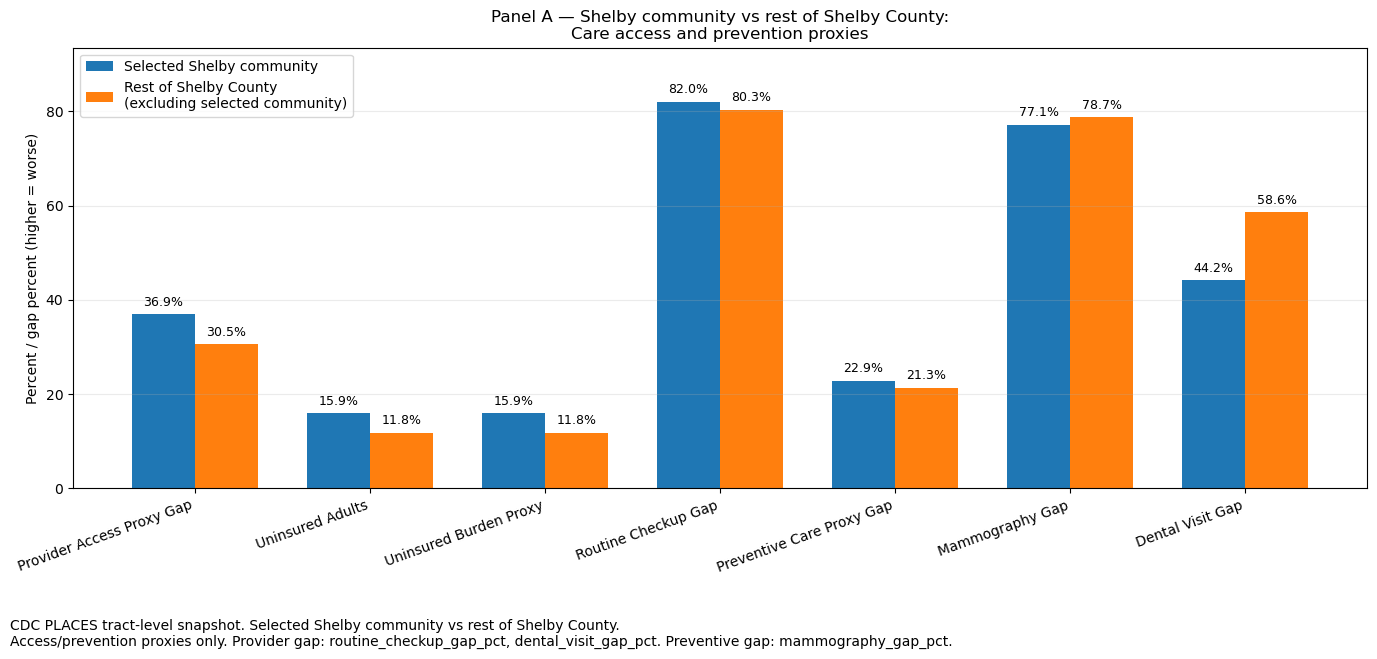

Saved: data\processed\shelby_places_panel_a_access_prevention.png


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,A,provider_access_proxy_gap_pct,Provider Access Proxy Gap,36.91,30.53,6.38,True
1,A,uninsured_adults_pct,Uninsured Adults,15.94,11.82,4.11,True
2,A,uninsured_burden_proxy_pct,Uninsured Burden Proxy,15.94,11.82,4.11,True
3,A,routine_checkup_pct,Routine Checkup Gap,82.03,80.34,1.68,False
4,A,preventive_care_proxy_gap_pct,Preventive Care Proxy Gap,22.86,21.32,1.54,True
5,A,mammography_pct,Mammography Gap,77.14,78.68,-1.54,False
6,A,dental_visit_pct,Dental Visit Gap,44.16,58.59,-14.44,False


In [11]:
# ============================================================
# Cell 7E — Panel A: care access / prevention proxies
# ============================================================

panel_a_extra = (
    "Access/prevention proxies only. "
    f"Provider gap: {shelby_places_compare['provider_inputs_used'].iloc[0]}. "
    f"Preventive gap: {shelby_places_compare['preventive_inputs_used'].iloc[0]}."
)


panel_a_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="A",
    title="Panel A — Shelby community vs rest of Shelby County:\nCare access and prevention proxies",
    outfile_name="shelby_places_panel_a_access_prevention.png",
    extra_footer=panel_a_extra,
    show_bar_labels=True
)

display(panel_a_df.round(2) if panel_a_df is not None else pd.DataFrame())


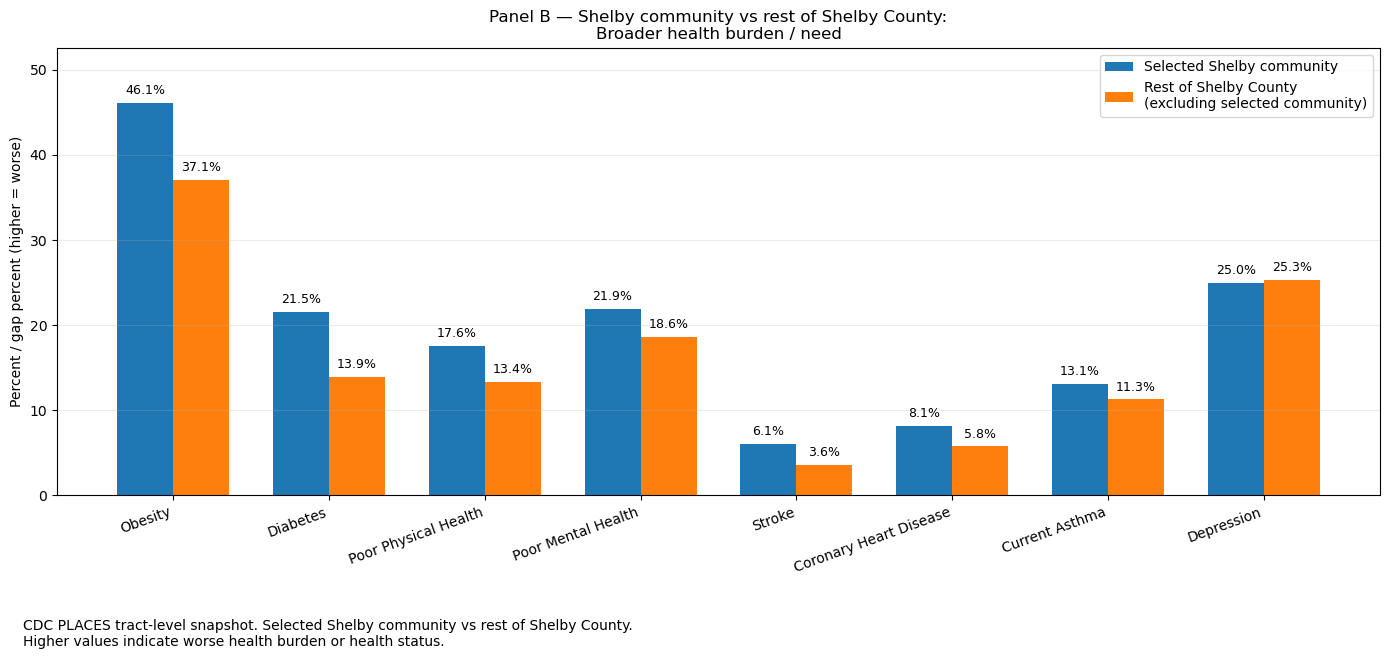

Saved: data\processed\shelby_places_panel_b_burden_need.png


,panel,metric,label,selected_value,rest_value,selected_minus_rest,higher_is_worse_raw
0,B,obesity_pct,Obesity,46.13,37.11,9.02,True
1,B,diabetes_pct,Diabetes,21.55,13.88,7.67,True
2,B,poor_physical_health_pct,Poor Physical Health,17.62,13.38,4.23,True
3,B,poor_mental_health_pct,Poor Mental Health,21.92,18.64,3.27,True
4,B,stroke_pct,Stroke,6.09,3.60,2.49,True
5,B,coronary_heart_disease_pct,Coronary Heart Disease,8.13,5.76,2.37,True
6,B,current_asthma_pct,Current Asthma,13.05,11.28,1.77,True
7,B,depression_pct,Depression,24.96,25.28,-0.32,True


In [12]:
# ============================================================
# Cell 7F — Panel B: broader health burden / need
# ============================================================

panel_b_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="B",
    title="Panel B — Shelby community vs rest of Shelby County:\nBroader health burden / need",
    outfile_name="shelby_places_panel_b_burden_need.png",
    extra_footer="Higher values indicate worse health burden or health status.",
    show_bar_labels=True
)

display(panel_b_df.round(2) if panel_b_df is not None else pd.DataFrame())


In [13]:
# ============================================================
# SHELBY SPLIT HEALTH COMPARISON
# Chart 1: Access Gaps
# Chart 2: Health Burden
# Our community vs Rest of Shelby County vs High-growth comparator
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Validate source table
# --------------------------------------------------
if "shelby_cluster_input" not in globals():
    raise ValueError("`shelby_cluster_input` is not in memory.")

plot_df = shelby_cluster_input.copy()

# --------------------------------------------------
# 2. Choose metrics
# --------------------------------------------------
access_metrics = {
    "uninsured_adults_pct": "Uninsured Adults",
    "routine_checkup_gap_pct": "Routine Checkup Gap",
    "dental_visit_gap_pct": "Dental Visit Gap",
    "mammography_gap_pct": "Mammography Gap",
}

burden_metrics = {
    "diabetes_pct": "Diabetes",
    "obesity_pct": "Obesity",
    "depression_pct": "Depression",
    "current_asthma_pct": "Current Asthma",
}

access_metrics = {k: v for k, v in access_metrics.items() if k in plot_df.columns}
burden_metrics = {k: v for k, v in burden_metrics.items() if k in plot_df.columns}

if len(access_metrics) == 0 and len(burden_metrics) == 0:
    raise ValueError("None of the selected metrics were found in `shelby_cluster_input`.")

# --------------------------------------------------
# 3. Build / recover 3-group membership
# --------------------------------------------------
group_col = None

if "three_group_base" in globals():
    tg = three_group_base.copy()
    possible_group_cols = ["final_compare_group", "group"]
    found_group_col = next((c for c in possible_group_cols if c in tg.columns), None)

    if "geoid" in tg.columns and found_group_col is not None:
        plot_df = plot_df.merge(
            tg[["geoid", found_group_col]].drop_duplicates("geoid"),
            on="geoid",
            how="left"
        )
        group_col = found_group_col

if group_col is None:
    for c in ["final_compare_group", "group"]:
        if c in plot_df.columns:
            group_col = c
            break

if group_col is None:
    if "shelby_full_cluster_id" not in plot_df.columns:
        raise ValueError(
            "Could not find 3-group labels. Run the earlier Shelby 3-group comparison cell first."
        )

    selected_candidates = [
        "SELECTED_SHELBY_CLUSTER_ID",
        "selected_shelby_cluster_id",
        "BEST_SHELBY_CLUSTER_ID",
        "best_shelby_cluster_id",
    ]
    comparator_candidates = [
        "BEST_SHELBY_COMPARATOR_ID",
        "best_shelby_comparator_id",
        "HIGH_GROWTH_SHELBY_CLUSTER_ID",
        "high_growth_shelby_cluster_id",
        "selected_high_growth_cluster_id",
    ]

    selected_id = next((globals()[n] for n in selected_candidates if n in globals()), None)
    comparator_id = next((globals()[n] for n in comparator_candidates if n in globals()), None)

    if selected_id is None or comparator_id is None:
        raise ValueError(
            "Could not reconstruct the 3 Shelby groups automatically. "
            "Run the earlier 3-group Shelby setup cell so `three_group_base` exists."
        )

    def assign_group(cluster_id):
        if cluster_id == selected_id:
            return "Selected low-growth community"
        elif cluster_id == comparator_id:
            return "Selected high-growth comparator"
        else:
            return "Rest of Shelby County (excluding both selected communities)"

    plot_df["final_compare_group"] = plot_df["shelby_full_cluster_id"].apply(assign_group)
    group_col = "final_compare_group"

# --------------------------------------------------
# 4. Labels / colors
# --------------------------------------------------
group_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

# --------------------------------------------------
# 5. Weighted average helper
# --------------------------------------------------
def safe_weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)

    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return values.loc[valid].mean()

    return np.average(values.loc[mask], weights=weights.loc[mask])

if "pop_total_recovery" not in plot_df.columns:
    raise ValueError("`pop_total_recovery` is missing from `shelby_cluster_input`.")

# --------------------------------------------------
# 6. Build summary helper
# --------------------------------------------------
def build_summary(metric_dict):
    rows = []

    for grp in group_order:
        grp_df = plot_df.loc[plot_df[group_col] == grp].copy()
        weights = grp_df["pop_total_recovery"]

        row = {"group": grp}
        for col, pretty in metric_dict.items():
            row[pretty] = safe_weighted_mean(grp_df[col], weights)
        rows.append(row)

    out = pd.DataFrame(rows).set_index("group")
    return out.loc[group_order]

access_compare = build_summary(access_metrics) if len(access_metrics) > 0 else None
burden_compare = build_summary(burden_metrics) if len(burden_metrics) > 0 else None

if access_compare is not None:
    display(access_compare)

if burden_compare is not None:
    display(burden_compare)

# --------------------------------------------------
# 7. Plot helper
# --------------------------------------------------
def plot_grouped_bars(ax, compare_df, title, ylabel):
    metric_names = list(compare_df.columns)
    x = np.arange(len(metric_names))
    bar_w = 0.24

    for i, grp in enumerate(group_order):
        vals = compare_df.loc[grp, metric_names].values
        ax.bar(
            x + (i - 1) * bar_w,
            vals,
            width=bar_w,
            color=color_map[grp],
            label=label_map[grp],
            edgecolor="none"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=0, ha="center")
    ax.yaxis.set_major_formatter(lambda val, pos: f"{val:.0f}%")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_title(title, fontsize=16, pad=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Metric")

    for i, grp in enumerate(group_order):
        vals = compare_df.loc[grp, metric_names].values
        for j, v in enumerate(vals):
            if pd.notna(v):
                ax.text(
                    x[j] + (i - 1) * bar_w,
                    v + 0.35,
                    f"{v:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

# --------------------------------------------------
# 8. Create figure
# --------------------------------------------------
n_panels = int(access_compare is not None) + int(burden_compare is not None)

if n_panels == 1:
    fig, ax = plt.subplots(figsize=(14, 8))
    axes = [ax]
else:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

plot_idx = 0

if access_compare is not None:
    plot_grouped_bars(
        axes[plot_idx],
        access_compare,
        "Shelby healthcare access gaps",
        "Population-weighted gap / access burden"
    )
    plot_idx += 1

if burden_compare is not None:
    plot_grouped_bars(
        axes[plot_idx],
        burden_compare,
        "Shelby health burden proxies",
        "Population-weighted prevalence / burden"
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=True
)

fig.text(
    0.02, 0.02,
    "Recovery-period tract-level proxy measures, population-weighted within each comparison group.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

# --------------------------------------------------
# 9. Save
# --------------------------------------------------
out_path = OUT_DIR / "shelby_split_access_burden_comparison.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

ValueError: `shelby_cluster_input` is not in memory.

In [ ]:
# ============================================================
# Cell 7G — Panel C: barriers / risk
# ============================================================

panel_c_df = plot_places_panel(
    summary_df=shelby_places_summary,
    panel_code="C",
    title="Panel C — Shelby community vs rest of Shelby County:\nBarriers and risk factors",
    outfile_name="shelby_places_panel_c_barriers_risk.png",
    extra_footer="Higher values indicate more risk behaviors or more barriers to health."
)

display(panel_c_df.round(2) if panel_c_df is not None else pd.DataFrame())


In [ ]:
# ============================================================
# Cell 7H — ranked gap table
# ============================================================

ranked_gaps = (
    shelby_places_summary.loc[shelby_places_summary["selected_minus_rest"].notna()]
    .sort_values("selected_minus_rest", ascending=False)
    .reset_index(drop=True)
)

print("Top metrics where the selected Shelby community is worse than the rest of Shelby County:")
display(ranked_gaps.head(20).round(2))

ranked_gaps.to_csv(OUT_DIR / "shelby_places_ranked_gaps.csv", index=False)
print("Saved:", OUT_DIR / "shelby_places_ranked_gaps.csv")


### Cell 8A — Shelby tract-level base for comparison-community search

In [ ]:
# ============================================================
# Cell 8A — Shelby tract-level base for comparison-community search
# TRACT-LEVEL ONLY:
# - recovery economics from analysis_panel (tract-year -> tract average)
# - CDC PLACES from shelby_places_base (tract snapshot)
# ============================================================

import pandas as pd
import numpy as np

RECOVERY_YEARS = [2022, 2023, 2024]

# -----------------------------
# 1) tract-level recovery economics
# -----------------------------
shelby_recovery = (
    analysis_panel.loc[
        (analysis_panel["display_state"].astype(str) == "Tennessee") &
        (analysis_panel["display_county"].astype(str) == "Shelby County") &
        (analysis_panel["year"].isin(RECOVERY_YEARS)),
        [
            "geoid", "year", "pop_total",
            "igs_total", "igs_economy",
            "poverty_rate", "unemp_rate",
            "median_household_income", "lfpr_16p"
        ]
    ]
    .copy()
)

shelby_recovery["geoid"] = normalize_geoid_series(shelby_recovery["geoid"])

shelby_tract_recovery = (
    shelby_recovery
    .groupby("geoid", as_index=False)
    .agg(
        pop_total_recovery=("pop_total", "mean"),
        igs_total_recovery=("igs_total", "mean"),
        igs_economy_recovery=("igs_economy", "mean"),
        poverty_rate_recovery=("poverty_rate", "mean"),
        unemp_rate_recovery=("unemp_rate", "mean"),
        median_household_income_recovery=("median_household_income", "mean"),
        lfpr_16p_recovery=("lfpr_16p", "mean"),
    )
)

print("Shelby tract recovery rows:", shelby_tract_recovery.shape)
display(shelby_tract_recovery.head())

# -----------------------------
# 2) tract-level CDC PLACES features
# -----------------------------
shelby_cdc_tract = shelby_places_base.copy()
shelby_cdc_tract["geoid"] = normalize_geoid_series(shelby_cdc_tract["geoid"])

# Create tract-level gap versions where possible
positive_use_metrics = {
    "routine_checkup_pct": "routine_checkup_gap_pct",
    "dental_visit_pct": "dental_visit_gap_pct",
    "mammography_pct": "mammography_gap_pct",
    "flu_vax_pct": "flu_vax_gap_pct",
}

for src, dst in positive_use_metrics.items():
    if src in shelby_cdc_tract.columns:
        shelby_cdc_tract[dst] = 100 - pd.to_numeric(shelby_cdc_tract[src], errors="coerce")

cdc_metric_candidates = [
    # Panel A
    "uninsured_adults_pct",
    "routine_checkup_gap_pct",
    "dental_visit_gap_pct",
    "mammography_gap_pct",
    "flu_vax_gap_pct",

    # Panel B
    "fair_poor_health_pct",
    "poor_physical_health_pct",
    "poor_mental_health_pct",
    "depression_pct",
    "diabetes_pct",
    "obesity_pct",
    "current_asthma_pct",
    "coronary_heart_disease_pct",
    "stroke_pct",

    # Panel C
    "smoking_pct",
    "physical_inactivity_pct",
    "binge_drinking_pct",
    "sleep_lt7_pct",
    "food_insecurity_pct",
    "housing_insecurity_pct",
    "transportation_barriers_pct",
    "social_isolation_pct",
]

available_cdc_metrics = [
    c for c in cdc_metric_candidates
    if c in shelby_cdc_tract.columns and shelby_cdc_tract[c].notna().any()
]

shelby_cdc_tract = shelby_cdc_tract[["geoid"] + available_cdc_metrics].drop_duplicates(subset=["geoid"]).copy()

print("Available tract-level CDC metrics:", available_cdc_metrics)
print("Shelby CDC tract rows:", shelby_cdc_tract.shape)
display(shelby_cdc_tract.head())

# -----------------------------
# 3) full Shelby tract-level base
# -----------------------------
shelby_full_tract_base = (
    shelby_tract_recovery
    .merge(shelby_cdc_tract, on="geoid", how="left", validate="1:1")
    .copy()
)

print("Shelby full tract-level base:", shelby_full_tract_base.shape)
display(shelby_full_tract_base.head())


### Cell 8B — load all Shelby tract geometries + tract adjacency


In [ ]:
# ============================================================
# Cell 8B — load all Shelby tract geometries + tract adjacency
# ============================================================

import geopandas as gpd
from pathlib import Path

# Reuse repo path discovery pattern
ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "src",
    Path.cwd().parent,
]

RAW_DIR = None
PROCESSED_DIR = None

for root in ROOT_CANDIDATES:
    if (root / "src/data/raw").exists():
        RAW_DIR = root / "src/data/raw"
        PROCESSED_DIR = root / "src/data/processed"
        break
    if (root / "data/raw").exists():
        RAW_DIR = root / "data/raw"
        PROCESSED_DIR = root / "data/processed"
        break

if RAW_DIR is None:
    raise FileNotFoundError("Could not find data/raw or src/data/raw.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Find Tennessee tract shapefile
shp_candidates = list(RAW_DIR.rglob("*47*tract*.shp")) + list(RAW_DIR.rglob("*tract*.shp"))

tract_shp = None
for p in shp_candidates:
    name = p.name.lower()
    parent = str(p.parent).lower()
    if "tract" in name and ("47" in name or "tennessee" in name or "state_tract" in parent):
        tract_shp = p
        break

if tract_shp is None:
    raise FileNotFoundError("Could not find a Tennessee tract shapefile in data/raw.")

print("Using tract shapefile:", tract_shp)

tracts = gpd.read_file(tract_shp).copy()

# Standardize GEOID
possible_geoid_cols = ["GEOID", "geoid", "GEOIDFQ", "TRACTCE"]
geoid_col = None
for c in possible_geoid_cols:
    if c in tracts.columns:
        geoid_col = c
        break

if geoid_col is None:
    raise ValueError(f"Could not find a GEOID-like column. Columns: {list(tracts.columns)}")

if geoid_col == "TRACTCE":
    if not all(c in tracts.columns for c in ["STATEFP", "COUNTYFP", "TRACTCE"]):
        raise ValueError("TRACTCE found, but STATEFP/COUNTYFP/TRACTCE not all present.")
    tracts["geoid"] = (
        tracts["STATEFP"].astype(str).str.zfill(2)
        + tracts["COUNTYFP"].astype(str).str.zfill(3)
        + tracts["TRACTCE"].astype(str).str.zfill(6)
    )
else:
    tracts["geoid"] = tracts[geoid_col].astype(str).str.extract(r"(\d{11})", expand=False)
    if tracts["geoid"].isna().all():
        tracts["geoid"] = tracts[geoid_col].astype(str).str.zfill(11)

# Keep Shelby County only
if "STATEFP" in tracts.columns and "COUNTYFP" in tracts.columns:
    shelby_geo = tracts.loc[
        (tracts["STATEFP"].astype(str).str.zfill(2) == "47") &
        (tracts["COUNTYFP"].astype(str).str.zfill(3) == "157")
    ].copy()
else:
    shelby_geo = tracts.loc[tracts["geoid"].str[:5] == "47157"].copy()

# Keep only tracts that exist in the tract-level base
shelby_geo["geoid"] = normalize_geoid_series(shelby_geo["geoid"])
shelby_geo = shelby_geo.loc[shelby_geo["geoid"].isin(shelby_full_tract_base["geoid"])].copy()

print("Shelby geometry rows kept:", shelby_geo.shape)

# Build adjacency from touching polygons
left = shelby_geo[["geoid", "geometry"]].rename(columns={"geoid": "geoid_left"})
right = shelby_geo[["geoid", "geometry"]].rename(columns={"geoid": "geoid_right"})

adj = gpd.sjoin(left, right, how="inner", predicate="touches")
adj = adj.loc[adj["geoid_left"] != adj["geoid_right"], ["geoid_left", "geoid_right"]].drop_duplicates()

print("Shelby adjacency edges:", adj.shape)
display(adj.head())


### Cell 8C — full-county Shelby community map

In [ ]:
# ============================================================
# Cell 8C — full-county Shelby community map
# IMPORTANT:
# We do NOT use connected components alone, because Shelby is contiguous.
# We use spatially constrained clustering:
# - adjacency enforces contiguity
# - tract-level recovery + CDC metrics define similarity
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.sparse import coo_matrix

# Number of Shelby communities to create
# You can tune this later. 6 is a good first pass.
N_SHELBY_COMMUNITIES = 6

# Merge tract base with geometry
shelby_cluster_input = (
    shelby_geo[["geoid", "geometry"]]
    .merge(shelby_full_tract_base, on="geoid", how="inner", validate="1:1")
    .copy()
)

# Tract-level features only
feature_candidates = [
    # Recovery economics
    "igs_total_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",

    # Panel A
    "uninsured_adults_pct",
    "routine_checkup_gap_pct",
    "dental_visit_gap_pct",
    "mammography_gap_pct",
    "flu_vax_gap_pct",

    # Panel B
    "fair_poor_health_pct",
    "poor_physical_health_pct",
    "poor_mental_health_pct",
    "depression_pct",
    "diabetes_pct",
    "obesity_pct",
    "current_asthma_pct",
    "coronary_heart_disease_pct",
    "stroke_pct",

    # Panel C
    "smoking_pct",
    "physical_inactivity_pct",
    "binge_drinking_pct",
    "sleep_lt7_pct",
    "food_insecurity_pct",
    "housing_insecurity_pct",
    "transportation_barriers_pct",
    "social_isolation_pct",
]

available_features = [
    c for c in feature_candidates
    if c in shelby_cluster_input.columns and shelby_cluster_input[c].notna().any()
]

if not available_features:
    raise ValueError("No tract-level features available for Shelby clustering.")

print("Features used for Shelby community map:")
print(available_features)

X = shelby_cluster_input[available_features].copy()

# Flip higher-is-better economics so higher values consistently mean "more vulnerable"
for col in ["igs_total_recovery", "igs_economy_recovery", "median_household_income_recovery", "lfpr_16p_recovery"]:
    if col in X.columns:
        X[col] = -pd.to_numeric(X[col], errors="coerce")

# Impute + scale
X = SimpleImputer(strategy="median").fit_transform(X)
X = StandardScaler().fit_transform(X)

# Sparse adjacency matrix
geoid_order = shelby_cluster_input["geoid"].tolist()
idx_map = {g: i for i, g in enumerate(geoid_order)}

edge_df = adj.loc[
    adj["geoid_left"].isin(idx_map) & adj["geoid_right"].isin(idx_map)
].copy()

rows = edge_df["geoid_left"].map(idx_map).to_numpy()
cols = edge_df["geoid_right"].map(idx_map).to_numpy()
data = np.ones(len(edge_df), dtype=int)

connectivity = coo_matrix((data, (rows, cols)), shape=(len(geoid_order), len(geoid_order)))
connectivity = connectivity.maximum(connectivity.T)

# Spatially constrained clustering
try:
    cluster_model = AgglomerativeClustering(
        n_clusters=N_SHELBY_COMMUNITIES,
        linkage="ward",
        metric="euclidean",
        connectivity=connectivity
    )
except TypeError:
    cluster_model = AgglomerativeClustering(
        n_clusters=N_SHELBY_COMMUNITIES,
        linkage="ward",
        affinity="euclidean",
        connectivity=connectivity
    )

labels = cluster_model.fit_predict(X)

shelby_cluster_input["shelby_full_cluster_label"] = labels
shelby_cluster_input["shelby_full_cluster_id"] = [
    f"Shelby County full community {int(x)+1}"
    for x in labels
]

print("Shelby full-community tract counts:")
display(
    shelby_cluster_input["shelby_full_cluster_id"]
    .value_counts()
    .rename_axis("community")
    .reset_index(name="tract_count")
)

# Save tract-level community map
shelby_full_tract_cluster_map = shelby_cluster_input[["geoid", "geometry", "shelby_full_cluster_id"]].copy()
shelby_full_tract_cluster_map.to_file(
    OUT_DIR / "shelby_full_tract_cluster_map.geojson",
    driver="GeoJSON"
)

print("Saved:", OUT_DIR / "shelby_full_tract_cluster_map.geojson")


### Cell 8D — aggregate Shelby full communities

In [ ]:
# ============================================================
# Cell 8D — aggregate Shelby full communities
# TRACT-LEVEL ONLY aggregation
# ============================================================

def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

community_metric_cols = [c for c in available_features if c in shelby_cluster_input.columns]

community_rows = []
for community_id, grp in shelby_cluster_input.groupby("shelby_full_cluster_id", dropna=False):
    weights = grp["pop_total_recovery"] if "pop_total_recovery" in grp.columns else pd.Series(np.ones(len(grp)), index=grp.index)

    row = {
        "community_id": community_id,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total_recovery"], errors="coerce").fillna(0).sum()),
    }

    for col in community_metric_cols:
        row[col] = weighted_mean_safe(grp[col], weights)

    community_rows.append(row)

shelby_full_community_compare = pd.DataFrame(community_rows)

# Useful tract-level proxy summaries
access_cols = [
    c for c in [
        "uninsured_adults_pct",
        "routine_checkup_gap_pct",
        "dental_visit_gap_pct",
        "mammography_gap_pct",
        "flu_vax_gap_pct",
    ] if c in shelby_full_community_compare.columns
]

burden_cols = [
    c for c in [
        "fair_poor_health_pct",
        "poor_physical_health_pct",
        "poor_mental_health_pct",
        "depression_pct",
        "diabetes_pct",
        "obesity_pct",
        "current_asthma_pct",
        "coronary_heart_disease_pct",
        "stroke_pct",
    ] if c in shelby_full_community_compare.columns
]

barrier_cols = [
    c for c in [
        "smoking_pct",
        "physical_inactivity_pct",
        "binge_drinking_pct",
        "sleep_lt7_pct",
        "food_insecurity_pct",
        "housing_insecurity_pct",
        "transportation_barriers_pct",
        "social_isolation_pct",
    ] if c in shelby_full_community_compare.columns
]

if access_cols:
    shelby_full_community_compare["access_proxy_mean_pct"] = shelby_full_community_compare[access_cols].mean(axis=1, skipna=True)
if burden_cols:
    shelby_full_community_compare["burden_proxy_mean_pct"] = shelby_full_community_compare[burden_cols].mean(axis=1, skipna=True)
if barrier_cols:
    shelby_full_community_compare["barrier_proxy_mean_pct"] = shelby_full_community_compare[barrier_cols].mean(axis=1, skipna=True)

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in shelby_full_community_compare.columns]

display(
    shelby_full_community_compare[display_cols]
    .sort_values(["igs_total_recovery", "igs_economy_recovery"], ascending=[False, False])
    .round(2)
)

shelby_full_community_compare.to_csv(OUT_DIR / "shelby_full_community_compare.csv", index=False)
print("Saved:", OUT_DIR / "shelby_full_community_compare.csv")


### Cell 8E — selected Shelby community benchmark

In [ ]:
# ============================================================
# Cell 8E — selected Shelby community benchmark
# Uses the SAME tract-level base as the full-county communities
# ============================================================

SELECTED_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"

selected_geoids = set()

if "tract_cluster_map" in globals():
    tmp = tract_cluster_map.copy()
    if "geoid" in tmp.columns and "cluster_id" in tmp.columns:
        tmp["geoid"] = normalize_geoid_series(tmp["geoid"])
        selected_geoids = set(
            tmp.loc[tmp["cluster_id"].astype(str) == SELECTED_CLUSTER_ID, "geoid"]
            .dropna()
            .tolist()
        )

if not selected_geoids and "TARGET_GEOIDS" in globals():
    selected_geoids = set(normalize_geoid_series(pd.Series(TARGET_GEOIDS)).dropna().tolist())

if not selected_geoids:
    raise ValueError("Could not recover the selected Shelby community GEOIDs.")

selected_benchmark_tracts = shelby_cluster_input.loc[
    shelby_cluster_input["geoid"].isin(selected_geoids)
].copy()

if selected_benchmark_tracts.empty:
    raise ValueError("Selected Shelby community has no overlap with the Shelby tract-level base.")

weights = selected_benchmark_tracts["pop_total_recovery"]

selected_benchmark = {
    "community_id": "Selected Shelby community",
    "n_tracts": int(selected_benchmark_tracts["geoid"].nunique()),
    "population_sum": float(pd.to_numeric(selected_benchmark_tracts["pop_total_recovery"], errors="coerce").fillna(0).sum()),
}

for col in community_metric_cols:
    selected_benchmark[col] = weighted_mean_safe(selected_benchmark_tracts[col], weights)

selected_benchmark = pd.Series(selected_benchmark)

# proxy summaries
if access_cols:
    selected_benchmark["access_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in access_cols])
if burden_cols:
    selected_benchmark["burden_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in burden_cols])
if barrier_cols:
    selected_benchmark["barrier_proxy_mean_pct"] = np.nanmean([selected_benchmark.get(c, np.nan) for c in barrier_cols])

display(pd.DataFrame([selected_benchmark]).round(2))


### Cell 8F — identify a better Shelby comparison community

In [ ]:
# ============================================================
# Cell 8F — identify a better Shelby comparison community
# Rules:
# - same county
# - no overlap with selected Shelby community
# - tract-level recovery IGS > 45
# - stronger recovery economics
# - lower access/burden/barrier proxy means where available
# ============================================================

# Count overlap with selected community
selected_geoid_set = set(selected_benchmark_tracts["geoid"].tolist())

overlap_rows = []
for community_id, grp in shelby_cluster_input.groupby("shelby_full_cluster_id", dropna=False):
    overlap_rows.append({
        "community_id": community_id,
        "selected_overlap_tracts": int(grp["geoid"].isin(selected_geoid_set).sum())
    })

overlap_df = pd.DataFrame(overlap_rows)

candidate_df = (
    shelby_full_community_compare
    .merge(overlap_df, on="community_id", how="left", validate="1:1")
    .copy()
)

# Hard filters
eligibility = pd.Series(True, index=candidate_df.index)

# Must not overlap selected cluster
eligibility &= candidate_df["selected_overlap_tracts"].fillna(0).eq(0)

# Avoid tiny communities
eligibility &= candidate_df["n_tracts"] >= 5
eligibility &= candidate_df["population_sum"] >= 10000

# Must be clearly less vulnerable on tract-level recovery IGS
if "igs_total_recovery" in candidate_df.columns and pd.notna(selected_benchmark.get("igs_total_recovery", np.nan)):
    eligibility &= candidate_df["igs_total_recovery"] > 45
    eligibility &= candidate_df["igs_total_recovery"] > selected_benchmark["igs_total_recovery"]

# Better tract-level economics
for col, op in [
    ("igs_economy_recovery", "gt"),
    ("poverty_rate_recovery", "lt"),
    ("unemp_rate_recovery", "lt"),
    ("median_household_income_recovery", "gt"),
    ("lfpr_16p_recovery", "gt"),
]:
    if col in candidate_df.columns and pd.notna(selected_benchmark.get(col, np.nan)):
        if op == "gt":
            eligibility &= candidate_df[col] > selected_benchmark[col]
        else:
            eligibility &= candidate_df[col] < selected_benchmark[col]

# Better tract-level access / burden / barriers where available
for col in ["access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct"]:
    if col in candidate_df.columns and pd.notna(selected_benchmark.get(col, np.nan)):
        eligibility &= candidate_df[col] < selected_benchmark[col]

eligible_candidates = candidate_df.loc[eligibility].copy()

print("Eligible better Shelby communities found:", len(eligible_candidates))

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in eligible_candidates.columns]

display(
    eligible_candidates[display_cols]
    .sort_values(["igs_total_recovery", "igs_economy_recovery"], ascending=[False, False])
    .round(2)
)

if eligible_candidates.empty:
    print("No community passed the strict screen. Relax one filter and rerun.")


### Cell 8G — rank the eligible candidates

In [ ]:
# ============================================================
# Cell 8G — rank the eligible candidates
# ============================================================

rank_df = eligible_candidates.copy()

if rank_df.empty:
    raise ValueError("No eligible candidates to rank. Relax the rules in Cell 8F.")

score_cols = []

def add_rank_component(df, col, ascending, new_col):
    if col in df.columns:
        df[new_col] = df[col].rank(pct=True, ascending=ascending)
        score_cols.append(new_col)

# better if larger
add_rank_component(rank_df, "igs_total_recovery", ascending=True, new_col="rank_igs_total")
add_rank_component(rank_df, "igs_economy_recovery", ascending=True, new_col="rank_igs_economy")
add_rank_component(rank_df, "median_household_income_recovery", ascending=True, new_col="rank_income")
add_rank_component(rank_df, "lfpr_16p_recovery", ascending=True, new_col="rank_lfpr")

# better if smaller
add_rank_component(rank_df, "poverty_rate_recovery", ascending=False, new_col="rank_poverty")
add_rank_component(rank_df, "unemp_rate_recovery", ascending=False, new_col="rank_unemp")
add_rank_component(rank_df, "access_proxy_mean_pct", ascending=False, new_col="rank_access")
add_rank_component(rank_df, "burden_proxy_mean_pct", ascending=False, new_col="rank_burden")
add_rank_component(rank_df, "barrier_proxy_mean_pct", ascending=False, new_col="rank_barrier")

rank_df["comparison_rank_score"] = rank_df[score_cols].mean(axis=1, skipna=True)

rank_df = rank_df.sort_values(
    ["comparison_rank_score", "igs_total_recovery", "igs_economy_recovery"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(
    rank_df[
        [c for c in [
            "community_id", "comparison_rank_score",
            "n_tracts", "population_sum",
            "igs_total_recovery", "igs_economy_recovery",
            "poverty_rate_recovery", "unemp_rate_recovery",
            "median_household_income_recovery", "lfpr_16p_recovery",
            "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct"
        ] if c in rank_df.columns]
    ].head(10).round(3)
)

BEST_SHELBY_COMPARATOR_ID = rank_df.iloc[0]["community_id"]
print("Best Shelby comparator selected:", BEST_SHELBY_COMPARATOR_ID)

rank_df.to_csv(OUT_DIR / "shelby_better_community_candidates_ranked.csv", index=False)
print("Saved:", OUT_DIR / "shelby_better_community_candidates_ranked.csv")


### Cell 8H — selected vs better Shelby comparison table

In [ ]:
# ============================================================
# Cell 8H — selected vs better Shelby comparison table
# ============================================================

best_row = rank_df.loc[rank_df["community_id"] == BEST_SHELBY_COMPARATOR_ID].iloc[0]

selected_vs_better = pd.DataFrame([
    selected_benchmark.to_dict(),
    best_row.to_dict()
])

display_cols = [
    "community_id", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in selected_vs_better.columns]

display(selected_vs_better[display_cols].round(2))

selected_vs_better.to_csv(OUT_DIR / "selected_vs_better_shelby_community.csv", index=False)
print("Saved:", OUT_DIR / "selected_vs_better_shelby_community.csv")


### Cell 8I — map the 6 Shelby full communities

In [ ]:
# ============================================================
# Cell 8I — map the 6 Shelby full communities
# ============================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------------------------------
# 1) Recover community geometry table
# --------------------------------------------------
if "shelby_full_tract_cluster_map" in globals():
    map_gdf = shelby_full_tract_cluster_map.copy()
elif "shelby_cluster_input" in globals():
    map_gdf = shelby_cluster_input[["geoid", "geometry", "shelby_full_cluster_id"]].copy()
else:
    raise ValueError(
        "Could not find shelby_full_tract_cluster_map or shelby_cluster_input. "
        "Run Cells 8B–8C first."
    )

if "shelby_full_cluster_id" not in map_gdf.columns:
    raise ValueError("Expected column 'shelby_full_cluster_id' not found.")

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=getattr(map_gdf, "crs", None))
map_gdf["geoid"] = normalize_geoid_series(map_gdf["geoid"])

# Use Shelby geometry CRS if available
if "shelby_geo" in globals():
    county_base = shelby_geo.copy()
else:
    county_base = map_gdf.copy()

# Reproject for cleaner plotting
if map_gdf.crs is not None:
    map_gdf = map_gdf.to_crs(3857)
    county_base = county_base.to_crs(3857)

county_outline = county_base.dissolve()

# --------------------------------------------------
# 2) Sort community IDs in numeric order
# --------------------------------------------------
def extract_num(s):
    m = re.search(r"(\d+)$", str(s))
    return int(m.group(1)) if m else 9999

community_order = sorted(map_gdf["shelby_full_cluster_id"].dropna().unique().tolist(), key=extract_num)
map_gdf["shelby_full_cluster_id"] = pd.Categorical(
    map_gdf["shelby_full_cluster_id"],
    categories=community_order,
    ordered=True
)

# --------------------------------------------------
# 3) Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Fill tracts by community
map_gdf.plot(
    ax=ax,
    column="shelby_full_cluster_id",
    categorical=True,
    cmap="tab20",
    edgecolor="white",
    linewidth=0.45,
    legend=True,
    legend_kwds={
        "title": "Shelby full communities",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0)
    }
)

# County outline
county_outline.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    zorder=3
)

# --------------------------------------------------
# 4) Add labels at representative points
# --------------------------------------------------
community_shapes = map_gdf.dissolve(by="shelby_full_cluster_id").reset_index()
community_shapes["label_pt"] = community_shapes.representative_point()

for _, row in community_shapes.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    label = str(row["shelby_full_cluster_id"]).replace("Shelby County full community ", "Community ")
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.85),
        zorder=4
    )

ax.set_title("Shelby County full-community map", fontsize=17)
ax.set_axis_off()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5) Save
# --------------------------------------------------
map_path = OUT_DIR / "shelby_full_communities_map.png"
fig.savefig(map_path, bbox_inches="tight", dpi=220)
print("Saved:", map_path)


In [ ]:
# ============================================================
# Cell 8K — Shelby adult education comparison using Bachelor's+
# Uses acs_features.parquet -> ba_plus_share_25p
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

if "three_group_base" not in globals():
    raise ValueError("Run Cell 8I first so three_group_base exists.")

# -----------------------------
# helpers
# -----------------------------
def _normalize_geoid(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_mask = numeric.notna()
    s = s.copy()
    s.loc[numeric_mask] = numeric.loc[numeric_mask].astype("Int64").astype("string")
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def _weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        return float(values.loc[valid].mean()) if valid.sum() > 0 else np.nan
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

def _to_share(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    if s.dropna().empty:
        return s
    if s.dropna().max() > 1.5:
        return s / 100.0
    return s

# -----------------------------
# load ACS features
# -----------------------------
acs_candidates = [
    Path("data/processed/acs_features.parquet"),
    Path("src/data/processed/acs_features.parquet"),
]

acs_path = next((p for p in acs_candidates if p.exists()), None)
if acs_path is None:
    raise FileNotFoundError("Could not find acs_features.parquet")

acs_edu = pd.read_parquet(acs_path).copy()
print("Using education source:", acs_path)

required_cols = ["geoid", "year", "pop_total", "ba_plus_share_25p"]
missing = [c for c in required_cols if c not in acs_edu.columns]
if missing:
    raise ValueError(f"acs_features.parquet is missing required columns: {missing}")

acs_edu["geoid"] = _normalize_geoid(acs_edu["geoid"])
acs_edu["year"] = pd.to_numeric(acs_edu["year"], errors="coerce").astype("Int64")
acs_edu = acs_edu.loc[acs_edu["year"].isin(RECOVERY_YEARS)].copy()
acs_edu["year"] = acs_edu["year"].astype(int)

acs_edu["Bachelor's+"] = _to_share(acs_edu["ba_plus_share_25p"])

# -----------------------------
# 3-group lookup
# -----------------------------
group_lookup = (
    three_group_base[["geoid", "final_compare_group"]]
    .drop_duplicates()
    .copy()
)
group_lookup["geoid"] = _normalize_geoid(group_lookup["geoid"])

group_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

acs_edu = acs_edu.merge(
    group_lookup,
    on="geoid",
    how="inner",
    validate="many_to_one"
)

# -----------------------------
# tract-level recovery average
# -----------------------------
education_tract = (
    acs_edu[
        ["geoid", "final_compare_group", "pop_total", "Bachelor's+"]
    ]
    .groupby(["geoid", "final_compare_group"], as_index=False)
    .agg({
        "pop_total": "mean",
        "Bachelor's+": "mean",
    })
    .copy()
)

# -----------------------------
# group-level summary
# -----------------------------
rows = []
for grp in group_order:
    sub = education_tract.loc[
        education_tract["final_compare_group"] == grp
    ].copy()

    row = {
        "group": grp,
        "group_label": label_map[grp],
        "n_tracts": int(sub["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(sub["pop_total"], errors="coerce").sum()),
        "Bachelor's+": _weighted_mean(sub["Bachelor's+"], sub["pop_total"]),
    }
    rows.append(row)

education_compare = pd.DataFrame(rows)
education_compare["group"] = pd.Categorical(
    education_compare["group"],
    categories=group_order,
    ordered=True
)
education_compare = education_compare.sort_values("group").reset_index(drop=True)

education_mode = "adult_attainment_single_metric"

# -----------------------------
# save
# -----------------------------
if "OUT_DIR" not in globals():
    OUT_DIR = Path("data/processed")

DEMO_OUT_DIR = OUT_DIR if Path(OUT_DIR).name == "presentation_ready" else (Path(OUT_DIR) / "presentation_ready")
DEMO_OUT_DIR.mkdir(parents=True, exist_ok=True)

education_compare.to_csv(DEMO_OUT_DIR / "shelby_education_compare.csv", index=False)

print("\nSaved:", DEMO_OUT_DIR / "shelby_education_compare.csv")
display(education_compare.round(4))

In [ ]:
# ============================================================
# Cell 8L — Shelby demographic comparison chart (vertical)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

if "demographic_compare" not in globals():
    raise ValueError("Run Cell 8K first.")

plot_groups = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

meta_cols = {"group", "group_label", "n_tracts", "population_sum"}
plot_categories = [c for c in demographic_compare.columns if c not in meta_cols]

demo_plot_df = demographic_compare.copy()
demo_plot_df = demo_plot_df.set_index("group").loc[plot_groups].reset_index()

fig, ax = plt.subplots(figsize=(13, 8))

x = np.arange(len(plot_categories))
bar_w = 0.24
offsets = [-bar_w, 0, bar_w]

for grp, off in zip(plot_groups, offsets):
    row = demo_plot_df.loc[demo_plot_df["group"] == grp].iloc[0]
    vals = [row.get(cat, np.nan) for cat in plot_categories]

    ax.bar(
        x + off,
        vals,
        width=bar_w,
        color=color_map[grp],
        label=label_map[grp]
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v >= 0.05 and v <= 1.05:
            ax.text(
                x[i] + off,
                v + 0.015,
                f"{v:.0%}",
                ha="center",
                va="bottom",
                fontsize=10
            )

ax.set_xticks(x)
ax.set_xticklabels(plot_categories, fontsize=11, rotation=15)
ymax = max(0.65, float(np.nanmax(demo_plot_df[plot_categories].to_numpy())) + 0.10)
ax.set_ylim(0, min(ymax, 1.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.grid(axis="y", alpha=0.25)
ax.set_title("Shelby demographic comparison", fontsize=18, pad=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=True)

fig.text(
    0.02, 0.02,
    "Recovery-period averages (2022–2024), aggregated from tract-level race / ethnicity shares available in the current panel.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

out_path = DEMO_OUT_DIR / "shelby_visual_demographic_comparison.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

In [ ]:
# ============================================================
# Cell 8M — Shelby adult education comparison (vertical)
# Bachelor's+ only
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

if "education_compare" not in globals() or education_compare is None:
    raise ValueError("Run the Bachelor's+ education build cell first.")

plot_groups = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

edu_plot_df = education_compare.copy()
edu_plot_df = edu_plot_df.set_index("group").loc[plot_groups].reset_index()

fig, ax = plt.subplots(figsize=(10, 7))

x = np.arange(len(plot_groups))
vals = [edu_plot_df.loc[edu_plot_df["group"] == grp, "Bachelor's+"].iloc[0] for grp in plot_groups]
colors = [color_map[grp] for grp in plot_groups]
labels = [label_map[grp] for grp in plot_groups]

bars = ax.bar(x, vals, color=colors, width=0.65)

for i, v in enumerate(vals):
    if pd.notna(v):
        ax.text(
            x[i],
            v + 0.01,
            f"{v:.1%}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, rotation=0)
ax.set_ylim(0, min(max(vals) + 0.08, 1.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.grid(axis="y", alpha=0.25)

ax.set_title("Shelby adult education attainment comparison", fontsize=18, pad=14)

fig.text(
    0.02, 0.02,
    "Share of adults age 25+ with a bachelor's degree or higher, using recovery-period averages (2022–2024).",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

out_path = DEMO_OUT_DIR / "shelby_visual_education_comparison.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

### Cell 8I — final 3-group tract-level comparison

In [ ]:
# ============================================================
# Cell 8I — final 3-group tract-level comparison
# Groups:
# 1) Selected low-growth Shelby community (original 96-tract community)
# 2) Selected high-growth Shelby comparator (chosen from full-county partition)
# 3) Rest of Shelby County excluding both selected communities
# TRACT-LEVEL ONLY
# ============================================================

import pandas as pd
import numpy as np

required_objs = [
    "shelby_cluster_input",
    "selected_benchmark_tracts",
    "BEST_SHELBY_COMPARATOR_ID",
    "community_metric_cols"
]
for obj in required_objs:
    if obj not in globals():
        raise ValueError(f"Missing required object: {obj}")

# --------------------------------------------------
# 1) tract sets
# --------------------------------------------------
all_shelby_geoids = set(shelby_cluster_input["geoid"].dropna().tolist())

low_growth_geoids = set(selected_benchmark_tracts["geoid"].dropna().tolist())

high_growth_geoids = set(
    shelby_cluster_input.loc[
        shelby_cluster_input["shelby_full_cluster_id"].astype(str) == str(BEST_SHELBY_COMPARATOR_ID),
        "geoid"
    ].dropna().tolist()
)

# Remove any accidental overlap
high_growth_geoids = high_growth_geoids - low_growth_geoids

rest_geoids = all_shelby_geoids - low_growth_geoids - high_growth_geoids

print("Low-growth selected community tracts:", len(low_growth_geoids))
print("High-growth selected comparator tracts:", len(high_growth_geoids))
print("Rest of Shelby County tracts:", len(rest_geoids))
print("All Shelby tracts:", len(all_shelby_geoids))
print("Check sum:", len(low_growth_geoids) + len(high_growth_geoids) + len(rest_geoids))

assert len(low_growth_geoids) + len(high_growth_geoids) + len(rest_geoids) == len(all_shelby_geoids), \
    "The 3-group partition does not sum to all Shelby tracts."

# --------------------------------------------------
# 2) assign final 3-group labels
# --------------------------------------------------
three_group_base = shelby_cluster_input.copy()

def assign_group(g):
    if g in low_growth_geoids:
        return "Selected low-growth community"
    elif g in high_growth_geoids:
        return "Selected high-growth comparator"
    else:
        return "Rest of Shelby County (excluding both selected communities)"

three_group_base["final_compare_group"] = three_group_base["geoid"].map(assign_group)

print(three_group_base["final_compare_group"].value_counts(dropna=False))

# --------------------------------------------------
# 3) weighted aggregation helper
# --------------------------------------------------
def weighted_mean_safe(values: pd.Series, weights: pd.Series) -> float:
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

# --------------------------------------------------
# 4) aggregate tract-level metrics into the 3 groups
# --------------------------------------------------
three_group_rows = []

for grp_name, grp in three_group_base.groupby("final_compare_group", dropna=False):
    weights = grp["pop_total_recovery"] if "pop_total_recovery" in grp.columns else pd.Series(np.ones(len(grp)), index=grp.index)

    row = {
        "group": grp_name,
        "n_tracts": int(grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(grp["pop_total_recovery"], errors="coerce").fillna(0).sum()),
    }

    for col in community_metric_cols:
        if col in grp.columns:
            row[col] = weighted_mean_safe(grp[col], weights)

    three_group_rows.append(row)

three_group_compare = pd.DataFrame(three_group_rows)

# --------------------------------------------------
# 5) tract-level proxy summaries
# --------------------------------------------------
access_cols = [
    c for c in [
        "uninsured_adults_pct",
        "routine_checkup_gap_pct",
        "dental_visit_gap_pct",
        "mammography_gap_pct",
        "flu_vax_gap_pct",
    ] if c in three_group_compare.columns
]

burden_cols = [
    c for c in [
        "fair_poor_health_pct",
        "poor_physical_health_pct",
        "poor_mental_health_pct",
        "depression_pct",
        "diabetes_pct",
        "obesity_pct",
        "current_asthma_pct",
        "coronary_heart_disease_pct",
        "stroke_pct",
    ] if c in three_group_compare.columns
]

barrier_cols = [
    c for c in [
        "smoking_pct",
        "physical_inactivity_pct",
        "binge_drinking_pct",
        "sleep_lt7_pct",
        "food_insecurity_pct",
        "housing_insecurity_pct",
        "transportation_barriers_pct",
        "social_isolation_pct",
    ] if c in three_group_compare.columns
]

if access_cols:
    three_group_compare["access_proxy_mean_pct"] = three_group_compare[access_cols].mean(axis=1, skipna=True)
if burden_cols:
    three_group_compare["burden_proxy_mean_pct"] = three_group_compare[burden_cols].mean(axis=1, skipna=True)
if barrier_cols:
    three_group_compare["barrier_proxy_mean_pct"] = three_group_compare[barrier_cols].mean(axis=1, skipna=True)

display_cols = [
    "group", "n_tracts", "population_sum",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "access_proxy_mean_pct", "burden_proxy_mean_pct", "barrier_proxy_mean_pct",
]
display_cols = [c for c in display_cols if c in three_group_compare.columns]

display(three_group_compare[display_cols].round(2))

three_group_compare.to_csv(OUT_DIR / "three_group_selected_vs_comparator_vs_rest.csv", index=False)
print("Saved:", OUT_DIR / "three_group_selected_vs_comparator_vs_rest.csv")


### Cell 8J— 3-group Shelby map

In [ ]:
# ============================================================
# Cell 8J — 3-group Shelby map
# Groups:
# 1) Selected low-growth community
# 2) Selected high-growth comparator
# 3) Rest of Shelby County excluding both
# ============================================================

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

if "three_group_base" not in globals():
    raise ValueError("Run Cell 8I first so three_group_base exists.")

map_gdf = gpd.GeoDataFrame(three_group_base.copy(), geometry="geometry", crs=getattr(three_group_base, "crs", None))

if map_gdf.crs is not None:
    map_gdf = map_gdf.to_crs(3857)

group_order = [
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
    "Selected low-growth community",
]

color_map = {
    "Rest of Shelby County (excluding both selected communities)": "#B05EF1",  # purple
    "Selected high-growth comparator": "#231971",  # dark blue/purple
    "Selected low-growth community": "#910D0D",    # dark red
}

map_gdf["final_compare_group"] = pd.Categorical(
    map_gdf["final_compare_group"],
    categories=group_order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot each group separately so colors stay controlled
for grp in group_order:
    sub = map_gdf.loc[map_gdf["final_compare_group"] == grp].copy()
    if not sub.empty:
        sub.plot(
            ax=ax,
            color=color_map[grp],
            edgecolor="white",
            linewidth=0.45,
            label=grp,
            zorder=2
        )

# Outer county outline
county_outline = map_gdf.dissolve()
county_outline.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)

# Add labels
label_shapes = map_gdf.dissolve(by="final_compare_group").reset_index()
label_shapes["label_pt"] = label_shapes.representative_point()

label_text_map = {
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-growth comparator",
    "Selected low-growth community": "Low-growth selected community",
}

for _, row in label_shapes.iterrows():
    x, y = row["label_pt"].x, row["label_pt"].y
    label = label_text_map.get(row["final_compare_group"], row["final_compare_group"])
    ax.text(
        x, y, label,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="black", alpha=0.85),
        zorder=4
    )

ax.set_title("Shelby County: low-growth selected community vs high-growth comparator", fontsize=17)
ax.set_axis_off()
ax.legend(title="3-group comparison", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

plt.tight_layout()
plt.show()

map_path = OUT_DIR / "shelby_three_group_map.png"
fig.savefig(map_path, bbox_inches="tight", dpi=220)
print("Saved:", map_path)


### Cell 8K — 3-group bar chart for IGS / economic metrics

In [ ]:
# ============================================================
# Cell 8K — individual 3-group comparison charts for IGS/economic metrics
# Updated:
# - one chart per metric
# - removes x-axis labels/ticks
# - keeps legend/key
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "three_group_compare" not in globals():
    raise ValueError("Run Cell 8I first so three_group_compare exists.")

plot_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

colors = {
    "Selected low-growth community": "#fb6a4a",
    "Rest of Shelby County (excluding both selected communities)": "#bdbdbd",
    "Selected high-growth comparator": "#74c476",
}

metric_specs = {
    "igs_total_recovery": {
        "label": "IGS Total",
        "mult": 1,
        "fmt": lambda v: f"{v:.1f}",
        "ylabel": "Score"
    },
    "poverty_rate_recovery": {
        "label": "Poverty Rate",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
    "unemp_rate_recovery": {
        "label": "Unemployment Rate",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
    "median_household_income_recovery": {
        "label": "Median Household Income",
        "mult": 1,
        "fmt": lambda v: f"${v:,.0f}",
        "ylabel": "Dollars"
    },
    "lfpr_16p_recovery": {
        "label": "Labor Force Participation",
        "mult": 100,
        "fmt": lambda v: f"{v:.1f}%",
        "ylabel": "Percent"
    },
}

legend_handles = [
    Patch(facecolor=colors["Selected low-growth community"], label="Our community"),
    Patch(facecolor=colors["Selected high-growth comparator"], label="High-growth community"),
    Patch(facecolor=colors["Rest of Shelby County (excluding both selected communities)"], label="Rest of Shelby County"),
]

for metric, spec in metric_specs.items():
    if metric not in three_group_compare.columns:
        continue

    plot_df = (
        three_group_compare
        .set_index("group")
        .loc[plot_order, [metric]]
        .copy()
    )

    vals = plot_df[metric].astype(float) * spec["mult"]
    x = np.arange(len(plot_order))

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(
        x,
        vals.values,
        color=[colors[g] for g in plot_order],
        width=0.6
    )

    ymax = np.nanmax(vals.values)
    pad = max(ymax * 0.03, 0.3)

    for bar, val in zip(bars, vals.values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                spec["fmt"](val),
                ha="center",
                va="bottom",
                fontsize=10
            )

    # Remove x-axis completely
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(spec["ylabel"])
    ax.set_title(spec["label"])
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    ax.legend(handles=legend_handles, frameon=True, loc="upper left")

    plt.tight_layout()
    plt.show()

    out_path = OUT_DIR / f"shelby_three_group_{metric}_individual.png"
    fig.savefig(out_path, bbox_inches="tight", dpi=220)
    print("Saved:", out_path)


### Cell 8L — helper for 3-group health charts

In [ ]:
# ============================================================
# Cell 8L — helper for individual 3-group health charts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "three_group_compare" not in globals():
    raise ValueError("Run Cell 8I first so three_group_compare exists.")

plot_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

health_colors = {
    "Selected low-growth community": "#fb6a4a",
    "Rest of Shelby County (excluding both selected communities)": "#bdbdbd",
    "Selected high-growth comparator": "#74c476",
}

health_legend_handles = [
    Patch(facecolor=health_colors["Selected low-growth community"], label="Our community"),
    Patch(facecolor=health_colors["Selected high-growth comparator"], label="High-growth community"),
    Patch(facecolor=health_colors["Rest of Shelby County (excluding both selected communities)"], label="Rest of Shelby County"),
]

def plot_three_group_metric(
    df,
    metric,
    title,
    ylabel="Percent",
    fmt_func=None,
    filename=None,
    footnote=None
):
    if metric not in df.columns:
        print(f"Skipping {metric}: not found in three_group_compare.")
        return

    plot_df = (
        df.set_index("group")
          .loc[plot_order, [metric]]
          .copy()
    )

    vals = pd.to_numeric(plot_df[metric], errors="coerce")
    x = np.arange(len(plot_order))

    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(
        x,
        vals.values,
        color=[health_colors[g] for g in plot_order],
        width=0.6
    )

    ymax = np.nanmax(vals.values)
    if not np.isfinite(ymax):
        ymax = 1.0
    pad = max(ymax * 0.03, 0.3)

    if fmt_func is None:
        fmt_func = lambda v: f"{v:.1f}%"

    for bar, val in zip(bars, vals.values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                fmt_func(val),
                ha="center",
                va="bottom",
                fontsize=10
            )

    # remove x-axis labels/ticks
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", length=0)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, ymax * 1.15 if ymax > 0 else 1)

    ax.legend(handles=health_legend_handles, frameon=True, loc="upper left")

    if footnote:
        fig.text(0.02, 0.02, footnote, fontsize=9)

    plt.tight_layout(rect=[0, 0.04 if footnote else 0, 1, 1])
    plt.show()

    if filename:
        out_path = OUT_DIR / filename
        fig.savefig(out_path, bbox_inches="tight", dpi=220)
        print("Saved:", out_path)


### Cell 8M — summary health proxy visuals

In [ ]:
# ============================================================
# Cell 8M — 3-group summary health proxy visuals
# Higher = worse
# ============================================================

summary_health_specs = {
    "access_proxy_mean_pct": {
        "title": "Healthcare Access Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
    "burden_proxy_mean_pct": {
        "title": "Broader Health Burden Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
    "barrier_proxy_mean_pct": {
        "title": "Health Barrier / Risk Proxy Mean",
        "ylabel": "Percent / proxy mean"
    },
}

for metric, spec in summary_health_specs.items():
    if metric in three_group_compare.columns:
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=spec["title"],
            ylabel=spec["ylabel"],
            fmt_func=lambda v: f"{v:.1f}",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse access gaps, burden, or barriers."
        )


### Cell 8N — detailed healthcare access / prevention visuals

In [ ]:
# ============================================================
# Cell 8N — detailed 3-group healthcare access / prevention visuals
# Higher = worse for all gap metrics
# ============================================================

access_specs = {
    "uninsured_adults_pct": {
        "title": "Uninsured Adults",
        "ylabel": "Percent"
    },
    "routine_checkup_gap_pct": {
        "title": "Routine Checkup Gap",
        "ylabel": "Gap percent"
    },
    "dental_visit_gap_pct": {
        "title": "Dental Visit Gap",
        "ylabel": "Gap percent"
    },
    "mammography_gap_pct": {
        "title": "Mammography Gap",
        "ylabel": "Gap percent"
    },
    "flu_vax_gap_pct": {
        "title": "Influenza Vaccination Gap",
        "ylabel": "Gap percent"
    },
}

for metric, spec in access_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=spec["title"],
            ylabel=spec["ylabel"],
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Selected low-growth community vs high-growth Shelby community vs rest of Shelby County."
        )


### Cell 8O — detailed broader health burden visuals

In [ ]:
# ============================================================
# Cell 8O — detailed 3-group broader health burden visuals
# Higher = worse
# ============================================================

burden_specs = {
    "fair_poor_health_pct": "Poor / Fair Health",
    "poor_physical_health_pct": "Poor Physical Health",
    "poor_mental_health_pct": "Poor Mental Health",
    "depression_pct": "Depression",
    "diabetes_pct": "Diabetes",
    "obesity_pct": "Obesity",
    "current_asthma_pct": "Current Asthma",
    "coronary_heart_disease_pct": "Coronary Heart Disease",
    "stroke_pct": "Stroke",
}

for metric, title in burden_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=title,
            ylabel="Percent",
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse health burden."
        )


### Cell 8P — detailed barriers / risk visuals

In [ ]:
# ============================================================
# Cell 8P — detailed 3-group barriers / risk visuals
# Higher = worse
# ============================================================

barrier_specs = {
    "smoking_pct": "Current Smoking",
    "physical_inactivity_pct": "Physical Inactivity",
    "binge_drinking_pct": "Binge Drinking",
    "sleep_lt7_pct": "Sleeping Less Than 7 Hours",
    "food_insecurity_pct": "Food Insecurity",
    "housing_insecurity_pct": "Housing Insecurity",
    "transportation_barriers_pct": "Transportation Barriers",
    "social_isolation_pct": "Social Isolation",
}

for metric, title in barrier_specs.items():
    if metric in three_group_compare.columns and three_group_compare[metric].notna().any():
        plot_three_group_metric(
            df=three_group_compare,
            metric=metric,
            title=title,
            ylabel="Percent",
            fmt_func=lambda v: f"{v:.1f}%",
            filename=f"three_group_{metric}.png",
            footnote="Higher values indicate worse barriers or risk conditions."
        )


### Cell 7 — load County Health Rankings 2023 healthcare data from analytic_data2023_0.csv


In [ ]:
# # Cell 7 — load and join multi-year County Health Rankings healthcare data (2017–2023)

# from pathlib import Path
# import pandas as pd
# import numpy as np

# HEALTHCARE_DIR = RAW_DIR / "healthcare"
# HEALTHCARE_DIR.mkdir(parents=True, exist_ok=True)

# # Only load actual County Health Rankings analytic files
# healthcare_files = sorted(HEALTHCARE_DIR.glob("analytic_data*.csv"))

# if len(healthcare_files) == 0:
#     raise FileNotFoundError(
#         f"No County Health Rankings analytic_data*.csv files found in {HEALTHCARE_DIR}"
#     )

# print("Healthcare files found:")
# for p in healthcare_files:
#     print("-", p.name)

# # --------------------------------------------------
# # A. Helpers
# # --------------------------------------------------
# def normalize_county_fips(series):
#     s = series.astype("string").str.strip()
#     s = s.str.replace(r"\.0$", "", regex=True)
#     s = s.str.replace(r"\D", "", regex=True)
#     s = s.str.zfill(5)
#     return s.where(s.str.fullmatch(r"\d{5}"), pd.NA)

# def find_first_matching_column(df, candidates):
#     for c in candidates:
#         if c in df.columns:
#             return c
#     return None

# def find_first_startswith_column(df, prefixes):
#     lowered = {str(c).strip().lower(): c for c in df.columns}
#     for prefix in prefixes:
#         prefix_l = str(prefix).strip().lower()
#         for col_l, original_col in lowered.items():
#             if col_l.startswith(prefix_l):
#                 return original_col
#     return None

# def standardize_chr_file(chr_raw, source_name):
#     chr_df = chr_raw.copy()

#     fips_col = find_first_matching_column(chr_df, [
#         "5-digit FIPS Code",
#         "5 digit FIPS Code",
#         "5-digit FIPS code",
#         "FIPS Code",
#     ])
#     if fips_col is None:
#         raise ValueError(f"{source_name}: could not find county FIPS column")

#     year_col = find_first_matching_column(chr_df, [
#         "Release Year",
#         "release year",
#         "Year",
#     ])

#     state_col = find_first_matching_column(chr_df, [
#         "State Abbreviation",
#         "State",
#     ])

#     name_col = find_first_matching_column(chr_df, [
#         "Name",
#         "County",
#     ])

#     chr_df["county_fips"] = normalize_county_fips(chr_df[fips_col])

#     if year_col is not None:
#         chr_df["year"] = pd.to_numeric(chr_df[year_col], errors="coerce").astype("Int64")
#     else:
#         chr_df["year"] = pd.NA

#     chr_df["chr_state"] = chr_df[state_col].astype("string") if state_col is not None else pd.NA
#     chr_df["chr_county"] = chr_df[name_col].astype("string") if name_col is not None else pd.NA

#     health_measure_candidates = {
#         "uninsured_rate": ["Uninsured raw value"],
#         "uninsured_adults_rate": ["Uninsured Adults raw value"],
#         "uninsured_children_rate": ["Uninsured Children raw value"],
#         "primary_care_physicians_rate": ["Primary Care Physicians raw value"],
#         "dentists_rate": ["Dentists raw value"],
#         "mental_health_providers_rate": ["Mental Health Providers raw value"],
#         "other_primary_care_providers_rate": ["Other Primary Care Providers raw value"],
#         "preventable_hospital_stays_rate": ["Preventable Hospital Stays raw value"],
#         "mammography_screening_rate": ["Mammography Screening raw value"],
#         "flu_vaccinations_rate": ["Flu Vaccinations raw value"],
#     }

#     resolved_measure_cols = {}

#     for clean_name, candidates in health_measure_candidates.items():
#         exact_col = find_first_matching_column(chr_df, candidates)
#         if exact_col is not None:
#             resolved_measure_cols[exact_col] = clean_name
#             continue

#         prefix_col = find_first_startswith_column(chr_df, candidates)
#         if prefix_col is not None:
#             resolved_measure_cols[prefix_col] = clean_name

#     if len(resolved_measure_cols) == 0:
#         possible_cols = [c for c in chr_df.columns if "raw value" in str(c).lower()]
#         raise ValueError(
#             f"{source_name}: could not find expected healthcare measure columns.\n"
#             f"Example raw-value columns: {possible_cols[:25]}"
#         )

#     keep_cols = ["county_fips", "year", "chr_state", "chr_county"] + list(resolved_measure_cols.keys())

#     out = (
#         chr_df[keep_cols]
#         .copy()
#         .rename(columns=resolved_measure_cols)
#     )

#     for col in out.columns:
#         if col in ["county_fips", "year", "chr_state", "chr_county"]:
#             continue
#         out[col] = pd.to_numeric(out[col], errors="coerce")

#     out["source_file"] = source_name

#     out = (
#         out
#         .dropna(subset=["county_fips", "year"])
#         .reset_index(drop=True)
#     )

#     return out

# # --------------------------------------------------
# # B. Load and standardize all CHR files
# # --------------------------------------------------
# healthcare_frames = []

# for fp in healthcare_files:
#     try:
#         df_raw = pd.read_csv(fp, low_memory=False)
#         # print (df_raw)
#         df_std = standardize_chr_file(df_raw, fp.name)
#         healthcare_frames.append(df_std)
#         print(f"Loaded {fp.name}: {df_std.shape}")
#     except Exception as e:
#         print(f"Skipped {fp.name}: {e}")

# if len(healthcare_frames) == 0:
#     raise RuntimeError("No healthcare CSVs could be standardized successfully.")

# healthcare_standardized = pd.concat(healthcare_frames, ignore_index=True)

# # Drop U.S. total and state rollup rows
# healthcare_standardized = healthcare_standardized.loc[
#     healthcare_standardized["county_fips"].notna()
#     & (healthcare_standardized["county_fips"] != "00000")
#     & (~healthcare_standardized["county_fips"].astype(str).str.endswith("000"))
# ].copy()

# # Keep the last-loaded version if a county-year repeats
# healthcare_standardized = (
#     healthcare_standardized
#     .sort_values(["county_fips", "year", "source_file"])
#     .drop_duplicates(subset=["county_fips", "year"], keep="last")
#     .reset_index(drop=True)
# )

# healthcare_join_level = "county"

# healthcare_metric_cols = [
#     c for c in healthcare_standardized.columns
#     if c not in ["county_fips", "year", "chr_state", "chr_county", "source_file"]
# ]

# available_healthcare_years = sorted(
#     healthcare_standardized["year"].dropna().astype(int).unique().tolist()
# )

# print("\nCombined healthcare shape:", healthcare_standardized.shape)
# print("Available healthcare years:", available_healthcare_years)
# print("Healthcare metric cols:", healthcare_metric_cols)

# # --------------------------------------------------
# # C. Validate enrichment inputs from Cell 6
# # --------------------------------------------------
# if "enrichment_clusters" not in globals() or len(enrichment_clusters) == 0:
#     raise ValueError("enrichment_clusters is empty or missing. Rerun Cell 6 first.")

# if "enrichment_tract_year_panel" not in globals() or len(enrichment_tract_year_panel) == 0:
#     raise ValueError("enrichment_tract_year_panel is empty or missing. Rerun Cell 6 first.")

# if "enrichment_cluster_year_panel" not in globals() or len(enrichment_cluster_year_panel) == 0:
#     raise ValueError("enrichment_cluster_year_panel is empty or missing. Rerun Cell 6 first.")

# # --------------------------------------------------
# # D. Build YEAR-SPECIFIC county weights from shortlisted clusters
# # FIX:
# # - use actual year-specific tract populations
# # - sum tract populations to county-year totals
# # - compute county share within cluster-year
# # --------------------------------------------------
# cluster_county_weights = (
#     enrichment_tract_year_panel[
#         ["cluster_id", "year", "geoid", "pop_total"]
#     ]
#     .copy()
# )

# cluster_county_weights["geoid"] = cluster_county_weights["geoid"].astype("string")
# cluster_county_weights["county_fips"] = normalize_county_fips(
#     cluster_county_weights["geoid"].str[:5]
# )
# cluster_county_weights["pop_total"] = pd.to_numeric(
#     cluster_county_weights["pop_total"], errors="coerce"
# )

# cluster_county_weights = cluster_county_weights.loc[
#     cluster_county_weights["year"].isin(available_healthcare_years)
# ].copy()

# if len(cluster_county_weights) == 0:
#     raise ValueError("No tract-year rows remain after restricting to healthcare years.")

# cluster_county_weights = (
#     cluster_county_weights
#     .dropna(subset=["cluster_id", "year", "county_fips", "pop_total"])
#     .groupby(["cluster_id", "year", "county_fips"], as_index=False)
#     .agg(cluster_county_pop=("pop_total", "sum"))
# )

# cluster_county_weights["cluster_total_pop_for_weights"] = (
#     cluster_county_weights.groupby(["cluster_id", "year"])["cluster_county_pop"].transform("sum")
# )

# cluster_county_weights["cluster_county_weight"] = np.where(
#     cluster_county_weights["cluster_total_pop_for_weights"] > 0,
#     cluster_county_weights["cluster_county_pop"] / cluster_county_weights["cluster_total_pop_for_weights"],
#     np.nan
# )

# cluster_county_weight_panel = cluster_county_weights.copy()

# if len(cluster_county_weight_panel) == 0:
#     raise ValueError("cluster_county_weight_panel is empty after building year-specific weights.")

# # --------------------------------------------------
# # E. Coverage audit before join
# # --------------------------------------------------
# shortlist_fips = set(cluster_county_weight_panel["county_fips"].dropna().astype(str).unique())
# healthcare_fips = set(healthcare_standardized["county_fips"].dropna().astype(str).unique())
# overlap_fips = shortlist_fips & healthcare_fips

# print("\nCoverage audit:")
# print("Shortlist county_fips:", len(shortlist_fips))
# print("Healthcare county_fips:", len(healthcare_fips))
# print("Overlap county_fips:", len(overlap_fips))

# missing_fips = sorted(list(shortlist_fips - healthcare_fips))
# print("\nSample missing shortlist county_fips:")
# print(missing_fips[:25])

# healthcare_overlap_audit = pd.DataFrame({
#     "metric": [
#         "shortlist_county_fips",
#         "healthcare_county_fips",
#         "overlap_county_fips"
#     ],
#     "value": [
#         len(shortlist_fips),
#         len(healthcare_fips),
#         len(overlap_fips)
#     ]
# })

# # --------------------------------------------------
# # F. Join county healthcare into shortlisted clusters
# # --------------------------------------------------
# healthcare_county_joined = (
#     cluster_county_weight_panel
#     .merge(
#         healthcare_standardized,
#         on=["county_fips", "year"],
#         how="left",
#         indicator=True
#     )
#     .copy()
# )

# healthcare_county_joined["matched_chr_county_flag"] = healthcare_county_joined["_merge"].eq("both")
# healthcare_county_joined["county_has_any_healthcare_metric"] = (
#     healthcare_county_joined[healthcare_metric_cols].notna().any(axis=1)
# )

# print("\nJoin result:")
# print(healthcare_county_joined["_merge"].value_counts(dropna=False))

# unmatched_counties = (
#     healthcare_county_joined.loc[
#         healthcare_county_joined["_merge"] == "left_only",
#         ["cluster_id", "year", "county_fips"]
#     ]
#     .drop_duplicates()
#     .sort_values(["cluster_id", "year", "county_fips"])
#     .reset_index(drop=True)
# )

# print("\nUnmatched county-year examples:")
# print(unmatched_counties.head(25))

# # --------------------------------------------------
# # G. Aggregate county healthcare to cluster-year
# # --------------------------------------------------
# cluster_year_meta = (
#     enrichment_cluster_year_panel[
#         ["cluster_id", "year", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]
#     ]
#     .drop_duplicates(subset=["cluster_id", "year"])
#     .copy()
# )

# cluster_rows = []

# for (cluster_id, year), grp in healthcare_county_joined.groupby(["cluster_id", "year"], dropna=False):
#     row = {
#         "cluster_id": cluster_id,
#         "year": int(year) if pd.notna(year) else pd.NA,
#     }

#     meta = cluster_year_meta.loc[
#         (cluster_year_meta["cluster_id"] == cluster_id) &
#         (cluster_year_meta["year"] == year)
#     ]

#     if len(meta) > 0:
#         row["display_state"] = meta["display_state"].iloc[0]
#         row["display_county"] = meta["display_county"].iloc[0]
#         row["n_cluster_tracts"] = meta["n_cluster_tracts"].iloc[0]
#         row["cluster_pop_total"] = meta["cluster_pop_total"].iloc[0]
#     else:
#         row["display_state"] = pd.NA
#         row["display_county"] = pd.NA
#         row["n_cluster_tracts"] = pd.NA
#         row["cluster_pop_total"] = pd.NA

#     weights = pd.to_numeric(grp["cluster_county_weight"], errors="coerce")

#     row["cluster_county_count"] = grp["county_fips"].nunique()
#     row["matched_chr_county_count"] = grp.loc[grp["matched_chr_county_flag"], "county_fips"].nunique()
#     row["matched_chr_weight_share"] = grp.loc[
#         grp["matched_chr_county_flag"] & weights.notna(),
#         "cluster_county_weight"
#     ].sum()

#     row["any_metric_weight_share"] = grp.loc[
#         grp["county_has_any_healthcare_metric"] & weights.notna(),
#         "cluster_county_weight"
#     ].sum()

#     for col in healthcare_metric_cols:
#         values = pd.to_numeric(grp[col], errors="coerce")
#         mask = values.notna() & weights.notna() & (weights > 0)

#         if mask.sum() > 0:
#             row[col] = np.average(values.loc[mask], weights=weights.loc[mask])
#         elif values.notna().sum() > 0:
#             row[col] = values.mean()
#         else:
#             row[col] = np.nan

#     row["healthcare_any_data_flag"] = pd.Series(
#         [row.get(col, np.nan) for col in healthcare_metric_cols]
#     ).notna().any()

#     cluster_rows.append(row)

# if len(cluster_rows) == 0:
#     raise ValueError("No cluster-year rows were produced for healthcare aggregation.")

# healthcare_cluster_panel = (
#     pd.DataFrame(cluster_rows)
#     .sort_values(["cluster_id", "year"])
#     .reset_index(drop=True)
# )

# # Keep only clusters with actual healthcare data in summary
# if healthcare_cluster_panel["healthcare_any_data_flag"].any():
#     healthcare_cluster_summary = (
#         healthcare_cluster_panel
#         .loc[healthcare_cluster_panel["healthcare_any_data_flag"] == True]
#         .groupby("cluster_id", as_index=False)
#         .agg({
#             "display_state": "first",
#             "display_county": "first",
#             "n_cluster_tracts": "max",
#             "cluster_pop_total": "mean",
#             "cluster_county_count": "max",
#             "matched_chr_county_count": "max",
#             "matched_chr_weight_share": "mean",
#             "any_metric_weight_share": "mean",
#             "year": "nunique",
#             **{col: "mean" for col in healthcare_metric_cols}
#         })
#         .rename(columns={"year": "n_healthcare_years_with_any_data"})
#     )
# else:
#     healthcare_cluster_summary = pd.DataFrame(
#         columns=[
#             "cluster_id",
#             "display_state",
#             "display_county",
#             "n_cluster_tracts",
#             "cluster_pop_total",
#             "cluster_county_count",
#             "matched_chr_county_count",
#             "matched_chr_weight_share",
#             "any_metric_weight_share",
#             "n_healthcare_years_with_any_data",
#         ] + healthcare_metric_cols
#     )

# print("\nHealthcare cluster panel rows with any data:")
# print(healthcare_cluster_panel["healthcare_any_data_flag"].value_counts(dropna=False))
# print("Healthcare cluster summary shape:", healthcare_cluster_summary.shape)

# # --------------------------------------------------
# # H. Save outputs
# # --------------------------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_standardized.to_parquet(OUT_DIR / "healthcare_standardized.parquet", index=False)
# healthcare_county_joined.to_parquet(OUT_DIR / "healthcare_county_joined.parquet", index=False)
# healthcare_cluster_panel.to_parquet(OUT_DIR / "healthcare_cluster_panel.parquet", index=False)
# healthcare_cluster_summary.to_parquet(OUT_DIR / "healthcare_cluster_summary.parquet", index=False)
# unmatched_counties.to_parquet(OUT_DIR / "healthcare_unmatched_counties.parquet", index=False)
# healthcare_overlap_audit.to_csv(OUT_DIR / "healthcare_overlap_audit.csv", index=False)

# healthcare_standardized.to_csv(OUT_DIR / "healthcare_standardized.csv", index=False)
# healthcare_cluster_summary.to_csv(OUT_DIR / "healthcare_cluster_summary.csv", index=False)
# unmatched_counties.to_csv(OUT_DIR / "healthcare_unmatched_counties.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_standardized.parquet")
# print("-", OUT_DIR / "healthcare_county_joined.parquet")
# print("-", OUT_DIR / "healthcare_cluster_panel.parquet")
# print("-", OUT_DIR / "healthcare_cluster_summary.parquet")
# print("-", OUT_DIR / "healthcare_unmatched_counties.parquet")
# print("-", OUT_DIR / "healthcare_overlap_audit.csv")
# print("-", OUT_DIR / "healthcare_standardized.csv")
# print("-", OUT_DIR / "healthcare_cluster_summary.csv")
# print("-", OUT_DIR / "healthcare_unmatched_counties.csv")

# print("\nHealthcare cluster panel preview:")
# print(
#     healthcare_cluster_panel[
#         [
#             "cluster_id",
#             "year",
#             "display_state",
#             "display_county",
#             "cluster_pop_total",
#             "cluster_county_count",
#             "matched_chr_county_count",
#             "matched_chr_weight_share",
#             "any_metric_weight_share",
#             "healthcare_any_data_flag",
#         ] + healthcare_metric_cols[:5]
#     ].head(20)
# )

In [ ]:
### Cell 7.5 — healthcare feasibility decision checkpoint

In [ ]:
# # Cell 7.5 — healthcare feasibility decision checkpoint
# # Purpose:
# # make the healthcare-source mismatch explicit before any healthcare scoring

# # -----------------------------------
# # A. cluster-level healthcare feasibility summary
# # -----------------------------------
# healthcare_feasibility = (
#     healthcare_cluster_panel
#     .groupby("cluster_id", as_index=False)
#     .agg(
#         display_state=("display_state", "first"),
#         display_county=("display_county", "first"),
#         n_cluster_tracts=("n_cluster_tracts", "max"),
#         cluster_pop_latest_proxy=("cluster_pop_total", "max"),
#         n_years_in_panel=("year", "nunique"),
#         n_years_with_any_healthcare_data=("healthcare_any_data_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
#         mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#         mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#     )
#     .copy()
# )

# healthcare_feasibility["healthcare_usable_flag"] = (
#     (healthcare_feasibility["n_years_with_any_healthcare_data"] >= 2) &
#     (healthcare_feasibility["mean_any_metric_weight_share"] > 0)
# )

# healthcare_feasibility = (
#     healthcare_feasibility
#     .merge(
#         enrichment_clusters[
#             ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
#         ].drop_duplicates(),
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .sort_values(["enrichment_rank", "cluster_id"])
#     .reset_index(drop=True)
# )

# # -----------------------------------
# # B. overall decision stats
# # -----------------------------------
# n_shortlisted_clusters = len(enrichment_clusters)
# n_usable_healthcare_clusters = int(healthcare_feasibility["healthcare_usable_flag"].sum())

# decision_summary = pd.DataFrame({
#     "metric": [
#         "shortlisted_clusters",
#         "clusters_with_usable_healthcare_data",
#         "clusters_without_usable_healthcare_data",
#         "share_usable"
#     ],
#     "value": [
#         n_shortlisted_clusters,
#         n_usable_healthcare_clusters,
#         n_shortlisted_clusters - n_usable_healthcare_clusters,
#         (n_usable_healthcare_clusters / n_shortlisted_clusters) if n_shortlisted_clusters > 0 else np.nan
#     ]
# })

# # -----------------------------------
# # C. explicit notebook decision
# # -----------------------------------
# if n_usable_healthcare_clusters <= 1:
#     healthcare_decision_message = (
#         "County Health Rankings is not sufficient for cross-cluster healthcare comparison "
#         "on the current shortlist. The shortlist is mostly Puerto Rico, while CHR only "
#         "matches one shortlisted cluster. Do NOT build the final healthcare ranking from "
#         "this source as-is."
#     )
#     recommended_next_step = (
#         "Choose one of two branches: "
#         "(1) keep the current shortlist and switch to a healthcare source that covers Puerto Rico, or "
#         "(2) keep CHR and create a mainland-compatible healthcare branch for comparison."
#     )
# else:
#     healthcare_decision_message = (
#         "County Health Rankings has enough overlap to support preliminary healthcare comparison "
#         "across multiple shortlisted clusters."
#     )
#     recommended_next_step = (
#         "Proceed to Cell 8 using recovery-period healthcare metrics only, with coverage filters."
#     )

# print("Healthcare decision checkpoint")
# print("-" * 60)
# print(healthcare_decision_message)
# print()
# print("Recommended next step:")
# print(recommended_next_step)

# print("\nDecision summary:")
# print(decision_summary)

# print("\nCluster-level healthcare feasibility:")
# print(
#     healthcare_feasibility[
#         [
#             "enrichment_rank",
#             "cluster_id",
#             "display_state",
#             "display_county",
#             "n_years_in_panel",
#             "n_years_with_any_healthcare_data",
#             "mean_matched_chr_weight_share",
#             "mean_any_metric_weight_share",
#             "healthcare_usable_flag",
#         ]
#     ]
# )

# # -----------------------------------
# # D. Save outputs
# # -----------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_feasibility.to_parquet(OUT_DIR / "healthcare_feasibility.parquet", index=False)
# healthcare_feasibility.to_csv(OUT_DIR / "healthcare_feasibility.csv", index=False)
# decision_summary.to_csv(OUT_DIR / "healthcare_decision_summary.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_feasibility.parquet")
# print("-", OUT_DIR / "healthcare_feasibility.csv")
# print("-", OUT_DIR / "healthcare_decision_summary.csv")

In [ ]:
# # Cell 8 — score healthcare need on the healthcare-covered subset (recovery years only)
# # IMPORTANT:
# # - Uses County Health Rankings only where coverage is actually usable
# # - Uses recovery-period overlap years only (given CHR availability, this should be 2022–2023)
# # - Scores metrics within-year, then averages across recovery years
# #   so cross-year raw-value scale changes do not distort the comparison

# import pandas as pd
# import numpy as np

# # --------------------------------------------------
# # A. Helpers
# # --------------------------------------------------
# def bad_when_high(series: pd.Series) -> pd.Series:
#     s = pd.to_numeric(series, errors="coerce")
#     return s.rank(pct=True, method="average")

# def bad_when_low(series: pd.Series) -> pd.Series:
#     s = pd.to_numeric(series, errors="coerce")
#     return (-s).rank(pct=True, method="average")

# # --------------------------------------------------
# # B. Basic validation
# # --------------------------------------------------
# if "healthcare_cluster_panel" not in globals() or len(healthcare_cluster_panel) == 0:
#     raise ValueError("healthcare_cluster_panel is empty or missing. Rerun Cell 7 first.")

# if "cluster_shortlist" not in globals() or len(cluster_shortlist) == 0:
#     raise ValueError("cluster_shortlist is empty or missing. Rerun Cell 5 first.")

# if "healthcare_metric_cols" not in globals() or len(healthcare_metric_cols) == 0:
#     raise ValueError("healthcare_metric_cols is empty or missing. Rerun Cell 7 first.")

# # --------------------------------------------------
# # C. Determine usable recovery years for healthcare scoring
# # --------------------------------------------------
# recovery_years_from_main = sorted(
#     cluster_year_panel.loc[
#         cluster_year_panel["analysis_period"] == "recovery",
#         "year"
#     ].dropna().astype(int).unique().tolist()
# )

# healthcare_years_available = sorted(
#     healthcare_cluster_panel["year"].dropna().astype(int).unique().tolist()
# )

# healthcare_recovery_years = sorted(set(recovery_years_from_main) & set(healthcare_years_available))

# if len(healthcare_recovery_years) == 0:
#     raise ValueError(
#         "No overlap between recovery years in the main panel and available healthcare years."
#     )

# # With CHR through 2023 and recovery = 2022–2024, this should usually be [2022, 2023]
# print("Main recovery years:", recovery_years_from_main)
# print("Healthcare years available:", healthcare_years_available)
# print("Healthcare recovery years used for scoring:", healthcare_recovery_years)

# # --------------------------------------------------
# # D. Metric directions
# # higher is worse vs lower is worse
# # --------------------------------------------------
# healthcare_metric_direction_map = {
#     "uninsured_rate": "high_is_bad",
#     "uninsured_adults_rate": "high_is_bad",
#     "uninsured_children_rate": "high_is_bad",
#     "primary_care_physicians_rate": "low_is_bad",
#     "dentists_rate": "low_is_bad",
#     "mental_health_providers_rate": "low_is_bad",
#     "other_primary_care_providers_rate": "low_is_bad",
#     "preventable_hospital_stays_rate": "high_is_bad",
#     "mammography_screening_rate": "low_is_bad",
#     "flu_vaccinations_rate": "low_is_bad",
# }

# healthcare_scoring_metrics = [
#     c for c in healthcare_metric_cols
#     if c in healthcare_metric_direction_map
# ]

# if len(healthcare_scoring_metrics) == 0:
#     raise ValueError("No healthcare scoring metrics were found in healthcare_metric_cols.")

# healthcare_metric_directions = pd.DataFrame({
#     "metric": healthcare_scoring_metrics,
#     "direction": [healthcare_metric_direction_map[c] for c in healthcare_scoring_metrics]
# })

# # --------------------------------------------------
# # E. Build recovery-period healthcare base
# # --------------------------------------------------
# MIN_MATCHED_WEIGHT_SHARE = 0.50
# MIN_ANY_METRIC_WEIGHT_SHARE = 0.50
# MIN_METRICS_PRESENT_PER_YEAR = 4
# MIN_RECOVERY_HEALTHCARE_YEARS = min(2, len(healthcare_recovery_years))

# healthcare_recovery_panel = (
#     healthcare_cluster_panel.loc[
#         healthcare_cluster_panel["year"].isin(healthcare_recovery_years)
#     ]
#     .copy()
#     .sort_values(["cluster_id", "year"])
#     .reset_index(drop=True)
# )

# healthcare_recovery_panel["n_nonmissing_healthcare_metrics"] = (
#     healthcare_recovery_panel[healthcare_scoring_metrics].notna().sum(axis=1)
# )

# healthcare_recovery_panel["recovery_healthcare_row_usable_flag"] = (
#     healthcare_recovery_panel["healthcare_any_data_flag"].fillna(False)
#     & (pd.to_numeric(healthcare_recovery_panel["matched_chr_weight_share"], errors="coerce") >= MIN_MATCHED_WEIGHT_SHARE)
#     & (pd.to_numeric(healthcare_recovery_panel["any_metric_weight_share"], errors="coerce") >= MIN_ANY_METRIC_WEIGHT_SHARE)
#     & (pd.to_numeric(healthcare_recovery_panel["n_nonmissing_healthcare_metrics"], errors="coerce") >= MIN_METRICS_PRESENT_PER_YEAR)
# )

# # cluster-level coverage summary over recovery years
# healthcare_recovery_coverage = (
#     healthcare_recovery_panel
#     .groupby("cluster_id", as_index=False)
#     .agg(
#         display_state=("display_state", "first"),
#         display_county=("display_county", "first"),
#         n_cluster_tracts=("n_cluster_tracts", "max"),
#         n_recovery_healthcare_years=("year", "nunique"),
#         n_usable_recovery_healthcare_years=("recovery_healthcare_row_usable_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
#         mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#         mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#         mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
#     )
#     .copy()
# )

# healthcare_recovery_coverage["healthcare_eligible_flag"] = (
#     (healthcare_recovery_coverage["n_usable_recovery_healthcare_years"] >= MIN_RECOVERY_HEALTHCARE_YEARS)
#     & (healthcare_recovery_coverage["mean_any_metric_weight_share"] >= MIN_ANY_METRIC_WEIGHT_SHARE)
# )

# eligible_healthcare_cluster_ids = set(
#     healthcare_recovery_coverage.loc[
#         healthcare_recovery_coverage["healthcare_eligible_flag"],
#         "cluster_id"
#     ].astype(str).tolist()
# )

# print("\nHealthcare recovery coverage summary:")
# print("Recovery healthcare rows:", healthcare_recovery_panel.shape[0])
# print("Eligible healthcare clusters:", len(eligible_healthcare_cluster_ids))
# print("Min usable recovery years required:", MIN_RECOVERY_HEALTHCARE_YEARS)
# print()

# print(
#     healthcare_recovery_coverage.sort_values(
#         ["healthcare_eligible_flag", "n_usable_recovery_healthcare_years", "mean_any_metric_weight_share", "cluster_id"],
#         ascending=[False, False, False, True]
#     )
# )

# # --------------------------------------------------
# # F. Score healthcare need within each year
# #    (rank within year, then average across years)
# # --------------------------------------------------
# healthcare_scored_yearly = (
#     healthcare_recovery_panel.loc[
#         healthcare_recovery_panel["cluster_id"].astype(str).isin(eligible_healthcare_cluster_ids)
#         & healthcare_recovery_panel["recovery_healthcare_row_usable_flag"]
#     ]
#     .copy()
# )

# if len(healthcare_scored_yearly) == 0:
#     print("\nNo clusters met healthcare eligibility for scoring.")
#     healthcare_cluster_scored = pd.DataFrame(columns=[
#         "cluster_id",
#         "display_state",
#         "display_county",
#         "n_cluster_tracts",
#         "n_recovery_healthcare_years_scored",
#         "mean_matched_chr_weight_share",
#         "mean_any_metric_weight_share",
#         "mean_nonmissing_healthcare_metrics",
#         "healthcare_need_score",
#         "healthcare_need_rank",
#     ] + healthcare_scoring_metrics)
# else:
#     metric_score_cols = []

#     for metric in healthcare_scoring_metrics:
#         direction = healthcare_metric_direction_map[metric]
#         score_col = f"{metric}_need_score"
#         metric_score_cols.append(score_col)

#         if direction == "high_is_bad":
#             healthcare_scored_yearly[score_col] = (
#                 healthcare_scored_yearly
#                 .groupby("year")[metric]
#                 .transform(bad_when_high)
#             )
#         elif direction == "low_is_bad":
#             healthcare_scored_yearly[score_col] = (
#                 healthcare_scored_yearly
#                 .groupby("year")[metric]
#                 .transform(bad_when_low)
#             )
#         else:
#             raise ValueError(f"Unexpected direction for {metric}: {direction}")

#     healthcare_scored_yearly["healthcare_need_score_year"] = (
#         healthcare_scored_yearly[metric_score_cols].mean(axis=1, skipna=True)
#     )

#     # --------------------------------------------------
#     # G. Aggregate to cluster-level healthcare score
#     # --------------------------------------------------
#     healthcare_cluster_scored = (
#         healthcare_scored_yearly
#         .groupby("cluster_id", as_index=False)
#         .agg(
#             display_state=("display_state", "first"),
#             display_county=("display_county", "first"),
#             n_cluster_tracts=("n_cluster_tracts", "max"),
#             n_recovery_healthcare_years_scored=("year", "nunique"),
#             mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
#             mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
#             mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
#             healthcare_need_score=("healthcare_need_score_year", "mean"),
#             **{metric: (metric, "mean") for metric in healthcare_scoring_metrics}
#         )
#         .copy()
#     )

#     healthcare_cluster_scored["healthcare_need_rank"] = (
#         healthcare_cluster_scored["healthcare_need_score"]
#         .rank(method="first", ascending=False)
#         .astype(int)
#     )

#     healthcare_cluster_scored = healthcare_cluster_scored.sort_values(
#         ["healthcare_need_score", "cluster_id"],
#         ascending=[False, True]
#     ).reset_index(drop=True)

# # --------------------------------------------------
# # H. Merge healthcare back into the shortlist
# # --------------------------------------------------
# cluster_shortlist_with_healthcare = (
#     cluster_shortlist
#     .merge(
#         healthcare_recovery_coverage[
#             [
#                 "cluster_id",
#                 "n_recovery_healthcare_years",
#                 "n_usable_recovery_healthcare_years",
#                 "mean_matched_chr_weight_share",
#                 "mean_any_metric_weight_share",
#                 "mean_nonmissing_healthcare_metrics",
#                 "healthcare_eligible_flag",
#             ]
#         ],
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .merge(
#         healthcare_cluster_scored[
#             ["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics
#         ] if len(healthcare_cluster_scored) > 0 else pd.DataFrame(columns=["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics),
#         on="cluster_id",
#         how="left",
#         validate="1:1"
#     )
#     .copy()
# )

# cluster_shortlist_with_healthcare["healthcare_eligible_flag"] = (
#     cluster_shortlist_with_healthcare["healthcare_eligible_flag"].fillna(False)
# )

# # preliminary combined score before business enrichment
# # keep the shortlist foundation primary, then let healthcare refine among covered clusters
# SHORTLIST_WEIGHT = 0.70
# HEALTHCARE_WEIGHT = 0.30

# cluster_shortlist_with_healthcare["preliminary_combined_score"] = np.where(
#     cluster_shortlist_with_healthcare["healthcare_eligible_flag"]
#     & cluster_shortlist_with_healthcare["healthcare_need_score"].notna(),
#     (SHORTLIST_WEIGHT * cluster_shortlist_with_healthcare["cluster_shortlist_score"])
#     + (HEALTHCARE_WEIGHT * cluster_shortlist_with_healthcare["healthcare_need_score"]),
#     np.nan
# )

# healthcare_comparison_set = (
#     cluster_shortlist_with_healthcare
#     .loc[cluster_shortlist_with_healthcare["healthcare_eligible_flag"]]
#     .sort_values(
#         [
#             "preliminary_combined_score",
#             "healthcare_need_score",
#             "cluster_shortlist_score",
#             "latest_cluster_pop_total",
#         ],
#         ascending=[False, False, False, False]
#     )
#     .reset_index(drop=True)
# )

# if len(healthcare_comparison_set) > 0:
#     healthcare_comparison_set["healthcare_comparison_rank"] = np.arange(1, len(healthcare_comparison_set) + 1)

# # --------------------------------------------------
# # I. Diagnostics
# # --------------------------------------------------
# print("\nHealthcare metric directions:")
# print(healthcare_metric_directions)

# print("\nHealthcare-scored yearly panel shape:", healthcare_scored_yearly.shape)
# print("Healthcare cluster scored shape:", healthcare_cluster_scored.shape if len(healthcare_cluster_scored) > 0 else (0, 0))
# print("Shortlist with healthcare shape:", cluster_shortlist_with_healthcare.shape)
# print("Healthcare comparison set shape:", healthcare_comparison_set.shape)

# print("\nTop healthcare-covered clusters:")
# view_cols = [
#     "rank",
#     "cluster_id",
#     "display_state",
#     "display_county",
#     "n_cluster_tracts",
#     "latest_cluster_pop_total",
#     "cluster_shortlist_score",
#     "n_usable_recovery_healthcare_years",
#     "mean_matched_chr_weight_share",
#     "mean_any_metric_weight_share",
#     "healthcare_need_score",
#     "preliminary_combined_score",
# ]

# if len(healthcare_comparison_set) > 0:
#     print(healthcare_comparison_set[view_cols].head(20))
# else:
#     print("No healthcare-eligible clusters were available for comparison.")

# print("\nShortlist clusters without usable healthcare coverage:")
# print(
#     cluster_shortlist_with_healthcare.loc[
#         ~cluster_shortlist_with_healthcare["healthcare_eligible_flag"],
#         ["rank", "cluster_id", "display_state", "display_county", "cluster_shortlist_score"]
#     ].sort_values(["rank", "cluster_id"]).reset_index(drop=True)
# )

# # --------------------------------------------------
# # J. Save outputs
# # --------------------------------------------------
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# healthcare_metric_directions.to_csv(OUT_DIR / "healthcare_metric_directions.csv", index=False)
# healthcare_recovery_panel.to_parquet(OUT_DIR / "healthcare_recovery_panel.parquet", index=False)
# healthcare_recovery_coverage.to_parquet(OUT_DIR / "healthcare_recovery_coverage.parquet", index=False)
# healthcare_scored_yearly.to_parquet(OUT_DIR / "healthcare_scored_yearly.parquet", index=False)
# healthcare_cluster_scored.to_parquet(OUT_DIR / "healthcare_cluster_scored.parquet", index=False)
# cluster_shortlist_with_healthcare.to_parquet(OUT_DIR / "cluster_shortlist_with_healthcare.parquet", index=False)
# healthcare_comparison_set.to_parquet(OUT_DIR / "healthcare_comparison_set.parquet", index=False)

# cluster_shortlist_with_healthcare.to_csv(OUT_DIR / "cluster_shortlist_with_healthcare.csv", index=False)
# healthcare_comparison_set.to_csv(OUT_DIR / "healthcare_comparison_set.csv", index=False)

# print("\nSaved:")
# print("-", OUT_DIR / "healthcare_metric_directions.csv")
# print("-", OUT_DIR / "healthcare_recovery_panel.parquet")
# print("-", OUT_DIR / "healthcare_recovery_coverage.parquet")
# print("-", OUT_DIR / "healthcare_scored_yearly.parquet")
# print("-", OUT_DIR / "healthcare_cluster_scored.parquet")
# print("-", OUT_DIR / "cluster_shortlist_with_healthcare.parquet")
# print("-", OUT_DIR / "healthcare_comparison_set.parquet")
# print("-", OUT_DIR / "cluster_shortlist_with_healthcare.csv")
# print("-", OUT_DIR / "healthcare_comparison_set.csv")

# #12 eligible out of the 15 enrichment clusters 
# # not “12 eligible out of the full 67 shortlist clusters”

### Cell 10F — provisional solution-fit visual

In [ ]:
# ============================================================
# Georgia-only candidate search:
# find the highest-scoring adjacency-based cluster in Georgia
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

# ------------------------------------------------------------
# 0. Helpers
# ------------------------------------------------------------
def bad_when_high(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series):
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def weighted_avg(df, value_col, weight_col):
    tmp = df[[value_col, weight_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[weight_col] = pd.to_numeric(tmp[weight_col], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp[weight_col] > 0]
    if tmp.empty:
        return np.nan
    return np.average(tmp[value_col], weights=tmp[weight_col])

def assign_period(year):
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return np.nan

def normalize_geoid(series):
    return series.astype(str).str.extract(r"(\d{11})", expand=False).fillna(series.astype(str)).str.zfill(11)

# ------------------------------------------------------------
# 1. Locate folders + load analysis panel
# ------------------------------------------------------------
PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]
RAW_CANDIDATES = [
    Path("src/data/raw"),
    Path("data/raw"),
    Path.cwd() / "src/data/raw",
    Path.cwd() / "data/raw",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
RAW_DIR = next((p for p in RAW_CANDIDATES if p.exists()), None)

if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find processed data directory.")
if RAW_DIR is None:
    raise FileNotFoundError("Could not find raw data directory.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if "analysis_panel" in globals() and isinstance(analysis_panel, pd.DataFrame) and len(analysis_panel) > 0:
    panel = analysis_panel.copy()
else:
    panel = pd.read_parquet(PROCESSED_DIR / "eda_panel_clean.parquet").copy()

panel["geoid"] = normalize_geoid(panel["geoid"])
panel["state_fips"] = panel["geoid"].str[:2]
panel["county_fips"] = panel["geoid"].str[:5]

if "analysis_period" not in panel.columns:
    panel["analysis_period"] = panel["year"].map(assign_period)

panel = panel.loc[panel["year"].between(2017, 2024)].copy()

# Pick a tract population column
POP_CANDIDATES = ["pop_total", "population", "pop", "total_population"]
pop_col = next((c for c in POP_CANDIDATES if c in panel.columns), None)
if pop_col is None:
    raise ValueError(f"Could not find a tract population column. Tried: {POP_CANDIDATES}")

# Keep Georgia only
ga_panel = panel.loc[panel["state_fips"] == "13"].copy()
if ga_panel.empty:
    raise ValueError("No Georgia rows found in analysis panel.")

print("Georgia tract-year rows:", len(ga_panel))
print("Georgia unique tracts:", ga_panel["geoid"].nunique())

# ------------------------------------------------------------
# 2. Build Georgia tract recovery means + tract signal score
# ------------------------------------------------------------
tract_recovery = (
    ga_panel.loc[ga_panel["analysis_period"] == "recovery"]
    .groupby("geoid", as_index=False)
    .agg(
        igs_total=("igs_total", "mean"),
        igs_economy=("igs_economy", "mean"),
        poverty_rate=("poverty_rate", "mean"),
        unemp_rate=("unemp_rate", "mean"),
        median_household_income=("median_household_income", "mean"),
        lfpr_16p=("lfpr_16p", "mean"),
        county_fips=("county_fips", "first"),
        pop_total=(pop_col, "mean"),
        display_county=("display_county", "first") if "display_county" in ga_panel.columns else ("county_fips", "first"),
        display_state=("display_state", "first") if "display_state" in ga_panel.columns else ("state_fips", "first"),
    )
)

tract_recovery["tract_need_score"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 6

# Signal tracts = top ~8% statewide
signal_cut = tract_recovery["tract_need_score"].quantile(0.92)
signal_tracts = tract_recovery.loc[tract_recovery["tract_need_score"] >= signal_cut].copy()

# Optional county concentration filter so we don't chase single-tract noise
county_counts = signal_tracts["county_fips"].value_counts()
eligible_counties = county_counts.loc[county_counts >= 3].index.tolist()
if len(eligible_counties) > 0:
    signal_tracts = signal_tracts.loc[signal_tracts["county_fips"].isin(eligible_counties)].copy()

signal_geoids = set(signal_tracts["geoid"])
print("Georgia signal tracts used:", len(signal_geoids))
print("Georgia signal counties:", signal_tracts["county_fips"].nunique())

if len(signal_geoids) == 0:
    raise ValueError("No Georgia signal tracts survived the county filter. Lower the threshold or remove the county filter.")

# ------------------------------------------------------------
# 3. Load Georgia tract geometries robustly
# ------------------------------------------------------------
def load_georgia_tracts(raw_dir):
    shp_candidates = []
    shp_candidates += list(raw_dir.rglob("tl_2024_13_tract/*.shp"))
    shp_candidates += list(raw_dir.rglob("tl_2024_state_tracts/*.shp"))
    shp_candidates += list(raw_dir.rglob("*tract*.shp"))

    tested = []
    for shp in shp_candidates:
        try:
            gdf = gpd.read_file(shp)
            cols = set(gdf.columns)

            if {"STATEFP", "COUNTYFP", "TRACTCE"}.issubset(cols):
                gdf["geoid"] = (
                    gdf["STATEFP"].astype(str).str.zfill(2)
                    + gdf["COUNTYFP"].astype(str).str.zfill(3)
                    + gdf["TRACTCE"].astype(str).str.zfill(6)
                )
            elif "GEOID" in cols:
                gdf["geoid"] = normalize_geoid(gdf["GEOID"])
            elif "geoid" in cols:
                gdf["geoid"] = normalize_geoid(gdf["geoid"])
            elif "GEOIDFQ" in cols:
                gdf["geoid"] = normalize_geoid(gdf["GEOIDFQ"])
            else:
                tested.append((str(shp), "no usable geoid fields"))
                continue

            gdf = gdf.loc[gdf["geoid"].str[:2] == "13"].copy()
            if len(gdf) >= 100:
                return gdf, shp, tested

            tested.append((str(shp), f"usable but only {len(gdf)} Georgia rows"))
        except Exception as e:
            tested.append((str(shp), str(e)))

    raise FileNotFoundError(
        "Could not find a usable Georgia tract shapefile.\n"
        + "\n".join([f"{p} -> {msg}" for p, msg in tested[:20]])
    )

ga_tracts, tract_shp_used, tract_tests = load_georgia_tracts(RAW_DIR)
ga_tracts = ga_tracts[["geoid", "geometry"]].drop_duplicates("geoid").copy()

if ga_tracts.crs is None:
    raise ValueError("Georgia tract shapefile has no CRS metadata.")
if str(ga_tracts.crs) != "EPSG:3857":
    ga_tracts = ga_tracts.to_crs(3857)

print("Using Georgia tract shapefile:", tract_shp_used)
print("Georgia tract geometries loaded:", len(ga_tracts))

# Join recovery signal onto geometries
ga_geo = ga_tracts.merge(
    tract_recovery.drop(columns=["display_state", "display_county"], errors="ignore"),
    on="geoid",
    how="inner",
    validate="1:1"
)

# ------------------------------------------------------------
# 4. Build adjacency graph across Georgia tracts
# ------------------------------------------------------------
# Spatial-index touches graph
ga_geo = ga_geo.reset_index(drop=True)
sindex = ga_geo.sindex

G = nx.Graph()
G.add_nodes_from(ga_geo["geoid"].tolist())

for i, geom in enumerate(ga_geo.geometry):
    hits = list(sindex.query(geom, predicate="touches"))
    src = ga_geo.loc[i, "geoid"]
    for j in hits:
        if j <= i:
            continue
        dst = ga_geo.loc[j, "geoid"]
        G.add_edge(src, dst)

print("Georgia adjacency graph nodes:", G.number_of_nodes())
print("Georgia adjacency graph edges:", G.number_of_edges())

# ------------------------------------------------------------
# 5. Seed -> one-hop expansion -> connected components
# ------------------------------------------------------------
expanded_geoids = set(signal_geoids)
for geoid in list(signal_geoids):
    if geoid in G:
        expanded_geoids.update(G.neighbors(geoid))

subG = G.subgraph(expanded_geoids).copy()
components = [sorted(list(c)) for c in nx.connected_components(subG)]

# keep only reasonably sized candidate communities
components = [c for c in components if len(c) >= 3]

if len(components) == 0:
    raise ValueError("No Georgia connected components found after expansion.")

cluster_rows = []
for idx, comp in enumerate(components, start=1):
    cluster_id = f"Georgia | candidate_cluster_{idx}"
    for geoid in comp:
        cluster_rows.append({"cluster_id": cluster_id, "geoid": geoid})

ga_cluster_map = pd.DataFrame(cluster_rows)
print("Georgia candidate clusters found:", ga_cluster_map["cluster_id"].nunique())

# ------------------------------------------------------------
# 6. Build Georgia cluster-year panel
# ------------------------------------------------------------
ga_cluster_year = ga_cluster_map.merge(
    ga_panel,
    on="geoid",
    how="left",
    validate="m:m"
)

metrics = [
    "igs_total", "igs_economy", "poverty_rate",
    "unemp_rate", "median_household_income", "lfpr_16p"
]

agg_rows = []
for (cluster_id, year), df_ in ga_cluster_year.groupby(["cluster_id", "year"]):
    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "cluster_pop_total": pd.to_numeric(df_[pop_col], errors="coerce").sum(),
        "n_cluster_tracts": df_["geoid"].nunique(),
    }
    for m in metrics:
        row[m] = weighted_avg(df_, m, pop_col)
    agg_rows.append(row)

ga_cluster_year_panel = pd.DataFrame(agg_rows)
ga_cluster_year_panel["analysis_period"] = ga_cluster_year_panel["year"].map(assign_period)

# ------------------------------------------------------------
# 7. Period summary
# ------------------------------------------------------------
period_wide_rows = []

for cluster_id, df_ in ga_cluster_year_panel.groupby("cluster_id"):
    row = {"cluster_id": cluster_id}

    for period in ["pre_covid", "covid", "recovery"]:
        tmp = df_.loc[df_["analysis_period"] == period]
        if tmp.empty:
            continue
        row[f"n_cluster_tracts"] = int(tmp["n_cluster_tracts"].max())
        row[f"cluster_pop_total_latest"] = float(tmp.loc[tmp["year"] == tmp["year"].max(), "cluster_pop_total"].iloc[0])

        for m in metrics:
            row[f"{m}_{period}"] = tmp[m].mean()

    period_wide_rows.append(row)

ga_period = pd.DataFrame(period_wide_rows)

# Attach primary county / county count for interpretability
tract_meta = tract_recovery[["geoid", "county_fips", "display_county"]].copy()
cluster_meta = ga_cluster_map.merge(tract_meta, on="geoid", how="left")
meta_rows = []
for cluster_id, df_ in cluster_meta.groupby("cluster_id"):
    county_counts = df_["county_fips"].value_counts(dropna=True)
    primary_county_fips = county_counts.index[0] if len(county_counts) else np.nan
    primary_county_name = (
        df_.loc[df_["county_fips"] == primary_county_fips, "display_county"].dropna().iloc[0]
        if len(county_counts) and df_.loc[df_["county_fips"] == primary_county_fips, "display_county"].notna().any()
        else primary_county_fips
    )
    meta_rows.append({
        "cluster_id": cluster_id,
        "primary_county_fips": primary_county_fips,
        "primary_county": primary_county_name,
        "n_counties": int(df_["county_fips"].nunique()),
    })
cluster_meta_summary = pd.DataFrame(meta_rows)

ga_period = ga_period.merge(cluster_meta_summary, on="cluster_id", how="left")

# ------------------------------------------------------------
# 8. Score Georgia clusters
# ------------------------------------------------------------
# Low IGS in recovery
ga_period["score_low_igs_recovery"] = bad_when_low(ga_period["igs_total_recovery"])

# Economic vulnerability in recovery
econ_parts = []
for col, fn in [
    ("igs_economy_recovery", bad_when_low),
    ("poverty_rate_recovery", bad_when_high),
    ("unemp_rate_recovery", bad_when_high),
    ("median_household_income_recovery", bad_when_low),
    ("lfpr_16p_recovery", bad_when_low),
]:
    if col in ga_period.columns:
        econ_parts.append(fn(ga_period[col]))
ga_period["score_econ_vulnerability_recovery"] = pd.concat(econ_parts, axis=1).mean(axis=1)

# COVID shock
ga_period["igs_drop_pre_to_covid"] = ga_period["igs_total_pre_covid"] - ga_period["igs_total_covid"]
ga_period["poverty_jump_pre_to_covid"] = ga_period["poverty_rate_covid"] - ga_period["poverty_rate_pre_covid"]
ga_period["unemp_jump_pre_to_covid"] = ga_period["unemp_rate_covid"] - ga_period["unemp_rate_pre_covid"]
ga_period["income_drop_pre_to_covid"] = ga_period["median_household_income_pre_covid"] - ga_period["median_household_income_covid"]
ga_period["lfpr_drop_pre_to_covid"] = ga_period["lfpr_16p_pre_covid"] - ga_period["lfpr_16p_covid"]

shock_parts = [
    bad_when_high(ga_period["igs_drop_pre_to_covid"]),
    bad_when_high(ga_period["poverty_jump_pre_to_covid"]),
    bad_when_high(ga_period["unemp_jump_pre_to_covid"]),
    bad_when_high(ga_period["income_drop_pre_to_covid"]),
    bad_when_high(ga_period["lfpr_drop_pre_to_covid"]),
]
ga_period["score_covid_shock"] = pd.concat(shock_parts, axis=1).mean(axis=1)

# Weak recovery
ga_period["igs_rebound_covid_to_recovery"] = ga_period["igs_total_recovery"] - ga_period["igs_total_covid"]
ga_period["poverty_improve_covid_to_recovery"] = ga_period["poverty_rate_covid"] - ga_period["poverty_rate_recovery"]
ga_period["unemp_improve_covid_to_recovery"] = ga_period["unemp_rate_covid"] - ga_period["unemp_rate_recovery"]
ga_period["income_rebound_covid_to_recovery"] = ga_period["median_household_income_recovery"] - ga_period["median_household_income_covid"]
ga_period["lfpr_rebound_covid_to_recovery"] = ga_period["lfpr_16p_recovery"] - ga_period["lfpr_16p_covid"]

recovery_parts = [
    bad_when_low(ga_period["igs_rebound_covid_to_recovery"]),
    bad_when_low(ga_period["poverty_improve_covid_to_recovery"]),
    bad_when_low(ga_period["unemp_improve_covid_to_recovery"]),
    bad_when_low(ga_period["income_rebound_covid_to_recovery"]),
    bad_when_low(ga_period["lfpr_rebound_covid_to_recovery"]),
]
ga_period["score_weak_recovery"] = pd.concat(recovery_parts, axis=1).mean(axis=1)

# Combined Georgia candidate score
ga_period["ga_candidate_score"] = (
    ga_period["score_low_igs_recovery"] +
    ga_period["score_econ_vulnerability_recovery"] +
    ga_period["score_covid_shock"] +
    ga_period["score_weak_recovery"]
) / 4

ga_period = ga_period.sort_values("ga_candidate_score", ascending=False).reset_index(drop=True)
ga_period["ga_rank"] = np.arange(1, len(ga_period) + 1)

# ------------------------------------------------------------
# 9. Show top Georgia candidates
# ------------------------------------------------------------
show_cols = [
    "ga_rank", "cluster_id", "primary_county", "n_counties",
    "n_cluster_tracts", "cluster_pop_total_latest",
    "igs_total_recovery", "igs_economy_recovery",
    "poverty_rate_recovery", "unemp_rate_recovery",
    "median_household_income_recovery", "lfpr_16p_recovery",
    "ga_candidate_score"
]
show_cols = [c for c in show_cols if c in ga_period.columns]

print("\nTop Georgia candidate clusters:")
print(ga_period[show_cols].head(10).to_string(index=False))

# ------------------------------------------------------------
# 10. Pull GEOIDs for the top Georgia cluster
# ------------------------------------------------------------
top_cluster_id = ga_period.iloc[0]["cluster_id"]
top_cluster_tracts = (
    ga_cluster_map.loc[ga_cluster_map["cluster_id"] == top_cluster_id]
    .copy()
    .sort_values("geoid")
    .reset_index(drop=True)
)
top_cluster_tracts["tract_code"] = top_cluster_tracts["geoid"].str[5:]

print("\nTop Georgia cluster selected:")
print("cluster_id:", top_cluster_id)
print("primary_county:", ga_period.iloc[0]["primary_county"])
print("n_cluster_tracts:", int(ga_period.iloc[0]["n_cluster_tracts"]))
print("ga_candidate_score:", round(float(ga_period.iloc[0]["ga_candidate_score"]), 4))

print("\nTop cluster GEOIDs:")
print(top_cluster_tracts[["geoid", "tract_code"]].to_string(index=False))

# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------
ga_period.to_csv(OUT_DIR / "georgia_candidate_clusters_ranked.csv", index=False)
top_cluster_tracts.to_csv(OUT_DIR / "georgia_top_candidate_cluster_tracts.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "georgia_candidate_clusters_ranked.csv")
print("-", OUT_DIR / "georgia_top_candidate_cluster_tracts.csv")

In [ ]:
# ============================================================
# SHELBY FINALIST VISUALS — SHARED SETUP
# Run this once before the 3 visual cells below
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180

# ------------------------------------------------------------
# 1. Locate processed data
# ------------------------------------------------------------
PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find src/data/processed or data/processed.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Load core data (reuse globals if already loaded)
# ------------------------------------------------------------
def assign_period(year):
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return np.nan

def normalize_geoid(series):
    return (
        series.astype(str)
        .str.extract(r"(\d{11})", expand=False)
        .fillna(series.astype(str))
        .str.zfill(11)
    )

def weighted_avg(df, value_col, weight_col):
    tmp = df[[value_col, weight_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[weight_col] = pd.to_numeric(tmp[weight_col], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp[weight_col] > 0]
    if tmp.empty:
        return np.nan
    return np.average(tmp[value_col], weights=tmp[weight_col])

def bad_when_high(series):
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series):
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

analysis_panel_local = globals().get("analysis_panel", None)
if analysis_panel_local is None or len(analysis_panel_local) == 0:
    analysis_panel_local = pd.read_parquet(PROCESSED_DIR / "eda_panel_clean.parquet").copy()
else:
    analysis_panel_local = analysis_panel_local.copy()

cluster_period_summary_local = globals().get("cluster_period_summary", None)
if cluster_period_summary_local is None or len(cluster_period_summary_local) == 0:
    cluster_period_summary_local = pd.read_parquet(PROCESSED_DIR / "cluster_period_summary.parquet").copy()
else:
    cluster_period_summary_local = cluster_period_summary_local.copy()

healthcare_standardized_local = globals().get("healthcare_standardized", None)
if healthcare_standardized_local is None or len(healthcare_standardized_local) == 0:
    healthcare_standardized_local = pd.read_parquet(PROCESSED_DIR / "healthcare_standardized.parquet").copy()
else:
    healthcare_standardized_local = healthcare_standardized_local.copy()

# optional but helpful
cluster_year_panel_local = globals().get("cluster_year_panel", None)
if cluster_year_panel_local is None:
    try:
        cluster_year_panel_local = pd.read_parquet(PROCESSED_DIR / "cluster_year_panel.parquet").copy()
    except Exception:
        cluster_year_panel_local = None
else:
    cluster_year_panel_local = cluster_year_panel_local.copy()

# ------------------------------------------------------------
# 3. Standardize panel fields
# ------------------------------------------------------------
analysis_panel_local["geoid"] = normalize_geoid(analysis_panel_local["geoid"])
analysis_panel_local["state_fips"] = analysis_panel_local["geoid"].str[:2]
analysis_panel_local["county_fips"] = analysis_panel_local["geoid"].str[:5]

if "analysis_period" not in analysis_panel_local.columns:
    analysis_panel_local["analysis_period"] = analysis_panel_local["year"].map(assign_period)

healthcare_standardized_local["county_fips"] = (
    healthcare_standardized_local["county_fips"].astype(str).str.zfill(5)
)
healthcare_standardized_local["state_fips"] = healthcare_standardized_local["county_fips"].str[:2]

# pick population column
POP_CANDIDATES = ["pop_total", "population", "pop", "total_population"]
POP_COL = next((c for c in POP_CANDIDATES if c in analysis_panel_local.columns), None)
if POP_COL is None:
    raise ValueError(f"Could not find tract population column. Tried: {POP_CANDIDATES}")

# ------------------------------------------------------------
# 4. Shelby finalist selection
# ------------------------------------------------------------
SHELBY_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"
SHELBY_COUNTY_FIPS = "47157"
TN_STATE_FIPS = "47"

# if exact cluster id is not present, fall back to best Shelby row
if SHELBY_CLUSTER_ID not in cluster_period_summary_local["cluster_id"].astype(str).tolist():
    shelby_rows = cluster_period_summary_local.loc[
        (cluster_period_summary_local["display_state"] == "Tennessee") &
        (cluster_period_summary_local["display_county"] == "Shelby County")
    ].copy()
    if shelby_rows.empty:
        raise ValueError("Could not find any Shelby County cluster in cluster_period_summary.")
    shelby_rows = shelby_rows.sort_values("igs_total_recovery", ascending=True)
    SHELBY_CLUSTER_ID = shelby_rows.iloc[0]["cluster_id"]

print("Using Shelby finalist cluster:", SHELBY_CLUSTER_ID)

# ------------------------------------------------------------
# 5. Annual economic series builder
# ------------------------------------------------------------
econ_metrics = {
    "igs_total": "IGS Total",
    "igs_economy": "IGS Economy",
    "poverty_rate": "Poverty Rate",
    "unemp_rate": "Unemployment Rate",
    "median_household_income": "Median Income",
    "lfpr_16p": "Labor Force Participation",
}

def build_weighted_year_series(df, label):
    rows = []
    for year, tmp in df.groupby("year"):
        row = {"year": int(year), "group": label}
        row["analysis_period"] = assign_period(year)
        row["cluster_pop_total"] = pd.to_numeric(tmp[POP_COL], errors="coerce").sum()
        for m in econ_metrics.keys():
            row[m] = weighted_avg(tmp, m, POP_COL)
        rows.append(row)
    return pd.DataFrame(rows)

# Shelby cluster annual series
if cluster_year_panel_local is not None and "cluster_id" in cluster_year_panel_local.columns:
    shelby_cluster_year = cluster_year_panel_local.loc[
        cluster_year_panel_local["cluster_id"].astype(str) == SHELBY_CLUSTER_ID
    ].copy()

    if shelby_cluster_year.empty:
        raise ValueError(f"No annual rows found for {SHELBY_CLUSTER_ID} in cluster_year_panel.")

    shelby_cluster_year["group"] = "Selected Shelby Community"
    if "analysis_period" not in shelby_cluster_year.columns:
        shelby_cluster_year["analysis_period"] = shelby_cluster_year["year"].map(assign_period)

else:
    raise ValueError("cluster_year_panel is required for the time-story visual.")

# Shelby county annual series (all Shelby tracts)
shelby_panel = analysis_panel_local.loc[
    analysis_panel_local["county_fips"] == SHELBY_COUNTY_FIPS
].copy()
if shelby_panel.empty:
    raise ValueError("No Shelby County tract rows found in analysis panel.")

shelby_county_year = build_weighted_year_series(shelby_panel, "Shelby County Overall")

# Tennessee annual series
tn_panel = analysis_panel_local.loc[
    analysis_panel_local["state_fips"] == TN_STATE_FIPS
].copy()
tn_year = build_weighted_year_series(tn_panel, "Tennessee")

# U.S. annual series
us_year = build_weighted_year_series(analysis_panel_local, "U.S.")

# ------------------------------------------------------------
# 6. Recovery-period benchmark values
# ------------------------------------------------------------
def recovery_weighted_row(df, label):
    tmp = df.loc[df["analysis_period"] == "recovery"].copy()
    row = {"group": label}
    for m in econ_metrics.keys():
        row[m] = weighted_avg(tmp, m, POP_COL)
    return row

bench_cluster = cluster_period_summary_local.loc[
    cluster_period_summary_local["cluster_id"].astype(str) == SHELBY_CLUSTER_ID
].copy()

if bench_cluster.empty:
    raise ValueError(f"No recovery benchmark row found for {SHELBY_CLUSTER_ID}.")

bench_cluster = bench_cluster.iloc[0]

econ_benchmark_raw = pd.DataFrame([
    {
        "group": "Selected Shelby Community",
        "IGS Total": bench_cluster["igs_total_recovery"],
        "IGS Economy": bench_cluster["igs_economy_recovery"],
        "Poverty": bench_cluster["poverty_rate_recovery"],
        "Unemployment": bench_cluster["unemp_rate_recovery"],
        "Median Income": bench_cluster["median_household_income_recovery"],
        "LFPR": bench_cluster["lfpr_16p_recovery"],
    },
    {
        "group": "Shelby County Overall",
        "IGS Total": recovery_weighted_row(shelby_panel, "Shelby County Overall")["igs_total"],
        "IGS Economy": recovery_weighted_row(shelby_panel, "Shelby County Overall")["igs_economy"],
        "Poverty": recovery_weighted_row(shelby_panel, "Shelby County Overall")["poverty_rate"],
        "Unemployment": recovery_weighted_row(shelby_panel, "Shelby County Overall")["unemp_rate"],
        "Median Income": recovery_weighted_row(shelby_panel, "Shelby County Overall")["median_household_income"],
        "LFPR": recovery_weighted_row(shelby_panel, "Shelby County Overall")["lfpr_16p"],
    },
    {
        "group": "Tennessee",
        "IGS Total": recovery_weighted_row(tn_panel, "Tennessee")["igs_total"],
        "IGS Economy": recovery_weighted_row(tn_panel, "Tennessee")["igs_economy"],
        "Poverty": recovery_weighted_row(tn_panel, "Tennessee")["poverty_rate"],
        "Unemployment": recovery_weighted_row(tn_panel, "Tennessee")["unemp_rate"],
        "Median Income": recovery_weighted_row(tn_panel, "Tennessee")["median_household_income"],
        "LFPR": recovery_weighted_row(tn_panel, "Tennessee")["lfpr_16p"],
    },
    {
        "group": "U.S.",
        "IGS Total": recovery_weighted_row(analysis_panel_local, "U.S.")["igs_total"],
        "IGS Economy": recovery_weighted_row(analysis_panel_local, "U.S.")["igs_economy"],
        "Poverty": recovery_weighted_row(analysis_panel_local, "U.S.")["poverty_rate"],
        "Unemployment": recovery_weighted_row(analysis_panel_local, "U.S.")["unemp_rate"],
        "Median Income": recovery_weighted_row(analysis_panel_local, "U.S.")["median_household_income"],
        "LFPR": recovery_weighted_row(analysis_panel_local, "U.S.")["lfpr_16p"],
    },
])

# ------------------------------------------------------------
# 7. Healthcare benchmark prep
# NOTE: cluster inherits Shelby County county-level healthcare environment
# ------------------------------------------------------------
health_yrs = healthcare_standardized_local.loc[
    healthcare_standardized_local["year"].isin([2022, 2023])
].copy()

uninsured_cols = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
]
provider_cols = [
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
]
preventive_cols = [
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

def mean_of_cols(df, cols):
    vals = df[cols].apply(pd.to_numeric, errors="coerce").stack().dropna()
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())

def percentile_of_value(series, value, high_is_bad=True):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty or pd.isna(value):
        return np.nan
    if high_is_bad:
        return float((s <= value).mean())
    else:
        return float((s >= value).mean())

shelby_health = health_yrs.loc[health_yrs["county_fips"] == SHELBY_COUNTY_FIPS].copy()
tn_health = health_yrs.loc[health_yrs["state_fips"] == TN_STATE_FIPS].copy()
us_health = health_yrs.copy()

def build_health_story_row(df, label, reference_df):
    uninsured_burden = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=True)
        for c in uninsured_cols
    ])
    provider_access_gap = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=False)
        for c in provider_cols
    ])
    preventive_care_gap = np.nanmean([
        percentile_of_value(reference_df[c], mean_of_cols(df, [c]), high_is_bad=False)
        for c in preventive_cols
    ])
    preventable_stays = percentile_of_value(
        reference_df["preventable_hospital_stays_rate"],
        mean_of_cols(df, ["preventable_hospital_stays_rate"]),
        high_is_bad=True
    )
    overall_need = np.nanmean([
        uninsured_burden,
        provider_access_gap,
        preventive_care_gap,
        preventable_stays
    ])
    return {
        "group": label,
        "Overall Need": overall_need,
        "Uninsured Burden": uninsured_burden,
        "Provider Access Gap": provider_access_gap,
        "Preventive Care Gap": preventive_care_gap,
        "Preventable Stays": preventable_stays,
    }

health_story_scores = pd.DataFrame([
    build_health_story_row(shelby_health, "Shelby County / Selected Community", health_yrs),
    build_health_story_row(tn_health, "Tennessee", health_yrs),
    build_health_story_row(us_health, "U.S.", health_yrs),
])

print("Setup complete.")
print("Output folder:", OUT_DIR)

In [ ]:
# ============================================================
# VISUAL 1 — Shelby story over time (3-group version, simplified)
# Our community vs Rest of Shelby County vs High-growth comparator
# Assumes `three_group_year` has already been created
# ============================================================

from matplotlib.ticker import PercentFormatter, FuncFormatter
import matplotlib.pyplot as plt

plot_metrics = [
    ("igs_total", "IGS Total"),
    ("poverty_rate", "Poverty Rate"),
    ("median_household_income", "Median Income"),
    ("lfpr_16p", "Labor Force Participation"),
]

group_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, plot_metrics):
    for grp in group_order:
        line_df = (
            three_group_year.loc[three_group_year["group"] == grp]
            .sort_values("year")
            .copy()
        )

        if line_df.empty:
            continue

        ax.plot(
            line_df["year"],
            line_df[col],
            marker="o",
            linewidth=2.5,
            color=color_map[grp],
            label=label_map[grp],
        )

    # period shading
    ax.axvspan(2017 - 0.5, 2019 + 0.5, alpha=0.08, color="gray")
    ax.axvspan(2020 - 0.5, 2021 + 0.5, alpha=0.12, color="gray")
    ax.axvspan(2022 - 0.5, 2024 + 0.5, alpha=0.08, color="gray")

    ax.set_title(title, fontsize=15)
    ax.set_xticks(sorted(three_group_year["year"].unique()))
    ax.grid(alpha=0.25)

    if col in ["poverty_rate", "lfpr_16p"]:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    elif col == "median_household_income":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))

# move legend to top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.98)
)

fig.suptitle("Shelby community story over time", fontsize=20, y=1.03)

fig.text(
    0.02, 0.02,
    "Shaded periods: pre-COVID (2017–2019), COVID (2020–2021), recovery (2022–2024).",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

out_path = OUT_DIR / "shelby_visual_1_story_over_time_four_panel.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

In [ ]:
# ============================================================
# VISUAL 2 — Shelby healthcare outlook (3-group CDC tract snapshot)
# Our community vs Rest of Shelby County vs High-growth comparator
# Uses tract-level CDC PLACES metrics already aggregated into three_group_compare
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

if "three_group_compare" not in globals():
    raise ValueError("Run the 3-group comparison cells first so `three_group_compare` exists.")

health_specs = {
    "uninsured_adults_pct": {
        "title": "Uninsured Adults",
        "ylabel": "Percent",
        "fmt": lambda v: f"{v:.1f}%"
    },
    "routine_checkup_gap_pct": {
        "title": "Routine Checkup Gap",
        "ylabel": "Percent",
        "fmt": lambda v: f"{v:.1f}%"
    },
    "poor_physical_health_pct": {
        "title": "Poor Physical Health",
        "ylabel": "Percent",
        "fmt": lambda v: f"{v:.1f}%"
    },
    "poor_mental_health_pct": {
        "title": "Poor Mental Health",
        "ylabel": "Percent",
        "fmt": lambda v: f"{v:.1f}%"
    },
}

plot_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

legend_handles = [
    Patch(facecolor=color_map["Selected low-growth community"], label="Our Shelby Community"),
    Patch(facecolor=color_map["Rest of Shelby County (excluding both selected communities)"], label="Rest of Shelby County"),
    Patch(facecolor=color_map["Selected high-growth comparator"], label="High-Growth Shelby Community"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

for ax, (metric, spec) in zip(axes, health_specs.items()):
    if metric not in three_group_compare.columns:
        ax.axis("off")
        continue

    plot_df = (
        three_group_compare
        .set_index("group")
        .reindex(plot_order)
        [[metric]]
        .copy()
    )

    vals = pd.to_numeric(plot_df[metric], errors="coerce")
    x = np.arange(len(plot_order))

    bars = ax.bar(
        x,
        vals.values,
        color=[color_map[g] for g in plot_order],
        width=0.6
    )

    ymax = np.nanmax(vals.values) if np.isfinite(np.nanmax(vals.values)) else 1
    pad = max(ymax * 0.03, 0.3)

    for bar, val in zip(bars, vals.values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + pad,
                spec["fmt"](val),
                ha="center",
                va="bottom",
                fontsize=10
            )

    ax.set_title(spec["title"], fontsize=15)
    ax.set_ylabel(spec["ylabel"])
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", alpha=0.25)
    ax.set_ylim(0, ymax * 1.18 if ymax > 0 else 1)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=3,
    frameon=True,
    bbox_to_anchor=(0.5, 0.98)
)

fig.suptitle("Shelby healthcare outlook", fontsize=20, y=1.03)

fig.text(
    0.02, 0.02,
    "CDC PLACES tract-level snapshot aggregated to the 3 Shelby comparison groups. Higher values indicate worse healthcare access gaps or health burden.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

out_path = OUT_DIR / "shelby_healthcare_outlook_three_group.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

In [ ]:
# ============================================================
# VISUAL 2 — Shelby healthcare story
# NOTE: healthcare is county-level in this project, so the selected
# Shelby cluster inherits Shelby County's healthcare environment.
# ============================================================

health_plot = health_story_scores.set_index("group").loc[
    ["Shelby County / Selected Community", "Tennessee", "U.S."],
    ["Overall Need", "Uninsured Burden", "Provider Access Gap", "Preventive Care Gap", "Preventable Stays"]
]

x = np.arange(len(health_plot.columns))
bar_w = 0.22
groups = health_plot.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

for i, g in enumerate(groups):
    ax.bar(x + (i - 1) * bar_w, health_plot.loc[g].values, width=bar_w, label=g)

ax.set_xticks(x)
ax.set_xticklabels(health_plot.columns, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Relative severity score (higher = worse)")
ax.set_title("Visual 2 — Shelby healthcare story vs Tennessee and U.S.")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True)

fig.text(
    0.02, 0.02,
    "Healthcare uses 2022–2023 County Health Rankings overlap years.\n"
    "Because healthcare is joined at the county level, the selected Shelby community inherits the Shelby County healthcare environment.",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

fig.savefig(OUT_DIR / "shelby_visual_2_health_story.png", bbox_inches="tight")
print("Saved:", OUT_DIR / "shelby_visual_2_health_story.png")

In [ ]:
# ============================================================
# VISUAL 3 — Shelby economic benchmark (raw-value version, simplified)
# Our community vs Rest of Shelby County vs High-growth Shelby
# vs Tennessee vs U.S.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter
from matplotlib.patches import Patch

# -----------------------------
# settings
# -----------------------------
recovery_years = [2022, 2023, 2024]

plot_metrics = [
    ("igs_total", "IGS Total"),
    ("poverty_rate", "Poverty Rate"),
    ("unemp_rate", "Unemployment Rate"),
    ("median_household_income", "Median Income"),
]

group_order = [
    "Our Shelby Community",
    "Rest of Shelby County",
    "High-Growth Shelby Community",
    "Tennessee",
    "U.S.",
]

color_map = {
    "Our Shelby Community": "#fb8072",
    "Rest of Shelby County": "#bebada",
    "High-Growth Shelby Community": "#8dd3c7",
    "Tennessee": "#2ca02c",
    "U.S.": "#d62728",
}

comparison_label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

# -----------------------------
# helpers
# -----------------------------
def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)

    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())

    return float(np.average(values.loc[mask], weights=weights.loc[mask]))


def normalize_geoids(series):
    return (
        series.astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )


def format_value_for_label(metric, val):
    if pd.isna(val):
        return ""
    if metric in ["poverty_rate", "unemp_rate", "lfpr_16p"]:
        return f"{val:.1%}"
    if metric == "median_household_income":
        return f"${val:,.0f}"
    return f"{val:.1f}"


def apply_axis_formatter(ax, metric):
    if metric in ["poverty_rate", "unemp_rate", "lfpr_16p"]:
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    elif metric == "median_household_income":
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))


# -----------------------------
# build 3-group lookup
# -----------------------------
group_lookup = (
    three_group_base[["geoid", "final_compare_group"]]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

if "normalize_geoid_series" in globals():
    group_lookup["geoid"] = normalize_geoid_series(group_lookup["geoid"])
else:
    group_lookup["geoid"] = normalize_geoids(group_lookup["geoid"])

group_lookup["group"] = group_lookup["final_compare_group"].map(comparison_label_map)

# -----------------------------
# Shelby recovery-period panel
# -----------------------------
shelby_panel = analysis_panel.loc[
    (analysis_panel["display_state"].astype(str) == "Tennessee") &
    (analysis_panel["display_county"].astype(str) == "Shelby County") &
    (analysis_panel["year"].isin(recovery_years))
].copy()

if "normalize_geoid_series" in globals():
    shelby_panel["geoid"] = normalize_geoid_series(shelby_panel["geoid"])
else:
    shelby_panel["geoid"] = normalize_geoids(shelby_panel["geoid"])

shelby_panel = shelby_panel.merge(
    group_lookup[["geoid", "group"]],
    on="geoid",
    how="inner",
    validate="many_to_one"
)

# -----------------------------
# aggregate recovery-period values
# -----------------------------
rows = []

# Shelby 3 groups
for grp, df_grp in shelby_panel.groupby("group", dropna=False):
    weights = pd.to_numeric(df_grp["pop_total"], errors="coerce")

    row = {"group": grp}
    for col, _ in plot_metrics:
        row[col] = safe_weighted_mean(df_grp[col], weights)
    rows.append(row)

# Tennessee
tn_panel = analysis_panel.loc[
    (analysis_panel["display_state"].astype(str) == "Tennessee") &
    (analysis_panel["year"].isin(recovery_years))
].copy()

tn_weights = pd.to_numeric(tn_panel["pop_total"], errors="coerce")
tn_row = {"group": "Tennessee"}
for col, _ in plot_metrics:
    tn_row[col] = safe_weighted_mean(tn_panel[col], tn_weights)
rows.append(tn_row)

# U.S.
us_panel = analysis_panel.loc[
    analysis_panel["year"].isin(recovery_years)
].copy()

us_weights = pd.to_numeric(us_panel["pop_total"], errors="coerce")
us_row = {"group": "U.S."}
for col, _ in plot_metrics:
    us_row[col] = safe_weighted_mean(us_panel[col], us_weights)
rows.append(us_row)

benchmark_raw = pd.DataFrame(rows)

benchmark_raw = (
    benchmark_raw.set_index("group")
    .reindex(group_order)
    .reset_index()
)

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

x = np.arange(len(group_order))

for ax, (metric, title) in zip(axes, plot_metrics):
    vals = pd.to_numeric(benchmark_raw[metric], errors="coerce").values

    bars = ax.bar(
        x,
        vals,
        color=[color_map[g] for g in benchmark_raw["group"]],
        width=0.72
    )

    ax.set_title(title, fontsize=17)
    ax.set_xticks(x)
    ax.set_xticklabels(
        ["Our\nCommunity", "Rest of\nShelby", "High-Growth\nShelby", "Tennessee", "U.S."],
        fontsize=11
    )
    ax.grid(axis="y", alpha=0.25)
    apply_axis_formatter(ax, metric)

    ymax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 1
    ymin = np.nanmin(vals) if np.isfinite(np.nanmin(vals)) else 0
    yrange = ymax - ymin

    if yrange == 0:
        upper = ymax * 1.15 if ymax != 0 else 1
    else:
        upper = ymax + yrange * 0.18

    ax.set_ylim(0, upper)

    label_pad = max(yrange * 0.03, upper * 0.015)

    for bar, val in zip(bars, vals):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + label_pad,
                format_value_for_label(metric, val),
                ha="center",
                va="bottom",
                fontsize=10
            )

# legend_handles = [
#     Patch(facecolor=color_map[g], label=g) for g in group_order
# ]

# fig.legend(
#     handles=legend_handles,
#     loc="upper left",
#     bbox_to_anchor=(0.015, 0.985),
#     ncol=1,
#     frameon=True,
#     fontsize=14,
#     title_fontsize=15,
#     borderaxespad=0.8
# )

fig.suptitle("Visual 3 — Shelby economic benchmark", fontsize=24, y=0.89)

fig.text(
    0.02,
    0.02,
    "Recovery-period averages (2022–2024). Values are shown directly rather than normalized.",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 0.90])
plt.show()

out_path = OUT_DIR / "shelby_visual_3_economic_benchmark_raw_values_simplified.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color_map[g], label=g) for g in group_order
]

fig_legend, ax_legend = plt.subplots(figsize=(6, 3))
ax_legend.axis("off")

ax_legend.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,
    frameon=True,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# VISUAL 3B — Shelby labor force participation benchmark
# Standalone version, no legend
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

recovery_years = [2022, 2023, 2024]
lfpr_metric = "lfpr_16p"
lfpr_title = "Labor Force Participation"

group_order = [
    "Our Shelby Community",
    "Rest of Shelby County",
    "High-Growth Shelby Community",
    "Tennessee",
    "U.S.",
]

color_map = {
    "Our Shelby Community": "#fb8072",
    "Rest of Shelby County": "#bebada",
    "High-Growth Shelby Community": "#8dd3c7",
    "Tennessee": "#2ca02c",
    "U.S.": "#d62728",
}

comparison_label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)

    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())

    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

def normalize_geoids(series):
    return (
        series.astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
    )

# -----------------------------
# tract -> group lookup
# -----------------------------
group_lookup = (
    three_group_base[["geoid", "final_compare_group"]]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

if "normalize_geoid_series" in globals():
    group_lookup["geoid"] = normalize_geoid_series(group_lookup["geoid"])
else:
    group_lookup["geoid"] = normalize_geoids(group_lookup["geoid"])

group_lookup["group"] = group_lookup["final_compare_group"].map(comparison_label_map)

# -----------------------------
# Shelby recovery-period panel
# -----------------------------
shelby_panel = analysis_panel.loc[
    (analysis_panel["display_state"].astype(str) == "Tennessee") &
    (analysis_panel["display_county"].astype(str) == "Shelby County") &
    (analysis_panel["year"].isin(recovery_years))
].copy()

if "normalize_geoid_series" in globals():
    shelby_panel["geoid"] = normalize_geoid_series(shelby_panel["geoid"])
else:
    shelby_panel["geoid"] = normalize_geoids(shelby_panel["geoid"])

shelby_panel = shelby_panel.merge(
    group_lookup[["geoid", "group"]],
    on="geoid",
    how="inner",
    validate="many_to_one"
)

rows = []

# Shelby 3 groups
for grp, df_grp in shelby_panel.groupby("group", dropna=False):
    weights = pd.to_numeric(df_grp["pop_total"], errors="coerce")
    rows.append({
        "group": grp,
        lfpr_metric: safe_weighted_mean(df_grp[lfpr_metric], weights)
    })

# Tennessee
tn_panel = analysis_panel.loc[
    (analysis_panel["display_state"].astype(str) == "Tennessee") &
    (analysis_panel["year"].isin(recovery_years))
].copy()

tn_weights = pd.to_numeric(tn_panel["pop_total"], errors="coerce")
rows.append({
    "group": "Tennessee",
    lfpr_metric: safe_weighted_mean(tn_panel[lfpr_metric], tn_weights)
})

# U.S.
us_panel = analysis_panel.loc[
    analysis_panel["year"].isin(recovery_years)
].copy()

us_weights = pd.to_numeric(us_panel["pop_total"], errors="coerce")
rows.append({
    "group": "U.S.",
    lfpr_metric: safe_weighted_mean(us_panel[lfpr_metric], us_weights)
})

lfpr_benchmark = pd.DataFrame(rows)
lfpr_benchmark = (
    lfpr_benchmark.set_index("group")
    .reindex(group_order)
    .reset_index()
)

# -----------------------------
# plot
# -----------------------------
vals = pd.to_numeric(lfpr_benchmark[lfpr_metric], errors="coerce").values
x = np.arange(len(group_order))

fig, ax = plt.subplots(figsize=(10, 7.5))

bars = ax.bar(
    x,
    vals,
    color=[color_map[g] for g in lfpr_benchmark["group"]],
    width=0.72
)

ax.set_title(lfpr_title, fontsize=20, pad=18)
ax.set_xticks(x)
ax.set_xticklabels(
    ["Our\nCommunity", "Rest of\nShelby", "High-Growth\nShelby", "Tennessee", "U.S."],
    fontsize=12
)
ax.grid(axis="y", alpha=0.25)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

ymax = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 1
ymin = np.nanmin(vals) if np.isfinite(np.nanmin(vals)) else 0
yrange = ymax - ymin

# more space above bars
upper = ymax + max(0.06, yrange * 0.28)
ax.set_ylim(0, upper)

label_pad = max(0.008, yrange * 0.05)

for bar, val in zip(bars, vals):
    if pd.notna(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + label_pad,
            f"{val:.1%}",
            ha="center",
            va="bottom",
            fontsize=11
        )

fig.text(
    0.02,
    0.02,
    "Recovery-period average (2022–2024).",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

out_path = OUT_DIR / "shelby_visual_3b_lfpr_benchmark.png"
fig.savefig(out_path, bbox_inches="tight", dpi=220)
print("Saved:", out_path)

In [ ]:
# # ============================================================
# # VISUAL 3C — Shelby ethnicity comparison
# # Our community vs Rest of Shelby County vs High-growth Shelby
# # Recovery-period average composition (2022–2024)
# # ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.ticker import PercentFormatter

# # -----------------------------
# # settings
# # -----------------------------
# recovery_years = [2022, 2023, 2024]

# group_order = [
#     "Our Shelby Community",
#     "Rest of Shelby County",
#     "High-Growth Shelby Community",
# ]

# comparison_label_map = {
#     "Selected low-growth community": "Our Shelby Community",
#     "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
#     "Selected high-growth comparator": "High-Growth Shelby Community",
# }

# # Candidate ethnicity/race share columns.
# # The code will use the first one it finds in your panel for each category.
# ethnicity_candidates = {
#     "White (non-Hispanic)": [
#         "share_white_nonhisp",
#         "pct_white_nonhisp",
#         "white_nonhisp_share",
#         "white_nonhisp_pct",
#         "white_share",
#         "pct_white",
#     ],
#     "Black (non-Hispanic)": [
#         "share_black_nonhisp",
#         "pct_black_nonhisp",
#         "black_nonhisp_share",
#         "black_nonhisp_pct",
#         "black_share",
#         "pct_black",
#     ],
#     "Hispanic / Latino": [
#         "share_hispanic",
#         "pct_hispanic",
#         "hispanic_share",
#         "hispanic_pct",
#         "latino_share",
#         "pct_latino",
#     ],
#     "Asian (non-Hispanic)": [
#         "share_asian_nonhisp",
#         "pct_asian_nonhisp",
#         "asian_nonhisp_share",
#         "asian_nonhisp_pct",
#         "asian_share",
#         "pct_asian",
#     ],
#     "Other / Multiracial": [
#         "share_other_nonhisp",
#         "pct_other_nonhisp",
#         "other_nonhisp_share",
#         "other_nonhisp_pct",
#         "other_share",
#         "pct_other",
#         "multiracial_share",
#         "pct_multiracial",
#     ],
# }

# ethnicity_colors = {
#     "White (non-Hispanic)": "#8dd3c7",
#     "Black (non-Hispanic)": "#fb8072",
#     "Hispanic / Latino": "#bebada",
#     "Asian (non-Hispanic)": "#80b1d3",
#     "Other / Multiracial": "#fdb462",
# }

# # -----------------------------
# # helpers
# # -----------------------------
# def safe_weighted_mean(values: pd.Series, weights: pd.Series):
#     values = pd.to_numeric(values, errors="coerce")
#     weights = pd.to_numeric(weights, errors="coerce")
#     mask = values.notna() & weights.notna() & (weights > 0)

#     if mask.sum() == 0:
#         valid = values.notna()
#         if valid.sum() == 0:
#             return np.nan
#         return float(values.loc[valid].mean())

#     return float(np.average(values.loc[mask], weights=weights.loc[mask]))


# def normalize_geoids(series):
#     return (
#         series.astype(str)
#         .str.replace(r"\D", "", regex=True)
#         .str.zfill(11)
#     )


# def pick_existing_column(df, candidates):
#     for c in candidates:
#         if c in df.columns:
#             return c
#     return None


# def to_share(series):
#     """
#     Converts percent-like values to shares if needed.
#     If values look like 0-100, divide by 100.
#     """
#     s = pd.to_numeric(series, errors="coerce").copy()
#     if s.dropna().max() is not np.nan and s.dropna().max() > 1.5:
#         s = s / 100.0
#     return s


# # -----------------------------
# # tract -> comparison group lookup
# # -----------------------------
# group_lookup = (
#     three_group_base[["geoid", "final_compare_group"]]
#     .drop_duplicates(subset=["geoid"])
#     .copy()
# )

# if "normalize_geoid_series" in globals():
#     group_lookup["geoid"] = normalize_geoid_series(group_lookup["geoid"])
# else:
#     group_lookup["geoid"] = normalize_geoids(group_lookup["geoid"])

# group_lookup["group"] = group_lookup["final_compare_group"].map(comparison_label_map)

# # -----------------------------
# # Shelby panel for recovery period
# # -----------------------------
# shelby_panel = analysis_panel.loc[
#     (analysis_panel["display_state"].astype(str) == "Tennessee") &
#     (analysis_panel["display_county"].astype(str) == "Shelby County") &
#     (analysis_panel["year"].isin(recovery_years))
# ].copy()

# if "normalize_geoid_series" in globals():
#     shelby_panel["geoid"] = normalize_geoid_series(shelby_panel["geoid"])
# else:
#     shelby_panel["geoid"] = normalize_geoids(shelby_panel["geoid"])

# shelby_panel = shelby_panel.merge(
#     group_lookup[["geoid", "group"]],
#     on="geoid",
#     how="inner",
#     validate="many_to_one"
# )

# # -----------------------------
# # resolve ethnicity columns
# # -----------------------------
# resolved_ethnicity_cols = {}
# for label, candidates in ethnicity_candidates.items():
#     chosen = pick_existing_column(shelby_panel, candidates)
#     if chosen is not None:
#         resolved_ethnicity_cols[label] = chosen

# if len(resolved_ethnicity_cols) < 3:
#     keyword_cols = [c for c in shelby_panel.columns if any(k in c.lower() for k in ["white", "black", "asian", "hisp", "latino", "race", "ethnic", "multi", "other"])]
#     print("Possible demographic columns found in analysis_panel:")
#     print(keyword_cols)
#     raise ValueError(
#         "Could not find enough ethnicity/race share columns automatically. "
#         "Check the printed column list and update `ethnicity_candidates`."
#     )

# print("Using these ethnicity columns:")
# for k, v in resolved_ethnicity_cols.items():
#     print(f"  {k}: {v}")

# # -----------------------------
# # aggregate weighted composition by group
# # -----------------------------
# rows = []

# for grp, df_grp in shelby_panel.groupby("group", dropna=False):
#     weights = pd.to_numeric(df_grp["pop_total"], errors="coerce")
#     row = {"group": grp}

#     for label, col in resolved_ethnicity_cols.items():
#         row[label] = safe_weighted_mean(to_share(df_grp[col]), weights)

#     rows.append(row)

# ethnicity_compare = pd.DataFrame(rows)
# ethnicity_compare = (
#     ethnicity_compare.set_index("group")
#     .reindex(group_order)
#     .reset_index()
# )

# # -----------------------------
# # if "Other / Multiracial" was not found, infer residual share
# # -----------------------------
# segment_cols = [c for c in ethnicity_compare.columns if c != "group"]

# if "Other / Multiracial" not in segment_cols:
#     ethnicity_compare["Other / Multiracial"] = (
#         1.0 - ethnicity_compare[segment_cols].sum(axis=1)
#     ).clip(lower=0)
#     segment_cols = [c for c in ethnicity_compare.columns if c != "group"]

# # normalize rows so bars sum to 100%
# row_sums = ethnicity_compare[segment_cols].sum(axis=1).replace(0, np.nan)
# ethnicity_compare[segment_cols] = ethnicity_compare[segment_cols].div(row_sums, axis=0)

# # keep only columns that actually exist after normalization
# segment_cols = [c for c in ethnicity_colors.keys() if c in ethnicity_compare.columns]

# # -----------------------------
# # plot
# # -----------------------------
# fig, ax = plt.subplots(figsize=(12, 6.5))

# y = np.arange(len(group_order))
# left = np.zeros(len(group_order))

# for seg in segment_cols:
#     vals = pd.to_numeric(ethnicity_compare[seg], errors="coerce").values

#     bars = ax.barh(
#         y,
#         vals,
#         left=left,
#         color=ethnicity_colors[seg],
#         edgecolor="white",
#         height=0.62,
#         label=seg
#     )

#     # segment labels if large enough
#     for i, v in enumerate(vals):
#         if pd.notna(v) and v >= 0.07:
#             ax.text(
#                 left[i] + v / 2,
#                 y[i],
#                 f"{v:.0%}",
#                 ha="center",
#                 va="center",
#                 fontsize=10,
#                 color="black"
#             )

#     left += np.nan_to_num(vals, nan=0.0)

# ax.set_yticks(y)
# ax.set_yticklabels(group_order, fontsize=12)
# ax.set_xlim(0, 1)
# ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
# ax.grid(axis="x", alpha=0.25)
# ax.invert_yaxis()

# ax.set_title("Shelby ethnicity comparison", fontsize=20, pad=15)

# ax.legend(
#     loc="upper center",
#     bbox_to_anchor=(0.5, 1.12),
#     ncol=min(len(segment_cols), 5),
#     frameon=True,
#     fontsize=11
# )

# fig.text(
#     0.02,
#     0.02,
#     "Recovery-period averages (2022–2024), aggregated from tract-level demographic shares.",
#     fontsize=11
# )

# plt.tight_layout(rect=[0, 0.05, 1, 0.93])
# plt.show()

# out_path = OUT_DIR / "shelby_visual_3c_ethnicity_comparison.png"
# fig.savefig(out_path, bbox_inches="tight", dpi=220)
# print("Saved:", out_path)

# display(ethnicity_compare)

In [ ]:
import pandas as pd

print("=== Relevant DataFrames currently in memory ===\n")

keywords = [
    "health", "chr", "care", "medical", "uninsured",
    "heatmap", "county", "cluster", "finalist", "shortlist"
]

found_any = False

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        lname = name.lower()
        if any(key in lname for key in keywords):
            found_any = True
            print(f"{name}: shape={obj.shape}")
            print("Columns:", list(obj.columns[:30]))
            if len(obj.columns) > 30:
                print("... plus more")
            print("-" * 100)

if not found_any:
    print("No relevant DataFrames found.")

In [ ]:
# ============================================================
# FINALIST COUNTY HEATMAP
# Uses CURRENT notebook objects:
#   - healthcare_cluster_summary
#   - enrichment_cluster_profiles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --------------------------------------------------
# 1. Validate required tables
# --------------------------------------------------
required_tables = ["healthcare_cluster_summary", "enrichment_cluster_profiles"]
for name in required_tables:
    if name not in globals():
        raise ValueError(f"Required dataframe `{name}` is not in memory.")

# --------------------------------------------------
# 2. Merge healthcare-covered finalists with recovery economics
# --------------------------------------------------
health_df = healthcare_cluster_summary.copy()
econ_df = enrichment_cluster_profiles.copy()

keep_econ_cols = [
    "cluster_id",
    "enrichment_rank",
    "rank",
    "cluster_shortlist_score",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
]

base_df = health_df.merge(
    econ_df[keep_econ_cols].drop_duplicates(subset=["cluster_id"]),
    on="cluster_id",
    how="left",
    validate="1:1"
)

# --------------------------------------------------
# 3. Remove duplicate counties
# Keep the best-ranked finalist cluster in each county
# --------------------------------------------------
base_df = base_df.sort_values(
    ["enrichment_rank", "cluster_shortlist_score"],
    ascending=[True, False]
).reset_index(drop=True)

county_df = (
    base_df
    .drop_duplicates(subset=["display_state", "display_county"], keep="first")
    .reset_index(drop=True)
)

county_df["finalist_county_rank"] = np.arange(1, len(county_df) + 1)
county_df["county_label"] = (
    "#" + county_df["finalist_county_rank"].astype(str)
    + " — "
    + county_df["display_county"].astype(str)
    + ", "
    + county_df["display_state"].astype(str)
)

print("Counties retained after removing duplicates:", len(county_df))
display(
    county_df[
        [
            "finalist_county_rank",
            "cluster_id",
            "display_county",
            "display_state",
            "enrichment_rank",
            "cluster_shortlist_score",
        ]
    ]
)

# --------------------------------------------------
# 4. Helper: convert a metric to need intensity
# higher score = worse need / weaker condition
# --------------------------------------------------
def rank_need(series, direction):
    s = pd.to_numeric(series, errors="coerce")

    if s.notna().sum() <= 1:
        return pd.Series(np.nan, index=series.index)

    if direction == "high_is_bad":
        return s.rank(pct=True, method="average")
    elif direction == "low_is_bad":
        return (-s).rank(pct=True, method="average")
    else:
        raise ValueError(f"Unknown direction: {direction}")

# --------------------------------------------------
# 5. Build healthcare composites
# --------------------------------------------------
ranked_parts = pd.DataFrame(index=county_df.index)

# uninsured burden pieces
ranked_parts["uninsured_rate"] = rank_need(county_df["uninsured_rate"], "high_is_bad")
ranked_parts["uninsured_adults_rate"] = rank_need(county_df["uninsured_adults_rate"], "high_is_bad")
ranked_parts["uninsured_children_rate"] = rank_need(county_df["uninsured_children_rate"], "high_is_bad")

# provider access pieces (low supply = worse)
ranked_parts["primary_care_physicians_rate"] = rank_need(county_df["primary_care_physicians_rate"], "low_is_bad")
ranked_parts["dentists_rate"] = rank_need(county_df["dentists_rate"], "low_is_bad")
ranked_parts["mental_health_providers_rate"] = rank_need(county_df["mental_health_providers_rate"], "low_is_bad")
ranked_parts["other_primary_care_providers_rate"] = rank_need(county_df["other_primary_care_providers_rate"], "low_is_bad")

# preventable hospital burden
ranked_parts["preventable_hospital_stays_rate"] = rank_need(county_df["preventable_hospital_stays_rate"], "high_is_bad")

# preventive care gap (lower screening / vaccination = worse)
ranked_parts["mammography_screening_rate"] = rank_need(county_df["mammography_screening_rate"], "low_is_bad")
ranked_parts["flu_vaccinations_rate"] = rank_need(county_df["flu_vaccinations_rate"], "low_is_bad")

# --------------------------------------------------
# 6. Build final heatmap table
# FIX: use positional assignment, then set county labels as index at the end
# --------------------------------------------------
county_df = county_df.reset_index(drop=True)
ranked_parts = ranked_parts.reset_index(drop=True)

heatmap_df = pd.DataFrame(index=np.arange(len(county_df)))

heatmap_df["Uninsured Burden"] = ranked_parts[
    ["uninsured_rate", "uninsured_adults_rate", "uninsured_children_rate"]
].mean(axis=1, skipna=True).to_numpy()

heatmap_df["Provider Access Gap"] = ranked_parts[
    [
        "primary_care_physicians_rate",
        "dentists_rate",
        "mental_health_providers_rate",
        "other_primary_care_providers_rate",
    ]
].mean(axis=1, skipna=True).to_numpy()

heatmap_df["Preventable Hospital Burden"] = ranked_parts[
    "preventable_hospital_stays_rate"
].to_numpy()

heatmap_df["Preventive Care Gap"] = ranked_parts[
    ["mammography_screening_rate", "flu_vaccinations_rate"]
].mean(axis=1, skipna=True).to_numpy()

# overall healthcare need = mean of the healthcare composites
heatmap_df["Overall Healthcare Need"] = heatmap_df[
    [
        "Uninsured Burden",
        "Provider Access Gap",
        "Preventable Hospital Burden",
        "Preventive Care Gap",
    ]
].mean(axis=1, skipna=True)

# economic indicators from shortlist logic
heatmap_df["IGS Economy"] = rank_need(county_df["igs_economy_recovery"], "low_is_bad").to_numpy()
heatmap_df["Poverty Rate"] = rank_need(county_df["poverty_rate_recovery"], "high_is_bad").to_numpy()
heatmap_df["Unemployment Rate"] = rank_need(county_df["unemp_rate_recovery"], "high_is_bad").to_numpy()
heatmap_df["Median Income"] = rank_need(county_df["median_household_income_recovery"], "low_is_bad").to_numpy()
heatmap_df["Labor Force Participation"] = rank_need(county_df["lfpr_16p_recovery"], "low_is_bad").to_numpy()

# final column order
heatmap_df = heatmap_df[
    [
        "Overall Healthcare Need",
        "Uninsured Burden",
        "Provider Access Gap",
        "Preventable Hospital Burden",
        "Preventive Care Gap",
        "IGS Economy",
        "Poverty Rate",
        "Unemployment Rate",
        "Median Income",
        "Labor Force Participation",
    ]
]

# now set the pretty county labels AFTER all assignments
heatmap_df.index = county_df["county_label"].tolist()

# optional: sort rows by overall healthcare need, highest need at top
heatmap_df = heatmap_df.sort_values("Overall Healthcare Need", ascending=False)

display(heatmap_df.round(3))
# --------------------------------------------------
# 7. Plot heatmap
# Green = lower need, Red = higher need
# --------------------------------------------------
plot_df = heatmap_df.copy()
plot_df.columns = [
    "Overall Need",
    "Uninsured Burden",
    "Provider Gap",
    "Preventable Stays",
    "Prevention Gap",
    "IGS Economy",
    "Poverty",
    "Unemployment",
    "Income",
    "LFP",
]

cmap = LinearSegmentedColormap.from_list(
    "green_to_red_need",
    ["#1a9850", "#ffffbf", "#d73027"]
)

fig, ax = plt.subplots(figsize=(16, max(6, len(plot_df) * 0.7)))

im = ax.imshow(
    plot_df.values,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=1
)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_xticklabels(plot_df.columns, rotation=0, ha="center")
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_yticklabels(plot_df.index)

ax.set_title("Healthcare + Economic Need Comparison Across Finalist Counties", fontsize=16, pad=14)
ax.set_xlabel("Higher intensity = worse need / weaker economic conditions")
ax.set_ylabel("Finalist county")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative need intensity")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 8. Save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

heatmap_df.to_csv(OUT_DIR / "finalist_county_healthcare_economic_heatmap_table.csv")

fig.savefig(
    OUT_DIR / "finalist_county_healthcare_economic_heatmap.png",
    bbox_inches="tight",
    dpi=220
)

print("\nSaved:")
print("-", OUT_DIR / "finalist_county_healthcare_economic_heatmap_table.csv")
print("-", OUT_DIR / "finalist_county_healthcare_economic_heatmap.png")

In [ ]:
# # --------------------------------------------------
# # Split heatmap into two aligned panels
# # Healthcare vs Economic Stress
# # --------------------------------------------------
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap
# from matplotlib.patches import Rectangle

# plot_df = heatmap_df.copy()

# # Shorter column labels
# plot_df = plot_df.rename(columns={
#     "Overall Healthcare Need": "Overall Need",
#     "Uninsured Burden": "Uninsured Burden",
#     "Provider Access Gap": "Provider Gap",
#     "Preventable Hospital Burden": "Preventable Stays",
#     "Preventive Care Gap": "Prevention Gap",
#     "IGS Economy": "IGS Economy",
#     "Poverty Rate": "Poverty",
#     "Unemployment Rate": "Unemployment",
#     "Median Income": "Income",
#     "Labor Force Participation": "LFP",
# })

# health_cols = [
#     "Overall Need",
#     "Uninsured Burden",
#     "Provider Gap",
#     "Preventable Stays",
#     "Prevention Gap",
# ]

# econ_cols = [
#     "IGS Economy",
#     "Poverty",
#     "Unemployment",
#     "Income",
#     "LFP",
# ]

# # Optional: keep the current order, or set your own narrative order here
# # Example narrative order:
# preferred_county_order = [
#     "Apache County, Arizona",
#     "McKinley County, New Mexico",
#     "Wayne County, Michigan",
#     "Shelby County, Tennessee",
#     "Cook County, Illinois",
#     "Cuyahoga County, Ohio",
#     "Milwaukee County, Wisconsin",
#     "Los Angeles County, California",
# ]

# ordered_index = []
# for county_name in preferred_county_order:
#     matches = [idx for idx in plot_df.index if county_name in idx]
#     ordered_index.extend(matches)

# # fallback in case anything was missed
# remaining = [idx for idx in plot_df.index if idx not in ordered_index]
# ordered_index.extend(remaining)

# plot_df = plot_df.loc[ordered_index]

# health_plot = plot_df[health_cols]
# econ_plot = plot_df[econ_cols]

# # cleaner row labels
# row_labels = [
#     idx.split("—", 1)[1].strip() if "—" in idx else idx
#     for idx in plot_df.index
# ]

# # cmap = LinearSegmentedColormap.from_list(
# #     "green_to_red_need",
# #     ["#1a9850", "#ffffbf", "#d73027"]
# # )

# cmap = LinearSegmentedColormap.from_list(
#     "soft_red_to_cream_need",
#     ["#fffaf0", "#fdd9b5", "#f4a582", "#ca0020"]
# )

# fig, (ax1, ax2) = plt.subplots(
#     1, 2,
#     figsize=(17, max(6, len(plot_df) * 0.7)),
#     gridspec_kw={"width_ratios": [5, 5], "wspace": 0.04},
#     sharey=True
# )

# im1 = ax1.imshow(
#     health_plot.values,
#     aspect="auto",
#     cmap=cmap,
#     vmin=0,
#     vmax=1
# )

# im2 = ax2.imshow(
#     econ_plot.values,
#     aspect="auto",
#     cmap=cmap,
#     vmin=0,
#     vmax=1
# )

# # Titles
# ax1.set_title("Healthcare Need", fontsize=14, pad=10)
# ax2.set_title("Economic Stress", fontsize=14, pad=10)

# # X labels
# ax1.set_xticks(np.arange(health_plot.shape[1]))
# ax1.set_xticklabels(health_plot.columns, rotation=0, ha="center")

# ax2.set_xticks(np.arange(econ_plot.shape[1]))
# ax2.set_xticklabels(econ_plot.columns, rotation=0, ha="center")

# # Y labels
# ax1.set_yticks(np.arange(len(row_labels)))
# ax1.set_yticklabels(row_labels)
# ax2.set_yticks(np.arange(len(row_labels)))
# ax2.tick_params(axis="y", left=False, labelleft=False)

# # Add white gridlines for readability
# for ax, ncols in [(ax1, health_plot.shape[1]), (ax2, econ_plot.shape[1])]:
#     ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
#     ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
#     ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
#     ax.tick_params(which="minor", bottom=False, left=False)

# # Highlight Shelby row
# shelby_idx = next((i for i, label in enumerate(row_labels) if "Shelby County, Tennessee" in label), None)
# if shelby_idx is not None:
#     ax1.add_patch(Rectangle(
#         (-0.5, shelby_idx - 0.5),
#         health_plot.shape[1],
#         1,
#         fill=False,
#         edgecolor="black",
#         linewidth=2.5
#     ))
#     ax2.add_patch(Rectangle(
#         (-0.5, shelby_idx - 0.5),
#         econ_plot.shape[1],
#         1,
#         fill=False,
#         edgecolor="black",
#         linewidth=2.5
#     ))

# fig.suptitle("Finalist county comparison: healthcare need and economic stress", fontsize=18, y=0.98)
# ax1.set_ylabel("Finalist county")

# cbar = fig.colorbar(im2, ax=[ax1, ax2], fraction=0.025, pad=0.02)
# cbar.set_label("Relative need intensity")

# fig.text(
#     0.5, 0.02,
#     "Higher intensity = worse need / weaker economic conditions",
#     ha="center",
#     fontsize=11
# )

# plt.tight_layout(rect=[0, 0.05, 1, 0.95])
# plt.show()

# # Save
# fig.savefig(
#     OUT_DIR / "finalist_county_dual_heatmap_healthcare_economic.png",
#     bbox_inches="tight",
#     dpi=220
# )
# print("Saved:", OUT_DIR / "finalist_county_dual_heatmap_healthcare_economic.png")

In [ ]:
# ============================================================
# Cell 10A — load ShelbyCare feasibility / scenario CSV inputs
# Put your 3 CSVs either:
# 1) in data/processed/presentation_ready
# 2) or in data/processed
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

SCENARIO_DIR_CANDIDATES = [
    OUT_DIR / "presentation_ready",
    OUT_DIR,
    DATA_DIR,
]

CSV_NAMES = {
    "baseline": "shelbycare_baseline.csv",
    "scenarios": "shelbycare_scenarios.csv",
    "assumptions": "shelbycare_assumptions.csv",
}

def find_csv(filename: str) -> Path:
    for folder in SCENARIO_DIR_CANDIDATES:
        p = folder / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {filename}. Checked: "
        + ", ".join(str(folder / filename) for folder in SCENARIO_DIR_CANDIDATES)
    )

baseline_csv_path = find_csv(CSV_NAMES["baseline"])
scenarios_csv_path = find_csv(CSV_NAMES["scenarios"])
assumptions_csv_path = find_csv(CSV_NAMES["assumptions"])

baseline_df = pd.read_csv(baseline_csv_path)
scenario_inputs = pd.read_csv(scenarios_csv_path)
assumptions_df = pd.read_csv(assumptions_csv_path)

print("Loaded:")
print("-", baseline_csv_path)
print("-", scenarios_csv_path)
print("-", assumptions_csv_path)

display(baseline_df)
display(scenario_inputs.head())
display(assumptions_df.head())

In [ ]:
# ============================================================
# Cell 10A — load ShelbyCare feasibility / scenario CSV inputs
# Put your 3 CSVs either:
# 1) in data/processed/presentation_ready
# 2) or in data/processed
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

SCENARIO_DIR_CANDIDATES = [
    OUT_DIR / "presentation_ready",
    OUT_DIR,
    DATA_DIR,
    Path("src/data"),
    Path("src/data/processed"),
    Path("src/data/processed/presentation_ready"),
]

CSV_NAMES = {
    "baseline": "shelbycare_baseline.csv",
    "scenarios": "shelbycare_scenarios.csv",
    "assumptions": "shelbycare_assumptions.csv",
}

def find_csv(filename: str) -> Path:
    for folder in SCENARIO_DIR_CANDIDATES:
        p = folder / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find {filename}. Checked: "
        + ", ".join(str(folder / filename) for folder in SCENARIO_DIR_CANDIDATES)
    )

baseline_csv_path = find_csv(CSV_NAMES["baseline"])
scenarios_csv_path = find_csv(CSV_NAMES["scenarios"])
assumptions_csv_path = find_csv(CSV_NAMES["assumptions"])

baseline_df = pd.read_csv(baseline_csv_path)
scenario_inputs = pd.read_csv(scenarios_csv_path)
assumptions_df = pd.read_csv(assumptions_csv_path)

print("Loaded:")
print("-", baseline_csv_path)
print("-", scenarios_csv_path)
print("-", assumptions_csv_path)

display(baseline_df)
display(scenario_inputs.head())
display(assumptions_df.head())

In [ ]:
# ============================================================
# Cell 10B — patch final baseline values + validate
# ============================================================

# Use the values you just provided
BASELINE_PATCH = {
    "baseline_lfpr_16p": 58.2,
    "baseline_igs_total": 35.8,
    "baseline_igs_economy": 47.8,
    "baseline_poverty_rate": 30.0,
    "baseline_median_household_income": 43421.0,
}

if len(baseline_df) != 1:
    raise ValueError("shelbycare_baseline.csv should contain exactly 1 row.")

for col, val in BASELINE_PATCH.items():
    if col not in baseline_df.columns:
        baseline_df[col] = np.nan
    baseline_df.loc[0, col] = val

# numeric normalization
numeric_cols = [
    "baseline_population",
    "baseline_target_service_population",
    "labor_force_estimate",
    "baseline_unemp_rate",
    "baseline_lfpr_16p",
    "baseline_igs_total",
    "baseline_igs_economy",
    "baseline_poverty_rate",
    "baseline_median_household_income",
    "baseline_uninsured_adults_pct",
    "baseline_diabetes_pct",
    "baseline_obesity_pct",
    "baseline_dental_visit_gap_pct",
]
for c in numeric_cols:
    if c in baseline_df.columns:
        baseline_df[c] = pd.to_numeric(baseline_df[c], errors="coerce")

scenario_numeric_cols = [
    c for c in scenario_inputs.columns
    if c != "scenario_name"
]
for c in scenario_numeric_cols:
    scenario_inputs[c] = pd.to_numeric(scenario_inputs[c], errors="coerce")

required_baseline_cols = [
    "baseline_target_service_population",
    "labor_force_estimate",
    "baseline_unemp_rate",
    "baseline_lfpr_16p",
    "baseline_igs_total",
    "baseline_igs_economy",
    "baseline_poverty_rate",
    "baseline_median_household_income",
    "baseline_uninsured_adults_pct",
    "baseline_diabetes_pct",
    "baseline_obesity_pct",
    "baseline_dental_visit_gap_pct",
]

missing_baseline = [c for c in required_baseline_cols if c not in baseline_df.columns or baseline_df[c].isna().all()]
if missing_baseline:
    raise ValueError(f"Baseline CSV still has missing required fields: {missing_baseline}")

print("Patched baseline row:")
display(baseline_df)

In [ ]:
# ============================================================
# Cell 10D — compute full ShelbyCare output table
# ============================================================

baseline = baseline_df.iloc[0].to_dict()

# compensation assumptions from your feasibility write-up
ROLE_RATES = {
    "family_practitioner_hourly": 120.0,
    "dentist_hourly": 110.0,
    "dietician_hourly": 45.0,
}

# assumption coefficients from shelbycare_assumptions.csv
job_fill_rate = safe_num(get_effect("job_fill_rate", 0.65), 0.65)
dental_effect_per_visit = safe_num(get_effect("projected_dental_visit_gap_pct", -0.0025), -0.0025)
obesity_effect_per_bundle = safe_num(get_effect("projected_obesity_pct", -0.0015), -0.0015)
diabetes_effect_per_bundle = safe_num(get_effect("projected_diabetes_pct", -0.0010), -0.0010)
uninsured_effect_per_medride = safe_num(get_effect("projected_uninsured_adults_pct", -0.0004), -0.0004)

rows = []

for _, s in scenario_inputs.iterrows():
    row = {"scenario_name": s["scenario_name"]}

    # --------------------------------------------------
    # 1) raw scenario inputs
    # --------------------------------------------------
    n_family_practitioners = safe_num(s["n_family_practitioners"])
    fp_hours_each = safe_num(s["fp_hours_per_week_each"])
    n_dentists = safe_num(s["n_dentists"])
    dentist_hours_each = safe_num(s["dentist_hours_per_week_each"])
    n_dieticians = safe_num(s["n_dieticians"])
    dietician_hours_each = safe_num(s["dietician_hours_per_week_each"])

    n_drivers = safe_num(s["n_drivers"])
    driver_hours_per_week_avg = safe_num(s["driver_hours_per_week_avg"])
    hourly_driver_pay = safe_num(s["hourly_driver_pay"])

    produce_baskets_per_week = safe_num(s["produce_baskets_per_week"])
    seed_cost_per_month = safe_num(s["seed_cost_per_month"])
    greenhouse_op_cost_per_month = safe_num(s["greenhouse_op_cost_per_month"])
    mobile_clinic_cost_per_month = safe_num(s["mobile_clinic_cost_per_month"])
    admin_cost_per_month = safe_num(s["admin_cost_per_month"])

    subscription_members = safe_num(s["subscription_members"])
    subscription_price_per_month = safe_num(s["subscription_price_per_month"])
    avg_medical_visit_minutes = safe_num(s["avg_medical_visit_minutes"], 30.0)
    avg_rides_per_driver_per_week = safe_num(s["avg_rides_per_driver_per_week"])
    medical_ride_share_pct = safe_num(s["medical_ride_share_pct"], 0.10)

    # --------------------------------------------------
    # 2) staffing / visit capacity
    # --------------------------------------------------
    fp_hours_total_per_week = n_family_practitioners * fp_hours_each
    dentist_hours_total_per_week = n_dentists * dentist_hours_each
    dietician_hours_total_per_week = n_dieticians * dietician_hours_each
    clinical_hours_total_per_week = (
        fp_hours_total_per_week
        + dentist_hours_total_per_week
        + dietician_hours_total_per_week
    )

    visits_per_hour = 60.0 / avg_medical_visit_minutes if avg_medical_visit_minutes > 0 else 0.0

    clinic_visits_per_week = clinical_hours_total_per_week * visits_per_hour
    fp_visits_per_week = fp_hours_total_per_week * visits_per_hour
    dental_visits_per_week = dentist_hours_total_per_week * visits_per_hour
    dietician_visits_per_week = dietician_hours_total_per_week * visits_per_hour

    # --------------------------------------------------
    # 3) transportation / jobs
    # --------------------------------------------------
    driver_hours_total_per_week = n_drivers * driver_hours_per_week_avg
    direct_jobs_created = n_drivers
    fte_jobs_created = driver_hours_total_per_week / 40.0

    rides_per_week = n_drivers * avg_rides_per_driver_per_week
    medical_rides_per_week = rides_per_week * medical_ride_share_pct

    # --------------------------------------------------
    # 4) costs + revenue
    # --------------------------------------------------
    weekly_driver_wages = driver_hours_total_per_week * hourly_driver_pay
    annual_driver_wages = annualize_weekly(weekly_driver_wages)

    weekly_fp_cost = fp_hours_total_per_week * ROLE_RATES["family_practitioner_hourly"]
    weekly_dentist_cost = dentist_hours_total_per_week * ROLE_RATES["dentist_hourly"]
    weekly_dietician_cost = dietician_hours_total_per_week * ROLE_RATES["dietician_hourly"]

    annual_fp_cost = annualize_weekly(weekly_fp_cost)
    annual_dentist_cost = annualize_weekly(weekly_dentist_cost)
    annual_dietician_cost = annualize_weekly(weekly_dietician_cost)
    annual_clinician_cost = annual_fp_cost + annual_dentist_cost + annual_dietician_cost

    annual_seed_cost = annualize_monthly(seed_cost_per_month)
    annual_greenhouse_cost = annualize_monthly(greenhouse_op_cost_per_month)
    annual_mobile_clinic_cost = annualize_monthly(mobile_clinic_cost_per_month)
    annual_admin_cost = annualize_monthly(admin_cost_per_month)

    annual_total_cost = (
        annual_driver_wages
        + annual_clinician_cost
        + annual_seed_cost
        + annual_greenhouse_cost
        + annual_mobile_clinic_cost
        + annual_admin_cost
    )

    annual_subscription_revenue = subscription_members * subscription_price_per_month * 12.0
    annual_net_operating = annual_subscription_revenue - annual_total_cost

    # --------------------------------------------------
    # 5) projected community metrics
    # These are scenario-based formulas, not causal treatment estimates
    # --------------------------------------------------
    baseline_unemp_rate = safe_num(baseline["baseline_unemp_rate"])
    labor_force_estimate = safe_num(baseline["labor_force_estimate"])
    baseline_dental_gap = safe_num(baseline["baseline_dental_visit_gap_pct"])
    baseline_obesity = safe_num(baseline["baseline_obesity_pct"])
    baseline_diabetes = safe_num(baseline["baseline_diabetes_pct"])
    baseline_uninsured = safe_num(baseline["baseline_uninsured_adults_pct"])

    projected_unemp_rate = baseline_unemp_rate - (job_fill_rate * direct_jobs_created / labor_force_estimate)
    projected_unemp_rate = clip_between(projected_unemp_rate, 0.0, 1.0)

    projected_dental_visit_gap_pct = baseline_dental_gap + (dental_effect_per_visit * dental_visits_per_week)
    projected_dental_visit_gap_pct = clip_between(projected_dental_visit_gap_pct, 0.0, 100.0)

    projected_obesity_pct = baseline_obesity + (obesity_effect_per_bundle * produce_baskets_per_week)
    projected_obesity_pct = clip_between(projected_obesity_pct, 0.0, 100.0)

    projected_diabetes_pct = baseline_diabetes + (diabetes_effect_per_bundle * produce_baskets_per_week)
    projected_diabetes_pct = clip_between(projected_diabetes_pct, 0.0, 100.0)

    projected_uninsured_adults_pct = baseline_uninsured + (uninsured_effect_per_medride * medical_rides_per_week)
    projected_uninsured_adults_pct = clip_between(projected_uninsured_adults_pct, 0.0, 100.0)

    # --------------------------------------------------
    # 6) relative deltas
    # --------------------------------------------------
    dental_gap_delta = projected_dental_visit_gap_pct - baseline_dental_gap
    obesity_delta = projected_obesity_pct - baseline_obesity
    diabetes_delta = projected_diabetes_pct - baseline_diabetes
    uninsured_delta = projected_uninsured_adults_pct - baseline_uninsured
    unemp_delta = projected_unemp_rate - baseline_unemp_rate

    # --------------------------------------------------
    # 7) collect row
    # --------------------------------------------------
    row.update({
        # baseline anchors
        "baseline_population": baseline["baseline_population"],
        "baseline_target_service_population": baseline["baseline_target_service_population"],
        "labor_force_estimate": labor_force_estimate,
        "baseline_unemp_rate": baseline_unemp_rate,
        "baseline_lfpr_16p": baseline["baseline_lfpr_16p"],
        "baseline_igs_total": baseline["baseline_igs_total"],
        "baseline_igs_economy": baseline["baseline_igs_economy"],
        "baseline_poverty_rate": baseline["baseline_poverty_rate"],
        "baseline_median_household_income": baseline["baseline_median_household_income"],
        "baseline_uninsured_adults_pct": baseline_uninsured,
        "baseline_diabetes_pct": baseline_diabetes,
        "baseline_obesity_pct": baseline_obesity,
        "baseline_dental_visit_gap_pct": baseline_dental_gap,

        # raw scenario inputs
        "n_family_practitioners": n_family_practitioners,
        "fp_hours_per_week_each": fp_hours_each,
        "n_dentists": n_dentists,
        "dentist_hours_per_week_each": dentist_hours_each,
        "n_dieticians": n_dieticians,
        "dietician_hours_per_week_each": dietician_hours_each,
        "n_drivers": n_drivers,
        "driver_hours_per_week_avg": driver_hours_per_week_avg,
        "hourly_driver_pay": hourly_driver_pay,
        "produce_baskets_per_week": produce_baskets_per_week,
        "seed_cost_per_month": seed_cost_per_month,
        "greenhouse_op_cost_per_month": greenhouse_op_cost_per_month,
        "mobile_clinic_cost_per_month": mobile_clinic_cost_per_month,
        "admin_cost_per_month": admin_cost_per_month,
        "subscription_members": subscription_members,
        "subscription_price_per_month": subscription_price_per_month,
        "avg_medical_visit_minutes": avg_medical_visit_minutes,
        "avg_rides_per_driver_per_week": avg_rides_per_driver_per_week,
        "medical_ride_share_pct": medical_ride_share_pct,

        # derived operations
        "fp_hours_total_per_week": fp_hours_total_per_week,
        "dentist_hours_total_per_week": dentist_hours_total_per_week,
        "dietician_hours_total_per_week": dietician_hours_total_per_week,
        "clinical_hours_total_per_week": clinical_hours_total_per_week,
        "visits_per_hour": visits_per_hour,
        "clinic_visits_per_week": clinic_visits_per_week,
        "fp_visits_per_week": fp_visits_per_week,
        "dental_visits_per_week": dental_visits_per_week,
        "dietician_visits_per_week": dietician_visits_per_week,
        "driver_hours_total_per_week": driver_hours_total_per_week,
        "direct_jobs_created": direct_jobs_created,
        "fte_jobs_created": fte_jobs_created,
        "rides_per_week": rides_per_week,
        "medical_rides_per_week": medical_rides_per_week,

        # finances
        "weekly_driver_wages": weekly_driver_wages,
        "annual_driver_wages": annual_driver_wages,
        "annual_fp_cost": annual_fp_cost,
        "annual_dentist_cost": annual_dentist_cost,
        "annual_dietician_cost": annual_dietician_cost,
        "annual_clinician_cost": annual_clinician_cost,
        "annual_seed_cost": annual_seed_cost,
        "annual_greenhouse_cost": annual_greenhouse_cost,
        "annual_mobile_clinic_cost": annual_mobile_clinic_cost,
        "annual_admin_cost": annual_admin_cost,
        "annual_total_cost": annual_total_cost,
        "annual_subscription_revenue": annual_subscription_revenue,
        "annual_net_operating": annual_net_operating,

        # projected outcomes
        "projected_unemp_rate": projected_unemp_rate,
        "projected_dental_visit_gap_pct": projected_dental_visit_gap_pct,
        "projected_obesity_pct": projected_obesity_pct,
        "projected_diabetes_pct": projected_diabetes_pct,
        "projected_uninsured_adults_pct": projected_uninsured_adults_pct,

        # deltas
        "unemp_rate_delta": unemp_delta,
        "dental_visit_gap_delta": dental_gap_delta,
        "obesity_pct_delta": obesity_delta,
        "diabetes_pct_delta": diabetes_delta,
        "uninsured_adults_pct_delta": uninsured_delta,
    })

    rows.append(row)

shelbycare_outputs = pd.DataFrame(rows)

scenario_order = ["baseline", "pilot", "light", "moderate", "full"]
if "scenario_name" in shelbycare_outputs.columns:
    shelbycare_outputs["scenario_name"] = pd.Categorical(
        shelbycare_outputs["scenario_name"],
        categories=scenario_order,
        ordered=True
    )
    shelbycare_outputs = shelbycare_outputs.sort_values("scenario_name").reset_index(drop=True)

display(shelbycare_outputs.round(3))
print("Output shape:", shelbycare_outputs.shape)

In [ ]:
# ============================================================
# Cell 10E — save outputs
# ============================================================

PRESENTATION_DIR = OUT_DIR / "presentation_ready"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

full_output_path = PRESENTATION_DIR / "shelbycare_scenario_outputs_full.csv"
summary_output_path = PRESENTATION_DIR / "shelbycare_scenario_outputs_summary.csv"

shelbycare_outputs.to_csv(full_output_path, index=False)

summary_cols = [
    "scenario_name",
    "n_drivers",
    "direct_jobs_created",
    "fte_jobs_created",
    "produce_baskets_per_week",
    "clinic_visits_per_week",
    "dental_visits_per_week",
    "medical_rides_per_week",
    "annual_total_cost",
    "annual_subscription_revenue",
    "annual_net_operating",
    "projected_unemp_rate",
    "projected_dental_visit_gap_pct",
    "projected_obesity_pct",
    "projected_diabetes_pct",
    "projected_uninsured_adults_pct",
    "unemp_rate_delta",
    "dental_visit_gap_delta",
    "obesity_pct_delta",
    "diabetes_pct_delta",
    "uninsured_adults_pct_delta",
]
summary_cols = [c for c in summary_cols if c in shelbycare_outputs.columns]

shelbycare_outputs[summary_cols].to_csv(summary_output_path, index=False)

print("Saved:")
print("-", full_output_path)
print("-", summary_output_path)

display(shelbycare_outputs[summary_cols].round(3))

In [ ]:
# ============================================================
# Cell 10F — quick scenario charts
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

plot_specs = [
    ("projected_dental_visit_gap_pct", "Projected dental visit gap (%)"),
    ("projected_obesity_pct", "Projected obesity (%)"),
    ("projected_diabetes_pct", "Projected diabetes (%)"),
    ("projected_uninsured_adults_pct", "Projected uninsured adults (%)"),
    ("projected_unemp_rate", "Projected unemployment rate"),
    ("annual_net_operating", "Annual net operating ($)"),
]

ncols = 2
nrows = int(np.ceil(len(plot_specs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.array(axes).reshape(-1)

x_labels = shelbycare_outputs["scenario_name"].astype(str).tolist()

for ax, (col, title) in zip(axes, plot_specs):
    vals = pd.to_numeric(shelbycare_outputs[col], errors="coerce")
    ax.bar(x_labels, vals)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    valid_vals = vals.dropna()
    if len(valid_vals) > 0:
        pad = max(valid_vals.abs().max() * 0.03, 0.02)
        for i, v in enumerate(vals):
            if pd.notna(v):
                ax.text(i, v + pad, f"{v:,.2f}", ha="center", va="bottom", fontsize=9)

for j in range(len(plot_specs), len(axes)):
    axes[j].axis("off")

fig.suptitle("ShelbyCare feasibility + scenario outputs", fontsize=18, y=1.02)
fig.text(
    0.02, 0.02,
    "Scenario-based feasibility model using explicit operating assumptions. "
    "These are planning projections, not causal estimates.",
    fontsize=10
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

In [ ]:
# ============================================================
# BOTTOM PATCH A — rebuild Shelby 3-group core objects from files
# Self-contained: does NOT rely on earlier notebook variables
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

def _norm_geoid(series):
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def _find_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ROOT_CANDIDATES = [
    Path("data/processed/presentation_ready"),
    Path("src/data/processed/presentation_ready"),
    Path("data/processed"),
    Path("src/data/processed"),
]

# --- files we need
three_group_compare_path = _find_existing([
    p / "three_group_selected_vs_comparator_vs_rest.csv" for p in ROOT_CANDIDATES
])

shelby_places_base_path = _find_existing([
    p / "shelby_places_tract_base.parquet" for p in ROOT_CANDIDATES
])

shelby_full_compare_path = _find_existing([
    p / "shelby_full_community_compare.csv" for p in ROOT_CANDIDATES
])

shelby_full_map_path = _find_existing([
    p / "shelby_full_tract_cluster_map.geojson" for p in ROOT_CANDIDATES
])

missing_paths = {
    "three_group_compare_path": three_group_compare_path,
    "shelby_places_base_path": shelby_places_base_path,
    "shelby_full_compare_path": shelby_full_compare_path,
    "shelby_full_map_path": shelby_full_map_path,
}
missing_paths = {k: v for k, v in missing_paths.items() if v is None}
if missing_paths:
    raise FileNotFoundError(f"Missing required files for reset patch A: {list(missing_paths.keys())}")

print("Using:")
print(" -", three_group_compare_path)
print(" -", shelby_places_base_path)
print(" -", shelby_full_compare_path)
print(" -", shelby_full_map_path)

# --- load the saved summary table directly
three_group_compare = pd.read_csv(three_group_compare_path)

# --- low-growth selected community tracts from saved Shelby PLACES tract base
shelby_places_base = pd.read_parquet(shelby_places_base_path).copy()
if "geoid" not in shelby_places_base.columns or "is_selected_community" not in shelby_places_base.columns:
    raise ValueError("shelby_places_tract_base.parquet must contain `geoid` and `is_selected_community`.")

shelby_places_base["geoid"] = _norm_geoid(shelby_places_base["geoid"])
all_shelby_geoids = set(shelby_places_base["geoid"].dropna().tolist())
low_growth_geoids = set(
    shelby_places_base.loc[
        shelby_places_base["is_selected_community"].fillna(False), "geoid"
    ].dropna().tolist()
)

# --- identify comparator cluster from saved Shelby full-community summary
shelby_full_compare = pd.read_csv(shelby_full_compare_path).copy()

community_id_col = _pick_col(shelby_full_compare, [
    "community_id", "shelby_full_cluster_id", "cluster_id", "community", "community_name"
])
score_col = _pick_col(shelby_full_compare, [
    "igs_total_recovery", "igs_total", "igs_recovery"
])
tract_count_col = _pick_col(shelby_full_compare, [
    "n_tracts", "tract_count"
])

if community_id_col is None or score_col is None:
    raise ValueError("Could not identify community id / recovery score columns in shelby_full_community_compare.csv")

tmp_compare = shelby_full_compare.copy()
if tract_count_col is not None:
    tmp_compare = tmp_compare.loc[pd.to_numeric(tmp_compare[tract_count_col], errors="coerce").fillna(0) >= 40].copy()

tmp_compare[score_col] = pd.to_numeric(tmp_compare[score_col], errors="coerce")
tmp_compare = tmp_compare.dropna(subset=[score_col]).sort_values(score_col, ascending=False)

if tmp_compare.empty:
    raise ValueError("Could not identify a valid high-growth Shelby comparator cluster from shelby_full_community_compare.csv")

BEST_SHELBY_COMPARATOR_ID = tmp_compare.iloc[0][community_id_col]
print("Comparator cluster selected from saved full-community summary:", BEST_SHELBY_COMPARATOR_ID)

# --- load tract map and assign comparator tracts
import geopandas as gpd

shelby_full_map = gpd.read_file(shelby_full_map_path)

map_geoid_col = _pick_col(shelby_full_map, ["geoid", "GEOID"])
map_cluster_col = _pick_col(shelby_full_map, [
    "community_id", "shelby_full_cluster_id", "cluster_id", "community", "community_name"
])

if map_geoid_col is None or map_cluster_col is None:
    raise ValueError("Could not identify geoid/community columns in shelby_full_tract_cluster_map.geojson")

shelby_full_map["geoid"] = _norm_geoid(shelby_full_map[map_geoid_col])
high_growth_geoids = set(
    shelby_full_map.loc[
        shelby_full_map[map_cluster_col].astype(str) == str(BEST_SHELBY_COMPARATOR_ID),
        "geoid"
    ].dropna().tolist()
)

# remove overlap just in case
high_growth_geoids = high_growth_geoids - low_growth_geoids
rest_geoids = all_shelby_geoids - low_growth_geoids - high_growth_geoids

print("Low-growth selected community tracts:", len(low_growth_geoids))
print("High-growth selected comparator tracts:", len(high_growth_geoids))
print("Rest of Shelby County tracts:", len(rest_geoids))
print("All Shelby tracts:", len(all_shelby_geoids))

# --- rebuild three_group_base from scratch
three_group_base = pd.DataFrame({"geoid": sorted(all_shelby_geoids)})

def _assign_group(g):
    if g in low_growth_geoids:
        return "Selected low-growth community"
    elif g in high_growth_geoids:
        return "Selected high-growth comparator"
    else:
        return "Rest of Shelby County (excluding both selected communities)"

three_group_base["final_compare_group"] = three_group_base["geoid"].map(_assign_group)

group_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

display(three_group_base["final_compare_group"].value_counts())
display(three_group_compare)

In [ ]:
# ============================================================
# BOTTOM PATCH B — rebuild three_group_year from eda_panel_clean.parquet
# Self-contained: does NOT rely on earlier notebook variables
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

def _find_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def _norm_geoid(series):
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def _safe_weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

panel_path = _find_existing([
    Path("data/processed/eda_panel_clean.parquet"),
    Path("src/data/processed/eda_panel_clean.parquet"),
    Path("data/processed/igs_x_acs_full.parquet"),
    Path("src/data/processed/igs_x_acs_full.parquet"),
])

if panel_path is None:
    raise FileNotFoundError("Could not find eda_panel_clean.parquet or igs_x_acs_full.parquet")

panel_df_reset = pd.read_parquet(panel_path).copy()
panel_df_reset["geoid"] = _norm_geoid(panel_df_reset["geoid"])
panel_df_reset["year"] = pd.to_numeric(panel_df_reset["year"], errors="coerce").astype("Int64")
panel_df_reset = panel_df_reset.loc[panel_df_reset["year"].isin([2017,2018,2019,2020,2021,2022,2023,2024])].copy()
panel_df_reset["year"] = panel_df_reset["year"].astype(int)

# filter Shelby County from geoid prefix if county_fips not present
if "county_fips" in panel_df_reset.columns:
    shelby_panel_reset = panel_df_reset.loc[
        panel_df_reset["county_fips"].astype(str).str.zfill(5) == "47157"
    ].copy()
else:
    shelby_panel_reset = panel_df_reset.loc[
        panel_df_reset["geoid"].astype(str).str[:5] == "47157"
    ].copy()

if shelby_panel_reset.empty:
    raise ValueError("No Shelby County rows found in panel file.")

group_lookup = three_group_base[["geoid", "final_compare_group"]].drop_duplicates().copy()
group_lookup["geoid"] = _norm_geoid(group_lookup["geoid"])
group_lookup = group_lookup.rename(columns={"final_compare_group": "group"})

shelby_panel_reset = shelby_panel_reset.merge(
    group_lookup,
    on="geoid",
    how="inner",
    validate="many_to_one"
)

required_cols = ["year", "igs_total", "poverty_rate", "median_household_income", "lfpr_16p", "pop_total"]
missing = [c for c in required_cols if c not in shelby_panel_reset.columns]
if missing:
    raise ValueError(f"Panel file is missing required columns for three_group_year: {missing}")

unemp_col = "unemp_rate" if "unemp_rate" in shelby_panel_reset.columns else None
if unemp_col is None:
    raise ValueError("Could not find unemployment column in panel file.")

rows = []
for (grp, yr), df_grp in shelby_panel_reset.groupby(["group", "year"], dropna=False):
    weights = pd.to_numeric(df_grp["pop_total"], errors="coerce")
    rows.append({
        "group": grp,
        "year": int(yr),
        "igs_total": _safe_weighted_mean(df_grp["igs_total"], weights),
        "poverty_rate": _safe_weighted_mean(df_grp["poverty_rate"], weights),
        "median_household_income": _safe_weighted_mean(df_grp["median_household_income"], weights),
        "lfpr_16p": _safe_weighted_mean(df_grp["lfpr_16p"], weights),
        "unemp_rate": _safe_weighted_mean(df_grp[unemp_col], weights),
        "population_sum": float(weights.sum()),
        "n_tracts": int(df_grp["geoid"].nunique()),
    })

three_group_year = pd.DataFrame(rows).sort_values(["group", "year"]).reset_index(drop=True)

display(three_group_year.head(12))

In [ ]:
# ============================================================
# BOTTOM PATCH C — load education_compare + demographic_compare from saved CSVs
# Self-contained: does NOT rely on earlier notebook variables
# ============================================================

from pathlib import Path
import pandas as pd

def _find_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

education_path = _find_existing([
    Path("data/processed/presentation_ready/shelby_education_compare.csv"),
    Path("src/data/processed/presentation_ready/shelby_education_compare.csv"),
    Path("data/processed/shelby_education_compare.csv"),
    Path("src/data/processed/shelby_education_compare.csv"),
])

demographic_path = _find_existing([
    Path("data/processed/presentation_ready/shelby_demographic_compare.csv"),
    Path("src/data/processed/presentation_ready/shelby_demographic_compare.csv"),
    Path("data/processed/shelby_demographic_compare.csv"),
    Path("src/data/processed/shelby_demographic_compare.csv"),
])

if education_path is None:
    raise FileNotFoundError("Could not find shelby_education_compare.csv")

education_compare = pd.read_csv(education_path)

if demographic_path is None:
    raise FileNotFoundError(
        "Could not find shelby_demographic_compare.csv. "
        "If that file is not already in your repo, skip the demographic chart for now."
    )

demographic_compare = pd.read_csv(demographic_path)

DEMO_OUT_DIR = Path("src/data/processed/presentation_ready")
DEMO_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loaded education_compare from:", education_path)
print("Loaded demographic_compare from:", demographic_path)

display(education_compare)
display(demographic_compare)

In [ ]:
# ============================================================
# Cell 11A — load ShelbyCare CSVs + configure output folder
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Search paths for the 3 completed CSVs
# -----------------------------
CSV_SEARCH_DIRS = [
    Path("src/data"),
    Path("src/data/processed"),
    Path("src/data/processed/presentation_ready"),
    Path("data"),
    Path("data/processed"),
    Path("data/processed/presentation_ready"),
]

CSV_FILES = {
    "baseline": "shelbycare_baseline.csv",
    "scenarios": "shelbycare_scenarios.csv",
    "assumptions": "shelbycare_assumptions.csv",
}

def find_csv(filename: str) -> Path:
    for folder in CSV_SEARCH_DIRS:
        p = folder / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename} in: {CSV_SEARCH_DIRS}")

baseline_csv_path = find_csv(CSV_FILES["baseline"])
scenarios_csv_path = find_csv(CSV_FILES["scenarios"])
assumptions_csv_path = find_csv(CSV_FILES["assumptions"])

baseline_df = pd.read_csv(baseline_csv_path)
scenario_inputs = pd.read_csv(scenarios_csv_path)
assumptions_df = pd.read_csv(assumptions_csv_path)

# -----------------------------
# Output folder
# -----------------------------
if "OUT_DIR" in globals():
    OUT_BASE = Path(OUT_DIR)
elif "DATA_DIR" in globals():
    OUT_BASE = Path(DATA_DIR) / "processed"
else:
    OUT_BASE = Path("src/data/processed")

PRESENTATION_DIR = OUT_BASE if OUT_BASE.name == "presentation_ready" else (OUT_BASE / "presentation_ready")
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

print("Loaded:")
print(" -", baseline_csv_path)
print(" -", scenarios_csv_path)
print(" -", assumptions_csv_path)
print("Output dir:", PRESENTATION_DIR)

display(baseline_df)
display(scenario_inputs.head())
display(assumptions_df.head())

In [ ]:
# ============================================================
# Cell 11B — helpers + explicit configuration assumptions
# ============================================================

def safe_num(x, default=0.0):
    x = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return default if pd.isna(x) else float(x)

def annualize_weekly(x):
    return safe_num(x) * 52.0

def annualize_monthly(x):
    return safe_num(x) * 12.0

def clip_between(value, min_value=None, max_value=None):
    out = value
    if min_value is not None and pd.notna(min_value):
        out = max(out, min_value)
    if max_value is not None and pd.notna(max_value):
        out = min(out, max_value)
    return out

def get_assumption_row(metric_name: str):
    match = assumptions_df.loc[assumptions_df["metric_name"] == metric_name]
    if match.empty:
        return None
    return match.iloc[0].to_dict()

def get_assumption_effect(metric_name: str, default=np.nan):
    row = get_assumption_row(metric_name)
    if row is None:
        return default
    return safe_num(row.get("effect_per_unit"), default)

def pct_or_share_to_pct(x):
    """
    Convert:
    - 0.118 -> 11.8
    - 11.8 -> 11.8
    """
    x = safe_num(x, np.nan)
    if pd.isna(x):
        return np.nan
    return x * 100.0 if x <= 1.0 else x

def pct_or_share_to_share(x):
    """
    Convert:
    - 0.118 -> 0.118
    - 11.8 -> 0.118
    """
    x = safe_num(x, np.nan)
    if pd.isna(x):
        return np.nan
    return x / 100.0 if x > 1.0 else x

# ------------------------------------------------------------
# Feasibility-model compensation assumptions
# ------------------------------------------------------------
ROLE_RATES = {
    "family_practitioner_hourly": 120.0,
    "dentist_hourly": 110.0,
    "dietician_hourly": 45.0,
}

# ------------------------------------------------------------
# Driver-pay sensitivity assumptions
# This is what lets higher driver pay affect community metrics.
# If you want pay to affect ONLY costs, set USE_DRIVER_PAY_FILL_EFFECT = False.
# ------------------------------------------------------------
USE_DRIVER_PAY_FILL_EFFECT = True
REFERENCE_DRIVER_PAY = 20.0          # reference pay level in your scenarios
BASE_DRIVER_FILL_RATE = 0.80         # active-driver fill rate at reference pay
DRIVER_FILL_RATE_PER_DOLLAR = 0.03   # +3 percentage points per $1 above reference
MIN_DRIVER_FILL_RATE = 0.50
MAX_DRIVER_FILL_RATE = 0.98

# ------------------------------------------------------------
# Read coefficients from assumptions CSV
# ------------------------------------------------------------
JOB_FILL_RATE = get_assumption_effect("job_fill_rate", 0.65)
DENTAL_EFFECT_PER_VISIT = get_assumption_effect("projected_dental_visit_gap_pct", -0.0025)
OBESITY_EFFECT_PER_BUNDLE = get_assumption_effect("projected_obesity_pct", -0.0015)
DIABETES_EFFECT_PER_BUNDLE = get_assumption_effect("projected_diabetes_pct", -0.0010)
UNINSURED_EFFECT_PER_MEDRIDE = get_assumption_effect("projected_uninsured_adults_pct", -0.0004)

print("Assumption coefficients:")
print("JOB_FILL_RATE =", JOB_FILL_RATE)
print("DENTAL_EFFECT_PER_VISIT =", DENTAL_EFFECT_PER_VISIT)
print("OBESITY_EFFECT_PER_BUNDLE =", OBESITY_EFFECT_PER_BUNDLE)
print("DIABETES_EFFECT_PER_BUNDLE =", DIABETES_EFFECT_PER_BUNDLE)
print("UNINSURED_EFFECT_PER_MEDRIDE =", UNINSURED_EFFECT_PER_MEDRIDE)

In [ ]:
# ============================================================
# Cell 11C — scenario engine: compute one scenario row
# ============================================================

if len(baseline_df) != 1:
    raise ValueError("shelbycare_baseline.csv should contain exactly 1 row.")

baseline = baseline_df.iloc[0].copy()

# normalize numeric baseline fields
baseline_numeric_cols = [
    "baseline_population",
    "baseline_target_service_population",
    "labor_force_estimate",
    "baseline_unemp_rate",
    "baseline_lfpr_16p",
    "baseline_igs_total",
    "baseline_igs_economy",
    "baseline_poverty_rate",
    "baseline_median_household_income",
    "baseline_uninsured_adults_pct",
    "baseline_diabetes_pct",
    "baseline_obesity_pct",
    "baseline_dental_visit_gap_pct",
]
for c in baseline_numeric_cols:
    if c in baseline.index:
        baseline[c] = safe_num(baseline[c], np.nan)

for c in scenario_inputs.columns:
    if c != "scenario_name":
        scenario_inputs[c] = pd.to_numeric(scenario_inputs[c], errors="coerce")

def compute_driver_fill_rate(hourly_driver_pay: float) -> float:
    if not USE_DRIVER_PAY_FILL_EFFECT:
        return BASE_DRIVER_FILL_RATE
    fill_rate = BASE_DRIVER_FILL_RATE + DRIVER_FILL_RATE_PER_DOLLAR * (hourly_driver_pay - REFERENCE_DRIVER_PAY)
    return clip_between(fill_rate, MIN_DRIVER_FILL_RATE, MAX_DRIVER_FILL_RATE)

def compute_scenario_row(s: pd.Series, baseline: pd.Series) -> dict:
    row = {"scenario_name": s["scenario_name"]}

    # -----------------------------
    # Baseline anchors
    # -----------------------------
    baseline_unemp_rate_share = pct_or_share_to_share(baseline["baseline_unemp_rate"])
    baseline_unemp_rate_pct = pct_or_share_to_pct(baseline["baseline_unemp_rate"])

    baseline_uninsured_pct = safe_num(baseline["baseline_uninsured_adults_pct"])
    baseline_diabetes_pct = safe_num(baseline["baseline_diabetes_pct"])
    baseline_obesity_pct = safe_num(baseline["baseline_obesity_pct"])
    baseline_dental_gap_pct = safe_num(baseline["baseline_dental_visit_gap_pct"])
    labor_force_estimate = safe_num(baseline["labor_force_estimate"])
    target_service_pop = safe_num(baseline["baseline_target_service_population"])

    # -----------------------------
    # Scenario inputs
    # -----------------------------
    n_family_practitioners = safe_num(s["n_family_practitioners"])
    fp_hours_per_week_each = safe_num(s["fp_hours_per_week_each"])
    n_dentists = safe_num(s["n_dentists"])
    dentist_hours_per_week_each = safe_num(s["dentist_hours_per_week_each"])
    n_dieticians = safe_num(s["n_dieticians"])
    dietician_hours_per_week_each = safe_num(s["dietician_hours_per_week_each"])

    n_drivers = safe_num(s["n_drivers"])
    driver_hours_per_week_avg = safe_num(s["driver_hours_per_week_avg"])
    hourly_driver_pay = safe_num(s["hourly_driver_pay"])

    produce_baskets_per_week = safe_num(s["produce_baskets_per_week"])
    seed_cost_per_month = safe_num(s["seed_cost_per_month"])
    greenhouse_op_cost_per_month = safe_num(s["greenhouse_op_cost_per_month"])
    mobile_clinic_cost_per_month = safe_num(s["mobile_clinic_cost_per_month"])
    admin_cost_per_month = safe_num(s["admin_cost_per_month"])

    subscription_members = safe_num(s["subscription_members"])
    subscription_price_per_month = safe_num(s["subscription_price_per_month"])
    avg_medical_visit_minutes = safe_num(s["avg_medical_visit_minutes"], 30.0)
    avg_rides_per_driver_per_week = safe_num(s["avg_rides_per_driver_per_week"])
    medical_ride_share_pct = safe_num(s["medical_ride_share_pct"], 0.10)

    # -----------------------------
    # Driver pay -> active drivers logic
    # -----------------------------
    driver_fill_rate = compute_driver_fill_rate(hourly_driver_pay)
    active_drivers = n_drivers * driver_fill_rate
    direct_jobs_created = active_drivers
    driver_hours_total_per_week = active_drivers * driver_hours_per_week_avg
    fte_jobs_created = driver_hours_total_per_week / 40.0

    # -----------------------------
    # Transportation capacity
    # -----------------------------
    rides_per_week = active_drivers * avg_rides_per_driver_per_week
    medical_rides_per_week = rides_per_week * medical_ride_share_pct

    # -----------------------------
    # Clinic capacity
    # -----------------------------
    fp_hours_total_per_week = n_family_practitioners * fp_hours_per_week_each
    dentist_hours_total_per_week = n_dentists * dentist_hours_per_week_each
    dietician_hours_total_per_week = n_dieticians * dietician_hours_per_week_each

    clinical_hours_total_per_week = (
        fp_hours_total_per_week +
        dentist_hours_total_per_week +
        dietician_hours_total_per_week
    )

    visits_per_hour = 60.0 / avg_medical_visit_minutes if avg_medical_visit_minutes > 0 else 0.0

    clinic_visits_per_week = clinical_hours_total_per_week * visits_per_hour
    fp_visits_per_week = fp_hours_total_per_week * visits_per_hour
    dental_visits_per_week = dentist_hours_total_per_week * visits_per_hour
    dietician_visits_per_week = dietician_hours_total_per_week * visits_per_hour

    # -----------------------------
    # Costs
    # -----------------------------
    weekly_driver_wages = driver_hours_total_per_week * hourly_driver_pay
    annual_driver_wages = annualize_weekly(weekly_driver_wages)

    annual_fp_cost = annualize_weekly(fp_hours_total_per_week * ROLE_RATES["family_practitioner_hourly"])
    annual_dentist_cost = annualize_weekly(dentist_hours_total_per_week * ROLE_RATES["dentist_hourly"])
    annual_dietician_cost = annualize_weekly(dietician_hours_total_per_week * ROLE_RATES["dietician_hourly"])
    annual_clinician_cost = annual_fp_cost + annual_dentist_cost + annual_dietician_cost

    annual_seed_cost = annualize_monthly(seed_cost_per_month)
    annual_greenhouse_cost = annualize_monthly(greenhouse_op_cost_per_month)
    annual_mobile_clinic_cost = annualize_monthly(mobile_clinic_cost_per_month)
    annual_admin_cost = annualize_monthly(admin_cost_per_month)

    annual_total_cost = (
        annual_driver_wages +
        annual_clinician_cost +
        annual_seed_cost +
        annual_greenhouse_cost +
        annual_mobile_clinic_cost +
        annual_admin_cost
    )

    # -----------------------------
    # Revenue
    # -----------------------------
    annual_subscription_revenue = subscription_members * subscription_price_per_month * 12.0
    annual_net_operating = annual_subscription_revenue - annual_total_cost

    # -----------------------------
    # Projected community outcomes
    # These are scenario projections, not causal treatment estimates.
    # -----------------------------
    projected_unemp_rate_share = baseline_unemp_rate_share - (JOB_FILL_RATE * direct_jobs_created / labor_force_estimate)
    projected_unemp_rate_share = clip_between(projected_unemp_rate_share, 0.0, 1.0)
    projected_unemp_rate_pct = projected_unemp_rate_share * 100.0

    projected_dental_gap_pct = baseline_dental_gap_pct + (DENTAL_EFFECT_PER_VISIT * dental_visits_per_week)
    projected_dental_gap_pct = clip_between(projected_dental_gap_pct, 0.0, 100.0)

    projected_obesity_pct = baseline_obesity_pct + (OBESITY_EFFECT_PER_BUNDLE * produce_baskets_per_week)
    projected_obesity_pct = clip_between(projected_obesity_pct, 0.0, 100.0)

    projected_diabetes_pct = baseline_diabetes_pct + (DIABETES_EFFECT_PER_BUNDLE * produce_baskets_per_week)
    projected_diabetes_pct = clip_between(projected_diabetes_pct, 0.0, 100.0)

    projected_uninsured_pct = baseline_uninsured_pct + (UNINSURED_EFFECT_PER_MEDRIDE * medical_rides_per_week)
    projected_uninsured_pct = clip_between(projected_uninsured_pct, 0.0, 100.0)

    # -----------------------------
    # Deltas
    # -----------------------------
    unemp_rate_delta_pct_points = projected_unemp_rate_pct - baseline_unemp_rate_pct
    dental_gap_delta_pct_points = projected_dental_gap_pct - baseline_dental_gap_pct
    obesity_delta_pct_points = projected_obesity_pct - baseline_obesity_pct
    diabetes_delta_pct_points = projected_diabetes_pct - baseline_diabetes_pct
    uninsured_delta_pct_points = projected_uninsured_pct - baseline_uninsured_pct

    row.update({
        # baseline context
        "baseline_population": safe_num(baseline["baseline_population"]),
        "baseline_target_service_population": target_service_pop,
        "labor_force_estimate": labor_force_estimate,
        "baseline_unemp_rate_pct": baseline_unemp_rate_pct,
        "baseline_lfpr_16p": safe_num(baseline["baseline_lfpr_16p"]),
        "baseline_igs_total": safe_num(baseline["baseline_igs_total"]),
        "baseline_igs_economy": safe_num(baseline["baseline_igs_economy"]),
        "baseline_poverty_rate": safe_num(baseline["baseline_poverty_rate"]),
        "baseline_median_household_income": safe_num(baseline["baseline_median_household_income"]),
        "baseline_uninsured_adults_pct": baseline_uninsured_pct,
        "baseline_diabetes_pct": baseline_diabetes_pct,
        "baseline_obesity_pct": baseline_obesity_pct,
        "baseline_dental_visit_gap_pct": baseline_dental_gap_pct,

        # scenario inputs
        "n_family_practitioners": n_family_practitioners,
        "fp_hours_per_week_each": fp_hours_per_week_each,
        "n_dentists": n_dentists,
        "dentist_hours_per_week_each": dentist_hours_per_week_each,
        "n_dieticians": n_dieticians,
        "dietician_hours_per_week_each": dietician_hours_per_week_each,
        "n_drivers_budgeted": n_drivers,
        "driver_hours_per_week_avg": driver_hours_per_week_avg,
        "hourly_driver_pay": hourly_driver_pay,
        "produce_baskets_per_week": produce_baskets_per_week,
        "seed_cost_per_month": seed_cost_per_month,
        "greenhouse_op_cost_per_month": greenhouse_op_cost_per_month,
        "mobile_clinic_cost_per_month": mobile_clinic_cost_per_month,
        "admin_cost_per_month": admin_cost_per_month,
        "subscription_members": subscription_members,
        "subscription_price_per_month": subscription_price_per_month,
        "avg_medical_visit_minutes": avg_medical_visit_minutes,
        "avg_rides_per_driver_per_week": avg_rides_per_driver_per_week,
        "medical_ride_share_pct": medical_ride_share_pct,

        # pay / staffing mechanics
        "driver_fill_rate": driver_fill_rate,
        "active_drivers": active_drivers,
        "direct_jobs_created": direct_jobs_created,
        "fte_jobs_created": fte_jobs_created,

        # operations
        "driver_hours_total_per_week": driver_hours_total_per_week,
        "rides_per_week": rides_per_week,
        "medical_rides_per_week": medical_rides_per_week,
        "fp_hours_total_per_week": fp_hours_total_per_week,
        "dentist_hours_total_per_week": dentist_hours_total_per_week,
        "dietician_hours_total_per_week": dietician_hours_total_per_week,
        "clinical_hours_total_per_week": clinical_hours_total_per_week,
        "visits_per_hour": visits_per_hour,
        "clinic_visits_per_week": clinic_visits_per_week,
        "fp_visits_per_week": fp_visits_per_week,
        "dental_visits_per_week": dental_visits_per_week,
        "dietician_visits_per_week": dietician_visits_per_week,

        # finance
        "weekly_driver_wages": weekly_driver_wages,
        "annual_driver_wages": annual_driver_wages,
        "annual_fp_cost": annual_fp_cost,
        "annual_dentist_cost": annual_dentist_cost,
        "annual_dietician_cost": annual_dietician_cost,
        "annual_clinician_cost": annual_clinician_cost,
        "annual_seed_cost": annual_seed_cost,
        "annual_greenhouse_cost": annual_greenhouse_cost,
        "annual_mobile_clinic_cost": annual_mobile_clinic_cost,
        "annual_admin_cost": annual_admin_cost,
        "annual_total_cost": annual_total_cost,
        "annual_subscription_revenue": annual_subscription_revenue,
        "annual_net_operating": annual_net_operating,

        # projected outcomes
        "projected_unemp_rate_pct": projected_unemp_rate_pct,
        "projected_dental_visit_gap_pct": projected_dental_gap_pct,
        "projected_obesity_pct": projected_obesity_pct,
        "projected_diabetes_pct": projected_diabetes_pct,
        "projected_uninsured_adults_pct": projected_uninsured_pct,

        # deltas vs baseline
        "unemp_rate_delta_pct_points": unemp_rate_delta_pct_points,
        "dental_visit_gap_delta_pct_points": dental_gap_delta_pct_points,
        "obesity_delta_pct_points": obesity_delta_pct_points,
        "diabetes_delta_pct_points": diabetes_delta_pct_points,
        "uninsured_adults_delta_pct_points": uninsured_delta_pct_points,
    })

    return row

In [ ]:
# ============================================================
# Cell 11D — full output table
# ============================================================

scenario_rows = [compute_scenario_row(s, baseline) for _, s in scenario_inputs.iterrows()]
shelbycare_outputs = pd.DataFrame(scenario_rows)

scenario_order = ["baseline", "pilot", "light", "moderate", "full"]
if "scenario_name" in shelbycare_outputs.columns:
    shelbycare_outputs["scenario_name"] = pd.Categorical(
        shelbycare_outputs["scenario_name"],
        categories=scenario_order,
        ordered=True
    )
    shelbycare_outputs = shelbycare_outputs.sort_values("scenario_name").reset_index(drop=True)

full_output_path = PRESENTATION_DIR / "shelbycare_scenario_outputs_full.csv"
summary_output_path = PRESENTATION_DIR / "shelbycare_scenario_outputs_summary.csv"

summary_cols = [
    "scenario_name",
    "hourly_driver_pay",
    "active_drivers",
    "direct_jobs_created",
    "fte_jobs_created",
    "clinic_visits_per_week",
    "dental_visits_per_week",
    "medical_rides_per_week",
    "produce_baskets_per_week",
    "annual_total_cost",
    "annual_subscription_revenue",
    "annual_net_operating",
    "projected_unemp_rate_pct",
    "projected_dental_visit_gap_pct",
    "projected_uninsured_adults_pct",
    "projected_obesity_pct",
    "projected_diabetes_pct",
    "unemp_rate_delta_pct_points",
    "dental_visit_gap_delta_pct_points",
    "uninsured_adults_delta_pct_points",
    "obesity_delta_pct_points",
    "diabetes_delta_pct_points",
]

shelbycare_outputs.to_csv(full_output_path, index=False)
shelbycare_outputs[summary_cols].to_csv(summary_output_path, index=False)

print("Saved:")
print(" -", full_output_path)
print(" -", summary_output_path)

display(shelbycare_outputs[summary_cols].round(3))

In [ ]:
# ============================================================
# Cell 11E — sensitivity table
# Tests what happens when you change one lever at a time
# ============================================================

SENSITIVITY_BASE_SCENARIO = "full"  # change to "moderate" if you prefer

base_match = scenario_inputs.loc[scenario_inputs["scenario_name"].astype(str) == SENSITIVITY_BASE_SCENARIO].copy()
if base_match.empty:
    raise ValueError(f"Could not find base sensitivity scenario: {SENSITIVITY_BASE_SCENARIO}")

base_scenario = base_match.iloc[0].copy()
base_output = compute_scenario_row(base_scenario, baseline)

# ------------------------------------------------------------
# Sensitivity cases
# You can add/remove cases here
# ------------------------------------------------------------
sensitivity_cases = [
    {"test_name": "Driver pay +10%", "field": "hourly_driver_pay", "mode": "pct", "value": 0.10},
    {"test_name": "Driver pay +20%", "field": "hourly_driver_pay", "mode": "pct", "value": 0.20},
    {"test_name": "Driver pay -10%", "field": "hourly_driver_pay", "mode": "pct", "value": -0.10},

    {"test_name": "Drivers +10%", "field": "n_drivers", "mode": "pct", "value": 0.10},
    {"test_name": "Drivers +20%", "field": "n_drivers", "mode": "pct", "value": 0.20},
    {"test_name": "Drivers -10%", "field": "n_drivers", "mode": "pct", "value": -0.10},

    {"test_name": "Seed cost +25%", "field": "seed_cost_per_month", "mode": "pct", "value": 0.25},
    {"test_name": "Seed cost +50%", "field": "seed_cost_per_month", "mode": "pct", "value": 0.50},

    {"test_name": "Mobile clinic cost +25%", "field": "mobile_clinic_cost_per_month", "mode": "pct", "value": 0.25},
    {"test_name": "Mobile clinic cost +50%", "field": "mobile_clinic_cost_per_month", "mode": "pct", "value": 0.50},

    {"test_name": "Produce baskets +10%", "field": "produce_baskets_per_week", "mode": "pct", "value": 0.10},
    {"test_name": "Produce baskets +20%", "field": "produce_baskets_per_week", "mode": "pct", "value": 0.20},

    {"test_name": "Subscription members +10%", "field": "subscription_members", "mode": "pct", "value": 0.10},
    {"test_name": "Subscription members +20%", "field": "subscription_members", "mode": "pct", "value": 0.20},
]

def apply_sensitivity(base_scenario: pd.Series, field: str, mode: str, value: float) -> pd.Series:
    s = base_scenario.copy()
    current = safe_num(s[field])

    if mode == "pct":
        s[field] = current * (1.0 + value)
    elif mode == "add":
        s[field] = current + value
    else:
        raise ValueError(f"Unknown sensitivity mode: {mode}")

    # keep counts reasonable
    if field in ["n_drivers", "n_family_practitioners", "n_dentists", "n_dieticians", "subscription_members"]:
        s[field] = max(0, round(s[field]))

    return s

sensitivity_rows = []

for case in sensitivity_cases:
    scenario_variant = apply_sensitivity(
        base_scenario=base_scenario,
        field=case["field"],
        mode=case["mode"],
        value=case["value"]
    )
    out = compute_scenario_row(scenario_variant, baseline)

    sensitivity_rows.append({
        "base_scenario": SENSITIVITY_BASE_SCENARIO,
        "test_name": case["test_name"],
        "changed_field": case["field"],
        "change_mode": case["mode"],
        "change_value": case["value"],

        "base_field_value": safe_num(base_scenario[case["field"]]),
        "test_field_value": safe_num(scenario_variant[case["field"]]),

        "annual_total_cost": out["annual_total_cost"],
        "annual_subscription_revenue": out["annual_subscription_revenue"],
        "annual_net_operating": out["annual_net_operating"],
        "direct_jobs_created": out["direct_jobs_created"],
        "clinic_visits_per_week": out["clinic_visits_per_week"],
        "medical_rides_per_week": out["medical_rides_per_week"],

        "projected_unemp_rate_pct": out["projected_unemp_rate_pct"],
        "projected_dental_visit_gap_pct": out["projected_dental_visit_gap_pct"],
        "projected_uninsured_adults_pct": out["projected_uninsured_adults_pct"],
        "projected_obesity_pct": out["projected_obesity_pct"],
        "projected_diabetes_pct": out["projected_diabetes_pct"],

        "delta_annual_total_cost": out["annual_total_cost"] - base_output["annual_total_cost"],
        "delta_annual_subscription_revenue": out["annual_subscription_revenue"] - base_output["annual_subscription_revenue"],
        "delta_annual_net_operating": out["annual_net_operating"] - base_output["annual_net_operating"],
        "delta_direct_jobs_created": out["direct_jobs_created"] - base_output["direct_jobs_created"],
        "delta_clinic_visits_per_week": out["clinic_visits_per_week"] - base_output["clinic_visits_per_week"],
        "delta_medical_rides_per_week": out["medical_rides_per_week"] - base_output["medical_rides_per_week"],
        "delta_projected_unemp_rate_pct_points": out["projected_unemp_rate_pct"] - base_output["projected_unemp_rate_pct"],
        "delta_projected_dental_gap_pct_points": out["projected_dental_visit_gap_pct"] - base_output["projected_dental_visit_gap_pct"],
        "delta_projected_uninsured_pct_points": out["projected_uninsured_adults_pct"] - base_output["projected_uninsured_adults_pct"],
        "delta_projected_obesity_pct_points": out["projected_obesity_pct"] - base_output["projected_obesity_pct"],
        "delta_projected_diabetes_pct_points": out["projected_diabetes_pct"] - base_output["projected_diabetes_pct"],
    })

sensitivity_table = pd.DataFrame(sensitivity_rows)

sensitivity_output_path = PRESENTATION_DIR / "shelbycare_sensitivity_table.csv"
sensitivity_table.to_csv(sensitivity_output_path, index=False)

print("Saved:", sensitivity_output_path)
display(sensitivity_table.round(3))

In [ ]:
# ============================================================
# Cell 11F — presentation-ready charts
# ============================================================

plt.rcParams["figure.figsize"] = (10, 6)

# -----------------------------
# Chart 1 — operations
# -----------------------------
fig, ax = plt.subplots()
ops_cols = ["direct_jobs_created", "clinic_visits_per_week", "medical_rides_per_week", "produce_baskets_per_week"]
ops_labels = ["Direct jobs", "Clinic visits / week", "Medical rides / week", "Produce baskets / week"]

plot_df = shelbycare_outputs[["scenario_name"] + ops_cols].copy()
plot_df = plot_df.set_index("scenario_name")
plot_df.columns = ops_labels
plot_df.plot(kind="bar", ax=ax)
ax.set_title("ShelbyCare operating capacity by scenario")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
ops_chart_path = PRESENTATION_DIR / "shelbycare_chart_operations.png"
fig.savefig(ops_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", ops_chart_path)

# -----------------------------
# Chart 2 — finance
# -----------------------------
fig, ax = plt.subplots()
finance_cols = ["annual_total_cost", "annual_subscription_revenue", "annual_net_operating"]
finance_labels = ["Annual cost", "Annual revenue", "Annual net operating"]

plot_df = shelbycare_outputs[["scenario_name"] + finance_cols].copy()
plot_df = plot_df.set_index("scenario_name")
plot_df.columns = finance_labels
plot_df.plot(kind="bar", ax=ax)
ax.set_title("ShelbyCare financial profile by scenario")
ax.set_ylabel("Dollars")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
finance_chart_path = PRESENTATION_DIR / "shelbycare_chart_finance.png"
fig.savefig(finance_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", finance_chart_path)

# -----------------------------
# Chart 3 — community health/access metrics
# -----------------------------
fig, ax = plt.subplots()
community_cols = [
    "projected_dental_visit_gap_pct",
    "projected_uninsured_adults_pct",
    "projected_obesity_pct",
    "projected_diabetes_pct",
]
community_labels = [
    "Dental visit gap",
    "Uninsured adults",
    "Obesity",
    "Diabetes",
]

plot_df = shelbycare_outputs[["scenario_name"] + community_cols].copy()
plot_df = plot_df.set_index("scenario_name")
plot_df.columns = community_labels
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Projected community health/access metrics by scenario")
ax.set_ylabel("Percent")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
community_chart_path = PRESENTATION_DIR / "shelbycare_chart_community_metrics.png"
fig.savefig(community_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", community_chart_path)

# -----------------------------
# Chart 4 — projected unemployment
# -----------------------------
fig, ax = plt.subplots()
plot_df = shelbycare_outputs[["scenario_name", "projected_unemp_rate_pct"]].copy()
ax.bar(plot_df["scenario_name"].astype(str), plot_df["projected_unemp_rate_pct"])
ax.set_title("Projected unemployment rate by scenario")
ax.set_ylabel("Percent")
ax.grid(axis="y", alpha=0.25)

for i, v in enumerate(plot_df["projected_unemp_rate_pct"]):
    ax.text(i, v + 0.05, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=0)
plt.tight_layout()
unemp_chart_path = PRESENTATION_DIR / "shelbycare_chart_unemployment.png"
fig.savefig(unemp_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", unemp_chart_path)

# -----------------------------
# Chart 5 — sensitivity on annual net operating
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 7))
sens_plot = sensitivity_table.sort_values("delta_annual_net_operating")
ax.barh(sens_plot["test_name"], sens_plot["delta_annual_net_operating"])
ax.set_title(f"Sensitivity: impact on annual net operating ({SENSITIVITY_BASE_SCENARIO} scenario)")
ax.set_xlabel("Change in annual net operating ($)")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
sens_finance_chart_path = PRESENTATION_DIR / "shelbycare_chart_sensitivity_net_operating.png"
fig.savefig(sens_finance_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", sens_finance_chart_path)

# -----------------------------
# Chart 6 — sensitivity on unemployment + dental gap
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sens_plot = sensitivity_table.sort_values("delta_projected_unemp_rate_pct_points")
axes[0].barh(sens_plot["test_name"], sens_plot["delta_projected_unemp_rate_pct_points"])
axes[0].set_title(f"Sensitivity: unemployment ({SENSITIVITY_BASE_SCENARIO})")
axes[0].set_xlabel("Δ unemployment rate (pct points)")
axes[0].grid(axis="x", alpha=0.25)

sens_plot = sensitivity_table.sort_values("delta_projected_dental_gap_pct_points")
axes[1].barh(sens_plot["test_name"], sens_plot["delta_projected_dental_gap_pct_points"])
axes[1].set_title(f"Sensitivity: dental visit gap ({SENSITIVITY_BASE_SCENARIO})")
axes[1].set_xlabel("Δ dental visit gap (pct points)")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout()
sens_metrics_chart_path = PRESENTATION_DIR / "shelbycare_chart_sensitivity_metrics.png"
fig.savefig(sens_metrics_chart_path, bbox_inches="tight", dpi=220)
plt.show()
print("Saved:", sens_metrics_chart_path)

In [ ]:
# ============================================================
# Cell 8Q — selected low-growth Shelby community tract geometry
# Goal:
# build a geometry table for the 96 tracts in our selected community
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1) Recover selected tract GEOIDs
# --------------------------------------------------
selected_geoids = set()

if "selected_benchmark_tracts" in globals():
    selected_geoids = set(
        normalize_geoid_series(selected_benchmark_tracts["geoid"]).dropna().tolist()
    )

if not selected_geoids and "TARGET_GEOIDS" in globals():
    selected_geoids = set(
        normalize_geoid_series(pd.Series(TARGET_GEOIDS)).dropna().tolist()
    )

if not selected_geoids and "tract_cluster_map" in globals():
    SELECTED_CLUSTER_ID = "Tennessee | Shelby County | cluster_77"
    tmp = tract_cluster_map.copy()
    if "geoid" in tmp.columns and "cluster_id" in tmp.columns:
        tmp["geoid"] = normalize_geoid_series(tmp["geoid"])
        selected_geoids = set(
            tmp.loc[tmp["cluster_id"].astype(str) == SELECTED_CLUSTER_ID, "geoid"]
            .dropna()
            .tolist()
        )

if not selected_geoids:
    raise ValueError("Could not recover the selected Shelby community tract GEOIDs.")

print("Selected low-growth community tract count:", len(selected_geoids))

# --------------------------------------------------
# 2) Build selected tract geometry table
# --------------------------------------------------
if "shelby_geo" not in globals():
    raise ValueError("Expected shelby_geo to exist. Run the Shelby geometry cells first.")

selected_tracts_gdf = shelby_geo.copy()
selected_tracts_gdf["geoid"] = normalize_geoid_series(selected_tracts_gdf["geoid"])
selected_tracts_gdf = selected_tracts_gdf.loc[
    selected_tracts_gdf["geoid"].isin(selected_geoids)
].copy()

if selected_tracts_gdf.empty:
    raise ValueError("Selected tract geometry table is empty.")

print("Selected tract geometry rows:", selected_tracts_gdf.shape)
display(selected_tracts_gdf[["geoid"]].head())

# Save a reusable version
selected_tracts_gdf.to_file(
    OUT_DIR / "selected_low_growth_96_tracts.geojson",
    driver="GeoJSON"
)

print("Saved:", OUT_DIR / "selected_low_growth_96_tracts.geojson")

In [ ]:
# ============================================================
# Cell 8R — load Census ZCTA polygons
# Goal:
# get ZIP/ZCTA geometry for overlap analysis
# ============================================================

from pathlib import Path
import zipfile
import requests
import geopandas as gpd

ZCTA_ROOT_DIR = RAW_DIR / "zcta"
ZCTA_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# 2024 nationwide ZCTA shapefile
zcta_zip_name = "tl_2024_us_zcta520.zip"
zcta_shp_name = "tl_2024_us_zcta520.shp"
zcta_zip_path = ZCTA_ROOT_DIR / zcta_zip_name
zcta_extract_dir = ZCTA_ROOT_DIR / "tl_2024_us_zcta520"
zcta_shp_path = zcta_extract_dir / zcta_shp_name

if not zcta_shp_path.exists():
    zcta_extract_dir.mkdir(parents=True, exist_ok=True)

    if not zcta_zip_path.exists():
        zcta_url = f"https://www2.census.gov/geo/tiger/TIGER2024/ZCTA520/{zcta_zip_name}"
        print("Downloading:", zcta_url)
        r = requests.get(zcta_url, timeout=120)
        r.raise_for_status()
        with open(zcta_zip_path, "wb") as f:
            f.write(r.content)

    print("Extracting ZCTA shapefile...")
    with zipfile.ZipFile(zcta_zip_path, "r") as zf:
        zf.extractall(zcta_extract_dir)

if not zcta_shp_path.exists():
    raise FileNotFoundError(f"Could not find extracted ZCTA shapefile: {zcta_shp_path}")

zcta_gdf = gpd.read_file(zcta_shp_path).copy()

# Standardize ZIP/ZCTA code column
zcta_code_col = None
for c in ["ZCTA5CE20", "GEOID20", "ZCTA5CE10", "GEOID10", "GEOID"]:
    if c in zcta_gdf.columns:
        zcta_code_col = c
        break

if zcta_code_col is None:
    raise ValueError(f"Could not find a ZCTA code column. Columns: {list(zcta_gdf.columns)}")

zcta_gdf["zcta"] = zcta_gdf[zcta_code_col].astype(str).str.extract(r"(\d{5})", expand=False)

zcta_gdf = zcta_gdf.dropna(subset=["zcta", "geometry"]).copy()
zcta_gdf = zcta_gdf[zcta_gdf.geometry.notna()].copy()
zcta_gdf = zcta_gdf[~zcta_gdf.geometry.is_empty].copy()

print("ZCTA rows loaded:", zcta_gdf.shape)
display(zcta_gdf[["zcta"]].head())

In [ ]:
# ============================================================
# Cell 8S — compute ZIP/ZCTA overlaps with the selected 96 tracts
# Outputs:
# - overlapping ZIP/ZCTA list
# - area overlap table
# - community-level overlap shares
# ============================================================

import geopandas as gpd
import pandas as pd
import numpy as np

if "selected_tracts_gdf" not in globals():
    raise ValueError("Run Cell 8Q first.")
if "zcta_gdf" not in globals():
    raise ValueError("Run Cell 8R first.")

tracts_work = selected_tracts_gdf.copy()
zcta_work = zcta_gdf.copy()

# Reproject to equal-area CRS for area calculations
equal_area_crs = 5070  # NAD83 / CONUS Albers
tracts_work = tracts_work.to_crs(equal_area_crs)
zcta_work = zcta_work.to_crs(equal_area_crs)

# Dissolve all 96 tracts into one community shape
selected_community_union = tracts_work.dissolve()
selected_community_union = selected_community_union.reset_index(drop=True)
selected_community_union["community_id"] = "Selected low-growth community"

# Intersect tract-by-ZCTA for detailed overlap
tract_zcta_overlap = gpd.overlay(
    tracts_work[["geoid", "geometry"]],
    zcta_work[["zcta", "geometry"]],
    how="intersection"
)

if tract_zcta_overlap.empty:
    raise ValueError("No tract/ZCTA overlaps were found.")

tract_zcta_overlap["overlap_sq_m"] = tract_zcta_overlap.geometry.area
tract_zcta_overlap["overlap_sq_miles"] = tract_zcta_overlap["overlap_sq_m"] / 2_589_988.110336

# tract area for share-of-tract covered by each ZCTA
tract_area = tracts_work[["geoid", "geometry"]].copy()
tract_area["tract_sq_m"] = tract_area.geometry.area
tract_area = tract_area[["geoid", "tract_sq_m"]]

tract_zcta_overlap = tract_zcta_overlap.merge(tract_area, on="geoid", how="left", validate="many_to_one")
tract_zcta_overlap["share_of_tract_area"] = tract_zcta_overlap["overlap_sq_m"] / tract_zcta_overlap["tract_sq_m"]

# community-level overlap by ZCTA
community_zcta_overlap = gpd.overlay(
    selected_community_union[["community_id", "geometry"]],
    zcta_work[["zcta", "geometry"]],
    how="intersection"
)

community_zcta_overlap["overlap_sq_m"] = community_zcta_overlap.geometry.area
community_zcta_overlap["overlap_sq_miles"] = community_zcta_overlap["overlap_sq_m"] / 2_589_988.110336

community_total_sq_m = selected_community_union.geometry.area.iloc[0]
community_zcta_overlap["share_of_community_area"] = community_zcta_overlap["overlap_sq_m"] / community_total_sq_m

community_zcta_summary = (
    community_zcta_overlap[["zcta", "overlap_sq_miles", "share_of_community_area"]]
    .sort_values(["share_of_community_area", "overlap_sq_miles"], ascending=[False, False])
    .reset_index(drop=True)
)

# Distinct overlapping ZIP/ZCTA list
overlapping_zctas = community_zcta_summary["zcta"].dropna().astype(str).tolist()

print("Overlapping ZIP/ZCTAs:")
print(overlapping_zctas)
print()
print("Count of overlapping ZIP/ZCTAs:", len(overlapping_zctas))

display(community_zcta_summary.head(25))

# Save outputs
community_zcta_summary.to_csv(OUT_DIR / "selected_low_growth_community_overlapping_zctas.csv", index=False)
tract_zcta_overlap.drop(columns="geometry").to_csv(
    OUT_DIR / "selected_low_growth_tract_zcta_overlap_detail.csv",
    index=False
)
community_zcta_overlap.to_file(
    OUT_DIR / "selected_low_growth_community_zcta_overlap.geojson",
    driver="GeoJSON"
)

print("Saved:")
print("-", OUT_DIR / "selected_low_growth_community_overlapping_zctas.csv")
print("-", OUT_DIR / "selected_low_growth_tract_zcta_overlap_detail.csv")
print("-", OUT_DIR / "selected_low_growth_community_zcta_overlap.geojson")

In [ ]:
# ============================================================
# Cell 8T — final ZIP/ZCTA list only
# ============================================================

if "community_zcta_summary" not in globals():
    raise ValueError("Run Cell 8S first.")

zip_list_df = community_zcta_summary[["zcta", "share_of_community_area", "overlap_sq_miles"]].copy()
zip_list_df["share_of_community_area_pct"] = 100 * zip_list_df["share_of_community_area"]

display(
    zip_list_df[["zcta", "share_of_community_area_pct", "overlap_sq_miles"]]
    .round({"share_of_community_area_pct": 2, "overlap_sq_miles": 2})
)

print("ZIP/ZCTAs overlapping the selected 96-tract community:")
print(zip_list_df["zcta"].tolist())

In [ ]:
# ============================================================
# BOTTOM PATCH — Shelby insurance coverage over time
# Truthful label:
# "Estimated health insurance coverage rate (ACS-based tract-year panel)"
#
# What this does:
# 1) Reuses existing three_group_base if it exists
# 2) Otherwise rebuilds the 3 Shelby groups from the saved presentation files
# 3) Reloads the FULL tract-year panel (not analysis_panel) so insurance columns are available
# 4) Finds the best insurance variable available in the panel
# 5) Builds a 2017-2024 3-group time series
# 6) Saves a CSV + PNG
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def _find_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def _norm_geoid(series):
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def _safe_weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return float(values.loc[valid].mean())
    return float(np.average(values.loc[mask], weights=weights.loc[mask]))

def _pick_col(df, preferred_names):
    lower_map = {str(c).lower(): c for c in df.columns}
    for name in preferred_names:
        if str(name).lower() in lower_map:
            return lower_map[str(name).lower()]
    return None

def _find_fuzzy_cols(df, include_tokens):
    cols = []
    for c in df.columns:
        lc = str(c).lower()
        if any(tok in lc for tok in include_tokens):
            cols.append(c)
    return cols

def _to_rate(series):
    s = pd.to_numeric(series, errors="coerce")
    valid = s.dropna()
    if valid.empty:
        return s
    # if values look like 0-100 percentages, convert to 0-1
    if valid.quantile(0.95) > 1.5 and valid.quantile(0.95) <= 100:
        return s / 100.0
    return s

def _derive_rate_from_counts(numerator, denominator):
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")
    out = pd.Series(np.nan, index=num.index, dtype=float)
    mask = num.notna() & den.notna() & (den > 0)
    out.loc[mask] = num.loc[mask] / den.loc[mask]
    return out

# ------------------------------------------------------------
# paths / settings
# ------------------------------------------------------------
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"
PRESENTATION_DIR = OUT_DIR / "presentation_ready"
PRESENTATION_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_YEARS = list(range(2017, 2025))
SHELBY_COUNTY_FIPS = "47157"

group_order = [
    "Selected low-growth community",
    "Rest of Shelby County (excluding both selected communities)",
    "Selected high-growth comparator",
]

label_map = {
    "Selected low-growth community": "Our Shelby Community",
    "Rest of Shelby County (excluding both selected communities)": "Rest of Shelby County",
    "Selected high-growth comparator": "High-Growth Shelby Community",
}

color_map = {
    "Selected low-growth community": "#fb8072",
    "Rest of Shelby County (excluding both selected communities)": "#bebada",
    "Selected high-growth comparator": "#8dd3c7",
}

# ------------------------------------------------------------
# A. recover / rebuild the 3-group Shelby tract lookup
# ------------------------------------------------------------
need_rebuild_three_group = (
    ("three_group_base" not in globals()) or
    (three_group_base is None) or
    (not isinstance(three_group_base, pd.DataFrame)) or
    (len(three_group_base) == 0)
)

if not need_rebuild_three_group:
    tgb = three_group_base.copy()
    tgb_cols = {str(c).lower(): c for c in tgb.columns}
    geoid_col = tgb_cols.get("geoid")
    group_col = tgb_cols.get("final_compare_group", tgb_cols.get("group"))
    if geoid_col is None or group_col is None:
        need_rebuild_three_group = True

if need_rebuild_three_group:
    three_group_compare_path = _find_existing([
        "data/processed/presentation_ready/three_group_selected_vs_comparator_vs_rest.csv",
        "src/data/processed/presentation_ready/three_group_selected_vs_comparator_vs_rest.csv",
        "data/processed/three_group_selected_vs_comparator_vs_rest.csv",
        "src/data/processed/three_group_selected_vs_comparator_vs_rest.csv",
    ])

    shelby_places_base_path = _find_existing([
        "data/processed/presentation_ready/shelby_places_tract_base.parquet",
        "src/data/processed/presentation_ready/shelby_places_tract_base.parquet",
        "data/processed/shelby_places_tract_base.parquet",
        "src/data/processed/shelby_places_tract_base.parquet",
    ])

    shelby_full_compare_path = _find_existing([
        "data/processed/presentation_ready/shelby_full_community_compare.csv",
        "src/data/processed/presentation_ready/shelby_full_community_compare.csv",
        "data/processed/shelby_full_community_compare.csv",
        "src/data/processed/shelby_full_community_compare.csv",
    ])

    shelby_full_map_path = _find_existing([
        "data/processed/presentation_ready/shelby_full_tract_cluster_map.geojson",
        "src/data/processed/presentation_ready/shelby_full_tract_cluster_map.geojson",
        "data/processed/shelby_full_tract_cluster_map.geojson",
        "src/data/processed/shelby_full_tract_cluster_map.geojson",
    ])

    missing_paths = []
    if three_group_compare_path is None:
        missing_paths.append("three_group_selected_vs_comparator_vs_rest.csv")
    if shelby_places_base_path is None:
        missing_paths.append("shelby_places_tract_base.parquet")
    if shelby_full_compare_path is None:
        missing_paths.append("shelby_full_community_compare.csv")
    if shelby_full_map_path is None:
        missing_paths.append("shelby_full_tract_cluster_map.geojson")

    if missing_paths:
        raise FileNotFoundError(
            "Could not rebuild three_group_base. Missing required saved files: "
            + ", ".join(missing_paths)
        )

    # low-growth selected community from saved Shelby PLACES tract base
    shelby_places_base = pd.read_parquet(shelby_places_base_path).copy()
    if "geoid" not in shelby_places_base.columns or "is_selected_community" not in shelby_places_base.columns:
        raise ValueError(
            "shelby_places_tract_base.parquet must contain `geoid` and `is_selected_community`."
        )

    shelby_places_base["geoid"] = _norm_geoid(shelby_places_base["geoid"])
    all_shelby_geoids = set(shelby_places_base["geoid"].dropna().tolist())
    low_growth_geoids = set(
        shelby_places_base.loc[
            shelby_places_base["is_selected_community"].fillna(False),
            "geoid"
        ].dropna().tolist()
    )

    # identify best high-growth comparator from saved full-community summary
    shelby_full_compare = pd.read_csv(shelby_full_compare_path).copy()
    community_id_col = _pick_col(shelby_full_compare, [
        "community_id", "shelby_full_cluster_id", "cluster_id", "community"
    ])
    score_col = _pick_col(shelby_full_compare, [
        "igs_total_recovery", "igs_total", "igs_recovery"
    ])
    tract_count_col = _pick_col(shelby_full_compare, [
        "n_tracts", "tract_count"
    ])

    if community_id_col is None or score_col is None:
        raise ValueError(
            "Could not identify community id / recovery score columns in shelby_full_community_compare.csv."
        )

    tmp_compare = shelby_full_compare.copy()
    if tract_count_col is not None:
        tmp_compare = tmp_compare.loc[
            pd.to_numeric(tmp_compare[tract_count_col], errors="coerce").fillna(0) >= 10
        ].copy()

    tmp_compare[score_col] = pd.to_numeric(tmp_compare[score_col], errors="coerce")
    tmp_compare = (
        tmp_compare
        .dropna(subset=[score_col])
        .sort_values(score_col, ascending=False)
        .reset_index(drop=True)
    )

    if tmp_compare.empty:
        raise ValueError("Could not identify a valid high-growth Shelby comparator.")

    BEST_SHELBY_COMPARATOR_ID = tmp_compare.iloc[0][community_id_col]

    # load tract-level full-community map to recover comparator GEOIDs
    import geopandas as gpd

    shelby_full_map = gpd.read_file(shelby_full_map_path)
    map_geoid_col = _pick_col(shelby_full_map, ["geoid", "GEOID"])
    map_cluster_col = _pick_col(shelby_full_map, [
        "community_id", "shelby_full_cluster_id", "cluster_id", "community"
    ])

    if map_geoid_col is None or map_cluster_col is None:
        raise ValueError(
            "Could not identify geoid/community columns in shelby_full_tract_cluster_map.geojson."
        )

    shelby_full_map["geoid"] = _norm_geoid(shelby_full_map[map_geoid_col])

    high_growth_geoids = set(
        shelby_full_map.loc[
            shelby_full_map[map_cluster_col].astype(str) == str(BEST_SHELBY_COMPARATOR_ID),
            "geoid"
        ].dropna().tolist()
    )

    # remove overlap just in case
    high_growth_geoids = high_growth_geoids - low_growth_geoids
    rest_geoids = all_shelby_geoids - low_growth_geoids - high_growth_geoids

    three_group_base = pd.DataFrame({"geoid": sorted(all_shelby_geoids)})

    def _assign_group(g):
        if g in low_growth_geoids:
            return "Selected low-growth community"
        elif g in high_growth_geoids:
            return "Selected high-growth comparator"
        else:
            return "Rest of Shelby County (excluding both selected communities)"

    three_group_base["final_compare_group"] = three_group_base["geoid"].map(_assign_group)

else:
    three_group_base = three_group_base.copy()
    tgb_cols = {str(c).lower(): c for c in three_group_base.columns}
    geoid_col = tgb_cols.get("geoid")
    group_col = tgb_cols.get("final_compare_group", tgb_cols.get("group"))
    three_group_base = three_group_base.rename(
        columns={geoid_col: "geoid", group_col: "final_compare_group"}
    )
    three_group_base["geoid"] = _norm_geoid(three_group_base["geoid"])

three_group_base = (
    three_group_base[["geoid", "final_compare_group"]]
    .dropna(subset=["geoid", "final_compare_group"])
    .drop_duplicates(subset=["geoid"])
    .copy()
)

three_group_base["final_compare_group"] = pd.Categorical(
    three_group_base["final_compare_group"],
    categories=group_order,
    ordered=True
)

print("Three-group tract counts:")
display(
    three_group_base["final_compare_group"]
    .value_counts(dropna=False)
    .rename_axis("group")
    .reset_index(name="tract_count")
)

# ------------------------------------------------------------
# B. load FULL tract-year panel (not analysis_panel)
# ------------------------------------------------------------
panel_path = _find_existing([
    "data/processed/eda_panel_clean.parquet",
    "src/data/processed/eda_panel_clean.parquet",
    "data/processed/igs_x_acs_full.parquet",
    "src/data/processed/igs_x_acs_full.parquet",
])

if panel_path is None:
    raise FileNotFoundError(
        "Could not find eda_panel_clean.parquet or igs_x_acs_full.parquet."
    )

panel_df_full = pd.read_parquet(panel_path).copy()
panel_df_full["geoid"] = _norm_geoid(panel_df_full["geoid"])
panel_df_full["year"] = pd.to_numeric(panel_df_full["year"], errors="coerce")
panel_df_full = panel_df_full.loc[panel_df_full["year"].isin(ANALYSIS_YEARS)].copy()
panel_df_full["year"] = panel_df_full["year"].astype(int)

# Shelby County filter
if "county_fips" in panel_df_full.columns:
    shelby_panel = panel_df_full.loc[
        panel_df_full["county_fips"].astype(str).str.zfill(5) == SHELBY_COUNTY_FIPS
    ].copy()
elif ("display_state" in panel_df_full.columns) and ("display_county" in panel_df_full.columns):
    shelby_panel = panel_df_full.loc[
        (panel_df_full["display_state"].astype(str) == "Tennessee") &
        (panel_df_full["display_county"].astype(str) == "Shelby County")
    ].copy()
else:
    shelby_panel = panel_df_full.loc[
        panel_df_full["geoid"].astype(str).str[:5] == SHELBY_COUNTY_FIPS
    ].copy()

if shelby_panel.empty:
    raise ValueError("No Shelby County rows found in the full panel file.")

# join in 3-group labels
group_lookup = (
    three_group_base[["geoid", "final_compare_group"]]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

shelby_panel = shelby_panel.merge(
    group_lookup,
    on="geoid",
    how="inner",
    validate="many_to_one"
)

if shelby_panel.empty:
    raise ValueError("Shelby panel has no overlap with three_group_base.")

# ------------------------------------------------------------
# C. find the best insurance variable available
# ------------------------------------------------------------
direct_coverage_candidates = [
    # direct insured / coverage rate names
    "insured_rate",
    "insurance_coverage_rate",
    "health_insurance_coverage_rate",
    "insured_pct",
    "insured_share",
    "pct_insured",
    "share_insured",
    "health_insured_rate",
    "insured_population_rate",
    "health_coverage_rate",
    "has_health_insurance_rate",
]

uninsured_rate_candidates = [
    # direct uninsured rate names
    "uninsured_rate",
    "uninsured_pct",
    "uninsured_share",
    "pct_uninsured",
    "share_uninsured",
    "no_health_insurance_rate",
    "no_health_insurance_pct",
    "without_health_insurance_rate",
    "without_health_insurance_pct",
    "uninsured_population_rate",
]

insured_count_candidates = [
    "insured_count",
    "insured_total",
    "health_insured_count",
    "population_with_health_insurance",
    "with_health_insurance_count",
]

uninsured_count_candidates = [
    "uninsured_count",
    "uninsured_total",
    "health_uninsured_count",
    "population_without_health_insurance",
    "without_health_insurance_count",
    "no_health_insurance_count",
]

denominator_candidates = [
    "insurance_universe",
    "health_insurance_universe",
    "civilian_noninstitutionalized_pop",
    "civilian_noninstitutionalized_population",
    "civilian_population_for_insurance",
    "insured_uninsured_total",
    "population_total_for_insurance",
    "pop_total",
]

selected_metric_source = None
selected_metric_note = None
coverage_rate = None

# 1) direct insured / coverage rate
direct_col = _pick_col(shelby_panel, direct_coverage_candidates)
if direct_col is not None:
    coverage_rate = _to_rate(shelby_panel[direct_col])
    selected_metric_source = direct_col
    selected_metric_note = "used direct coverage / insured rate column"

# 2) direct uninsured rate -> convert to coverage
if coverage_rate is None:
    unins_col = _pick_col(shelby_panel, uninsured_rate_candidates)
    if unins_col is not None:
        uninsured_rate = _to_rate(shelby_panel[unins_col])
        coverage_rate = 1 - uninsured_rate
        selected_metric_source = unins_col
        selected_metric_note = "derived coverage as 1 - uninsured rate"

# 3) insured counts / denominator
if coverage_rate is None:
    insured_num_col = _pick_col(shelby_panel, insured_count_candidates)
    denom_col = _pick_col(shelby_panel, denominator_candidates)
    if insured_num_col is not None and denom_col is not None:
        coverage_rate = _derive_rate_from_counts(
            shelby_panel[insured_num_col],
            shelby_panel[denom_col]
        )
        selected_metric_source = f"{insured_num_col} / {denom_col}"
        selected_metric_note = "derived coverage from insured count / denominator"

# 4) uninsured counts / denominator -> convert to coverage
if coverage_rate is None:
    uninsured_num_col = _pick_col(shelby_panel, uninsured_count_candidates)
    denom_col = _pick_col(shelby_panel, denominator_candidates)
    if uninsured_num_col is not None and denom_col is not None:
        uninsured_rate = _derive_rate_from_counts(
            shelby_panel[uninsured_num_col],
            shelby_panel[denom_col]
        )
        coverage_rate = 1 - uninsured_rate
        selected_metric_source = f"{uninsured_num_col} / {denom_col}"
        selected_metric_note = "derived coverage as 1 - (uninsured count / denominator)"

# 5) fuzzy fallback
if coverage_rate is None:
    fuzzy_insurance_cols = _find_fuzzy_cols(shelby_panel, ["insur", "coverage"])
    fuzzy_numeric_cols = []
    for c in fuzzy_insurance_cols:
        s = pd.to_numeric(shelby_panel[c], errors="coerce")
        if s.notna().sum() > 0:
            fuzzy_numeric_cols.append(c)

    picked = None
    picked_mode = None

    # prefer fuzzy uninsured-like names first, then direct coverage-like names
    for c in fuzzy_numeric_cols:
        lc = str(c).lower()
        if any(tok in lc for tok in ["uninsured", "no_health", "without_health", "not_insur"]):
            picked = c
            picked_mode = "uninsured"
            break

    if picked is None:
        for c in fuzzy_numeric_cols:
            lc = str(c).lower()
            if any(tok in lc for tok in ["insured", "coverage", "covered"]) and ("uninsured" not in lc):
                picked = c
                picked_mode = "coverage"
                break

    if picked is not None:
        series_rate = _to_rate(shelby_panel[picked])
        if picked_mode == "uninsured":
            coverage_rate = 1 - series_rate
            selected_metric_source = picked
            selected_metric_note = "derived coverage as 1 - fuzzy uninsured-style column"
        else:
            coverage_rate = series_rate
            selected_metric_source = picked
            selected_metric_note = "used fuzzy coverage-style column"

# hard fail with useful debug info
if coverage_rate is None:
    possible_matches = [c for c in shelby_panel.columns if ("insur" in str(c).lower()) or ("coverage" in str(c).lower())]
    raise ValueError(
        "Could not locate an insurance coverage variable in the full panel.\n"
        f"Possible insurance-related columns found: {possible_matches}"
    )

shelby_panel["insurance_coverage_rate_est"] = coverage_rate.clip(lower=0, upper=1)
shelby_panel["uninsured_rate_est"] = 1 - shelby_panel["insurance_coverage_rate_est"]

print("Insurance source chosen:", selected_metric_source)
print("Insurance source note:", selected_metric_note)

# ------------------------------------------------------------
# D. aggregate to group-year
# ------------------------------------------------------------
rows = []
for (grp, yr), df_grp in shelby_panel.groupby(["final_compare_group", "year"], dropna=False):
    weights = pd.to_numeric(df_grp.get("pop_total"), errors="coerce")
    if weights is None or weights.notna().sum() == 0:
        weights = pd.Series(1.0, index=df_grp.index)

    row = {
        "group": grp,
        "year": int(yr),
        "n_tracts": int(df_grp["geoid"].nunique()),
        "population_sum": float(pd.to_numeric(df_grp.get("pop_total"), errors="coerce").sum())
                         if "pop_total" in df_grp.columns else np.nan,
        "insurance_coverage_rate_est": _safe_weighted_mean(
            df_grp["insurance_coverage_rate_est"], weights
        ),
        "uninsured_rate_est": _safe_weighted_mean(
            df_grp["uninsured_rate_est"], weights
        ),
        "source_metric": selected_metric_source,
        "source_note": selected_metric_note,
    }
    rows.append(row)

three_group_insurance_year = (
    pd.DataFrame(rows)
    .sort_values(["group", "year"])
    .reset_index(drop=True)
)

three_group_insurance_year["group"] = pd.Categorical(
    three_group_insurance_year["group"],
    categories=group_order,
    ordered=True
)

display(three_group_insurance_year.round(4))

# ------------------------------------------------------------
# E. plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for grp in group_order:
    line_df = (
        three_group_insurance_year.loc[three_group_insurance_year["group"] == grp]
        .sort_values("year")
        .copy()
    )
    if line_df.empty:
        continue

    ax.plot(
        line_df["year"],
        line_df["insurance_coverage_rate_est"],
        marker="o",
        linewidth=2.7,
        color=color_map[grp],
        label=label_map[grp],
    )

# period shading
ax.axvspan(2017 - 0.5, 2019 + 0.5, alpha=0.08, color="gray")
ax.axvspan(2020 - 0.5, 2021 + 0.5, alpha=0.12, color="gray")
ax.axvspan(2022 - 0.5, 2024 + 0.5, alpha=0.08, color="gray")

ax.set_title("Estimated health insurance coverage rate over time", fontsize=18)
ax.set_ylabel("Estimated insured share")
ax.set_xticks(sorted(three_group_insurance_year["year"].dropna().unique().tolist()))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
ax.grid(alpha=0.25)
ax.legend(loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5, 1.10))

footer = (
    "ACS-based tract-year insurance measure.\n"
    f"Source used here: {selected_metric_source} ({selected_metric_note}).\n"
    "Population-weighted tract averages using tract population from your panel.\n"
    "This is insurance coverage, not a direct healthcare-access measure."
)
fig.text(0.02, 0.01, footer, fontsize=10)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])
plt.show()

# ------------------------------------------------------------
# F. save
# ------------------------------------------------------------
csv_path = PRESENTATION_DIR / "shelby_insurance_coverage_over_time.csv"
png_path = PRESENTATION_DIR / "shelby_insurance_coverage_over_time.png"

three_group_insurance_year.to_csv(csv_path, index=False)
fig.savefig(png_path, bbox_inches="tight", dpi=220)

print("Saved:")
print("-", csv_path)
print("-", png_path)